In [1]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
plt.rcParams["font.size"] = 12

In [2]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",

    "land": "homogen",
    "s": 150,
    "l": 10,
    "bpmin": 0,

    "mu": 150,
    "theta": 100,

    "nt": 10_000,
}

df = find_parquet_and_load(**params)
print(df)


results = df["results"][0].to_numpy()
times = df["times"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
results_std = df["results_std"][0].to_numpy()

colors = plt.cm.OrRd(np.linspace(0.10, 0.95, 10))

plt.figure(figsize=(8, 6), dpi=300)

for i, color in enumerate(colors):

    trajectory = results[i]

    # # Trajectoire en escalier
    # plt.step(
    #     times,
    #     trajectory,
    #     where="post",
    #     color=color,
    #     alpha=0.6,
    #     linewidth=2,
    #     label=f"Run {i+1}"
    # )

    plt.step(
        times,
        trajectory,
        where="post",
        color="red",
        alpha=0.5,
        linewidth=1,
        # label=f"Run {i+1}"
    )

    jumps = np.where(np.diff(trajectory) != 0)[0] + 1

    plt.scatter(
        times[jumps],
        trajectory[jumps],
        color=color,
        edgecolor="black",
        s=25,
        zorder=3,
        alpha=0.6,
        label=f"Run {i+1}"
    )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(-100,1500)
plt.grid(True, alpha=0.30)
plt.legend()
plt.show()


plt.figure(figsize=(8, 6), dpi=300)


for i, color in enumerate(colors):

    trajectory = results[i]

    # # Trajectoire en escalier
    # plt.step(
    #     times,
    #     trajectory,
    #     where="post",
    #     color=color,
    #     alpha=0.6,
    #     linewidth=2,
    #     label=f"Run {i+1}"
    # )

    plt.step(
        times,
        trajectory,
        where="post",
        color="red",
        alpha=0.5,
        linewidth=1,
        # label=f"Run {i+1}"
    )

plt.plot(
    times,
    results_mean,
    color="red",
    linewidth=2,
    label="Mean trajectory"
)
# plt.errorbar(
#     times,
#     results_mean,
#     yerr=results_std,
#     color="black",
#     linewidth=2,
#     capsize=3,
#     label="Mean trajectory"
# )
plt.fill_between(
    times,
    results_mean - results_std,
    results_mean + results_std,
    color="black",
    alpha=0.2,
    label="Standard deviation"
)
plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(-100,1500)
plt.legend()
plt.grid(True, alpha=0.30)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

Loading subfiles:  99%|█████████▉| 190/192 [00:02<00:00, 67.18subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/nucleo__nu__3/algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


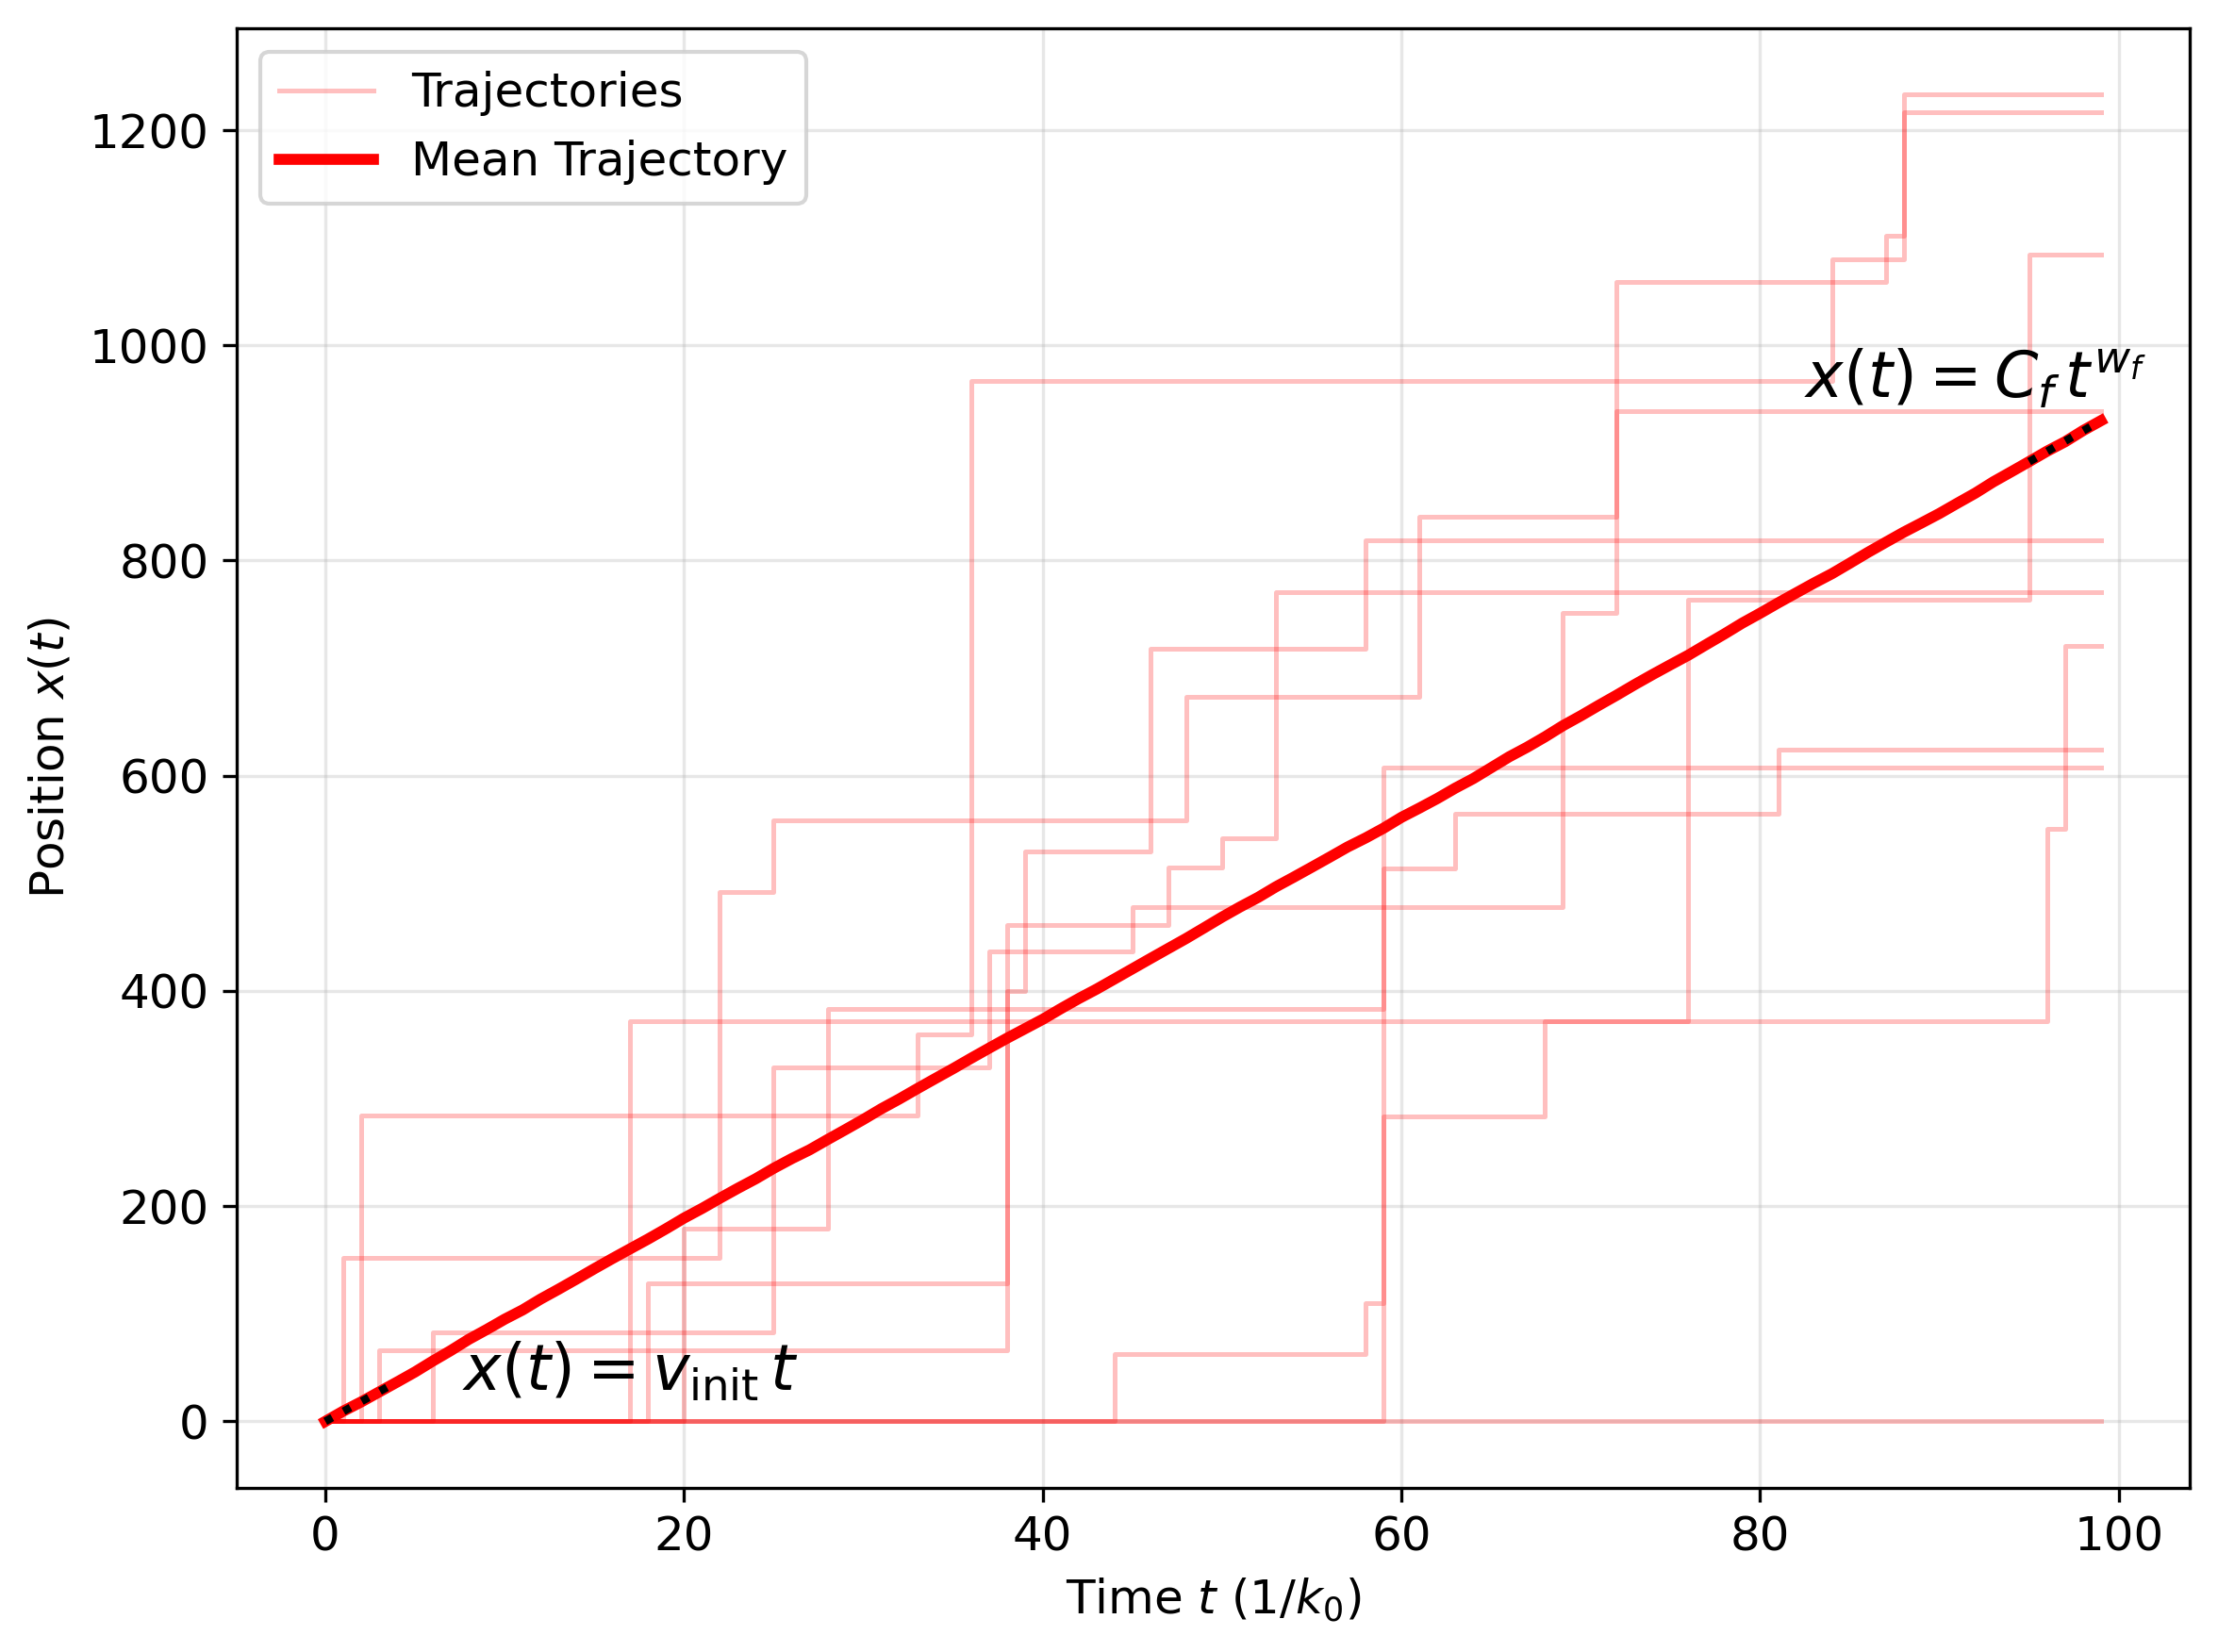

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 12

# Chargement
df = find_parquet_and_load(**params)

times = df["times"][0].to_numpy()
results = df["results"][0].to_numpy()
vf = df["vf"].to_numpy()
Cf = df["Cf"].to_numpy()
wf = df["wf"].to_numpy()


# Moyenne des trajectoires
mean_traj = np.mean(results, axis=0)

plt.figure(figsize=(8, 6), dpi=300)

# Fits début et fin
t_fit_init = times[0:5]
x_fit_init = vf * t_fit_init

t_fit_final = times[95:100]
x_fit_final = Cf * t_fit_final**wf

# Trajectoires individuelles
for i in range(10):
    plt.step(
        times,
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )

# Trajectoire moyenne
plt.plot(
    times,
    mean_traj,
    color="red",
    linewidth=2.8,
    label="Mean Trajectory",
)

# Fit initial (linéaire) 
plt.plot(
    t_fit_init, 
    x_fit_init, 
    color="black", 
    linestyle=":", 
    linewidth=2
)


# Fit final (puissance)
plt.plot(
    t_fit_final,
    x_fit_final,
    color="black",
    linestyle=":",
    linewidth=2
)

# Mise en forme
plt.xlabel(r"Time $t$ $(1/k_0)$")
plt.ylabel(r"Position $x(t)$")

# Annotations
plt.text(
    t_fit_init[len(t_fit_init)//2] + 15,
    x_fit_init[len(x_fit_init)//2] + 10,
    r"$x(t)=v_{\mathrm{init}}\,t$",
    fontsize=16,
    ha="center",
)

plt.text(
    t_fit_final[len(t_fit_final)//2] - 5,
    x_fit_final[len(x_fit_final)//2] + 40,
    r"$x(t)=C_f\,t^{w_f}$",
    fontsize=16,
    ha="center",
)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
# ax.set_title(r"$\mu = 160,\ \theta = 20$", fontsize=18)

plt.tight_layout()
plt.show()

/tmp/ipykernel_5549/2228377018.py:17: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim([0, 1e4])


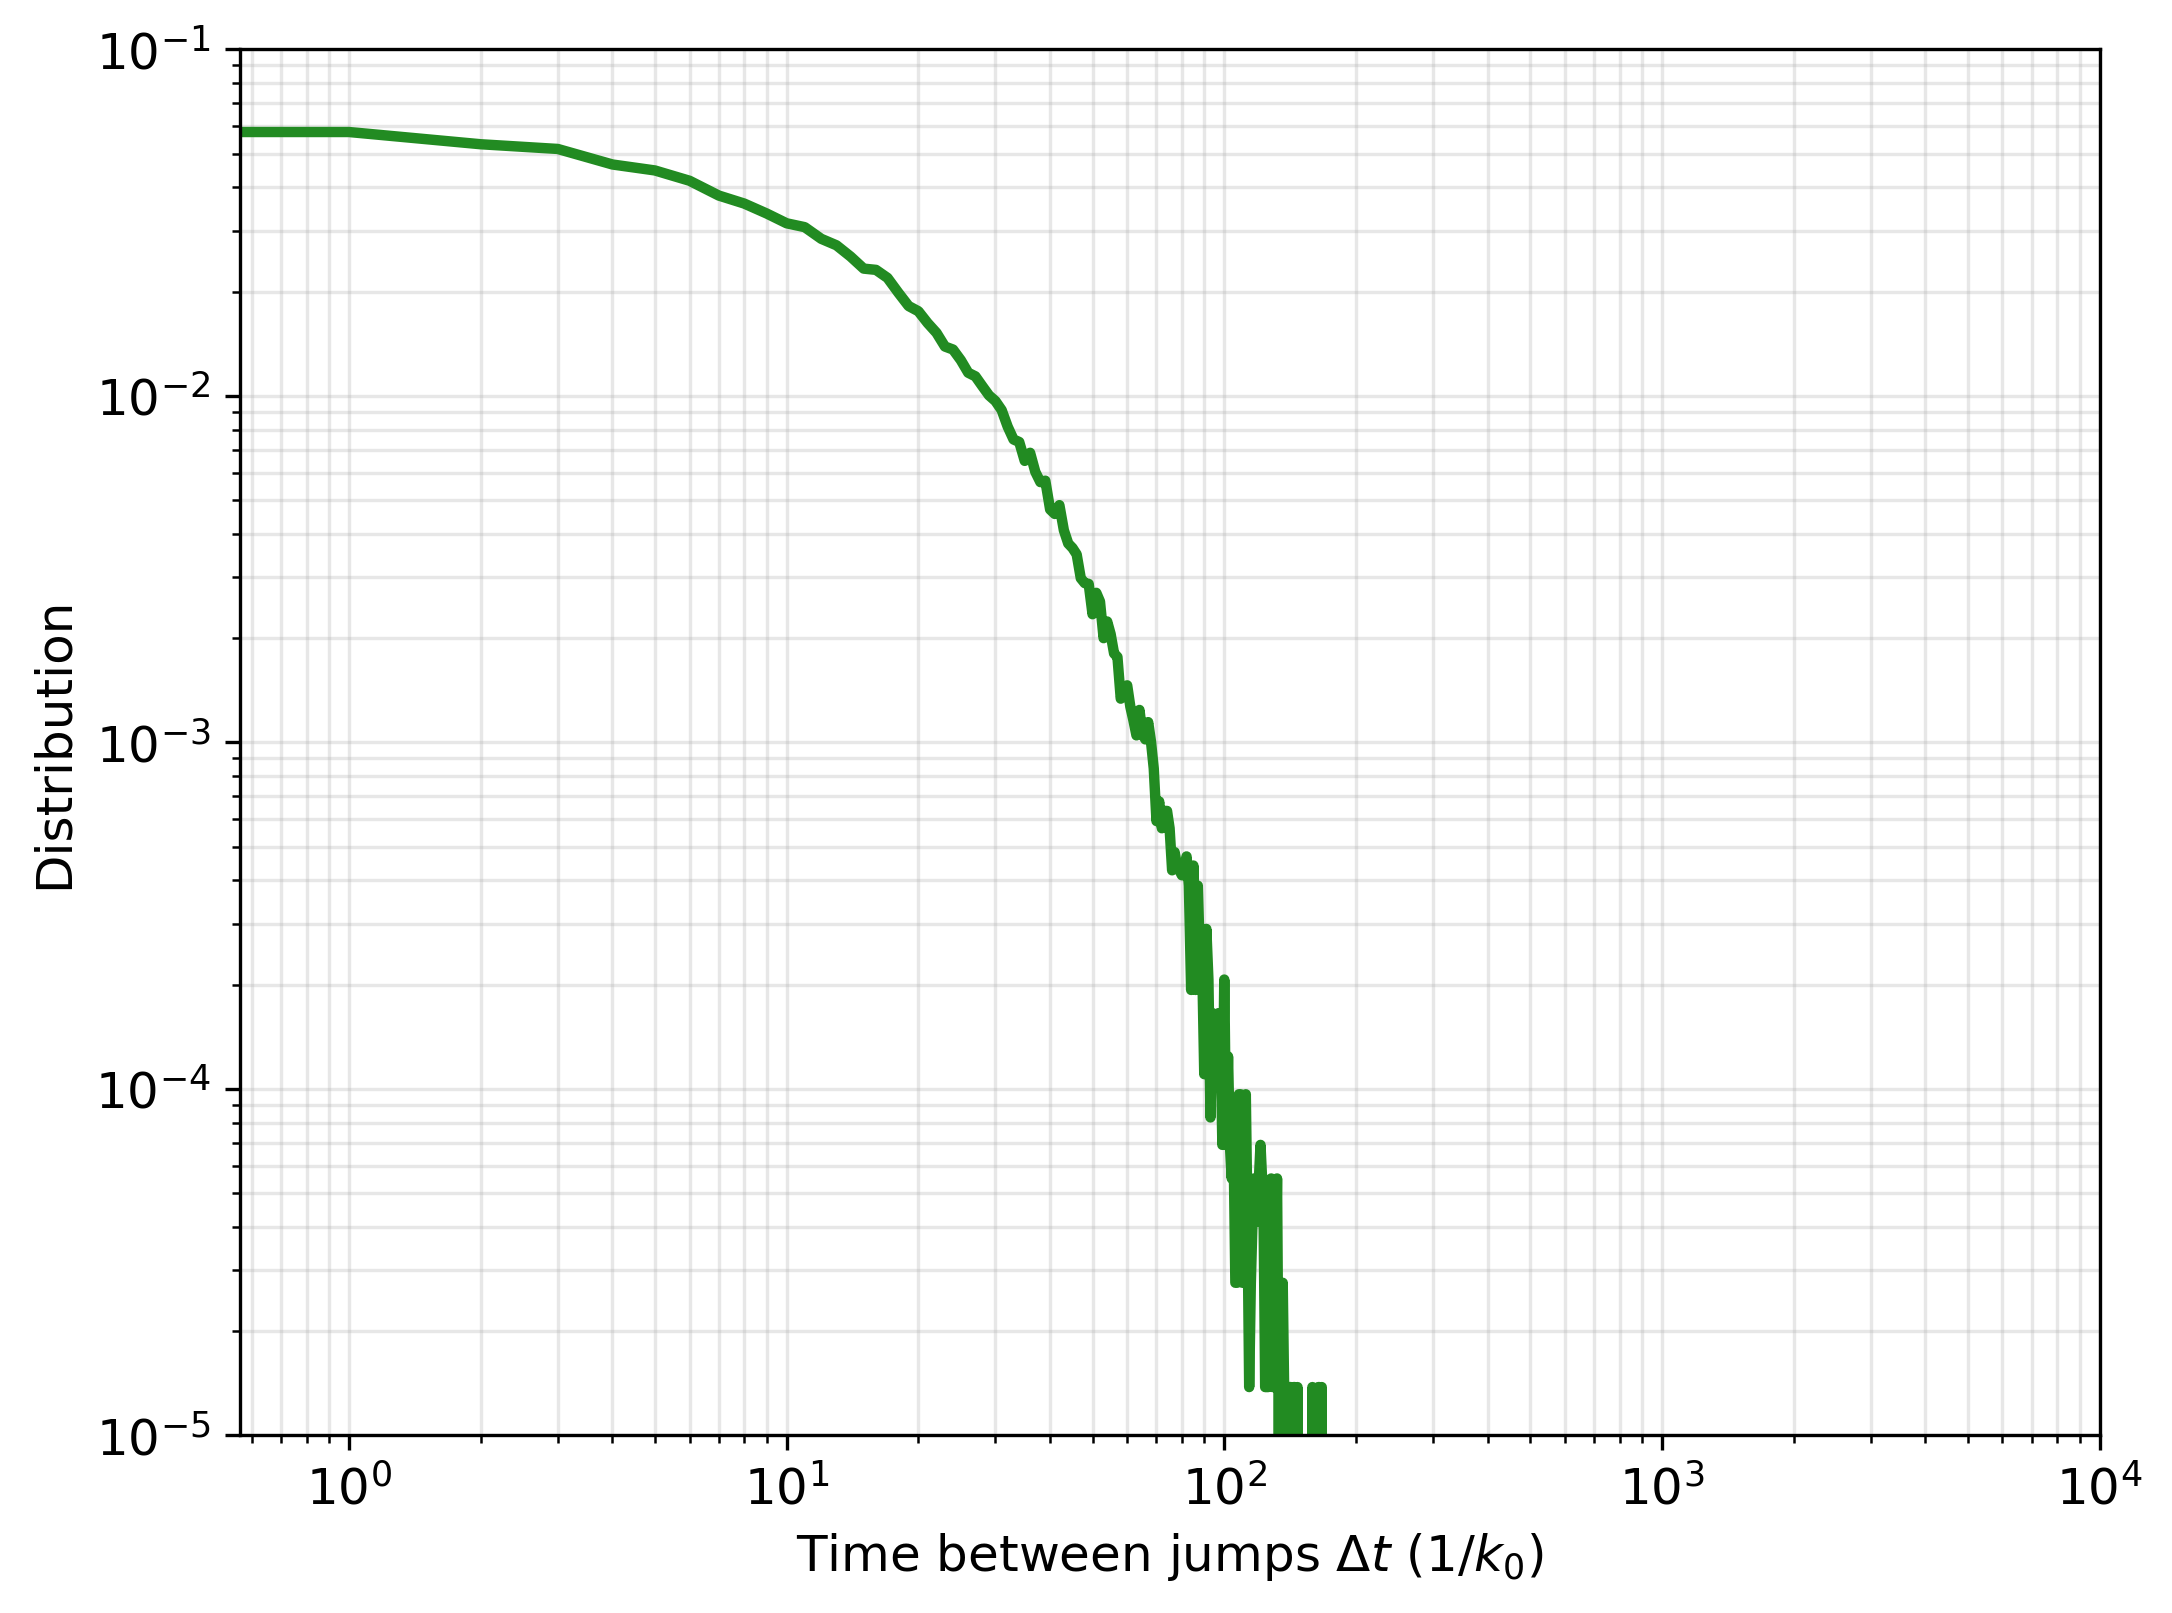

In [ ]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()

plt.figure(figsize=(8, 6), dpi=300)

# --- Time between jumps ---
plt.plot(
    tbj_points,
    tbj_distrib,
    color="forestgreen",
    linewidth=2.5,
)
plt.xscale("log")
plt.yscale("log")
plt.xlim([0, 1e4])
plt.ylim([1e-5, 1e-1])
plt.xlabel(r"Time between jumps $\Delta t$ (1/$k_0$)")
plt.ylabel("Distribution")
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.show()


In [3]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()
vi_med = df["vi_med"][0]

plt.figure(figsize=(8, 6), dpi=300)

# --- Velocity ---
plt.plot(
    vi_points,
    vi_distrib,
    color="indigo",
    linewidth=2.5,
    label="Data"
)

# plt.axvline(x=vi_med, color="black", linestyle=":", linewidth=1.5, label=r"$v = v_{\text{med}}$")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"Velocity $v$ ($\sigma k_0$)")
plt.ylabel("Distribution")
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.legend()
plt.show()

NameError: name 'df' is not defined

In [4]:
tbj_points = df["tbj_points"][0].to_numpy()
tbj_distrib = df["tbj_distrib"][0].to_numpy()
vi_points = df["vi_points"][0].to_numpy()
vi_distrib = df["vi_distrib"][0].to_numpy()
vi_med = df["vi_med"][0]

plt.figure(figsize=(8, 6), dpi=300)

# --- Velocity ---
plt.plot(
    vi_points,
    vi_distrib,
    color="indigo",
    linewidth=2.5,
    label="Data"
)

# plt.axvline(x=vi_med, color="black", linestyle=":", linewidth=1.5, label=r"$v = v_{\text{med}}$")
# plt.xscale("log")
# plt.yscale("log")
plt.xlabel(r"Velocity $v$ ($\sigma k_0$)")
plt.ylabel("Distribution")
plt.xlim(-1e1, 1e3)
plt.grid(True, alpha=0.3, which="both", linestyle="-")
plt.legend()
plt.show()

NameError: name 'df' is not defined

/tmp/ipykernel_9183/3753950786.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


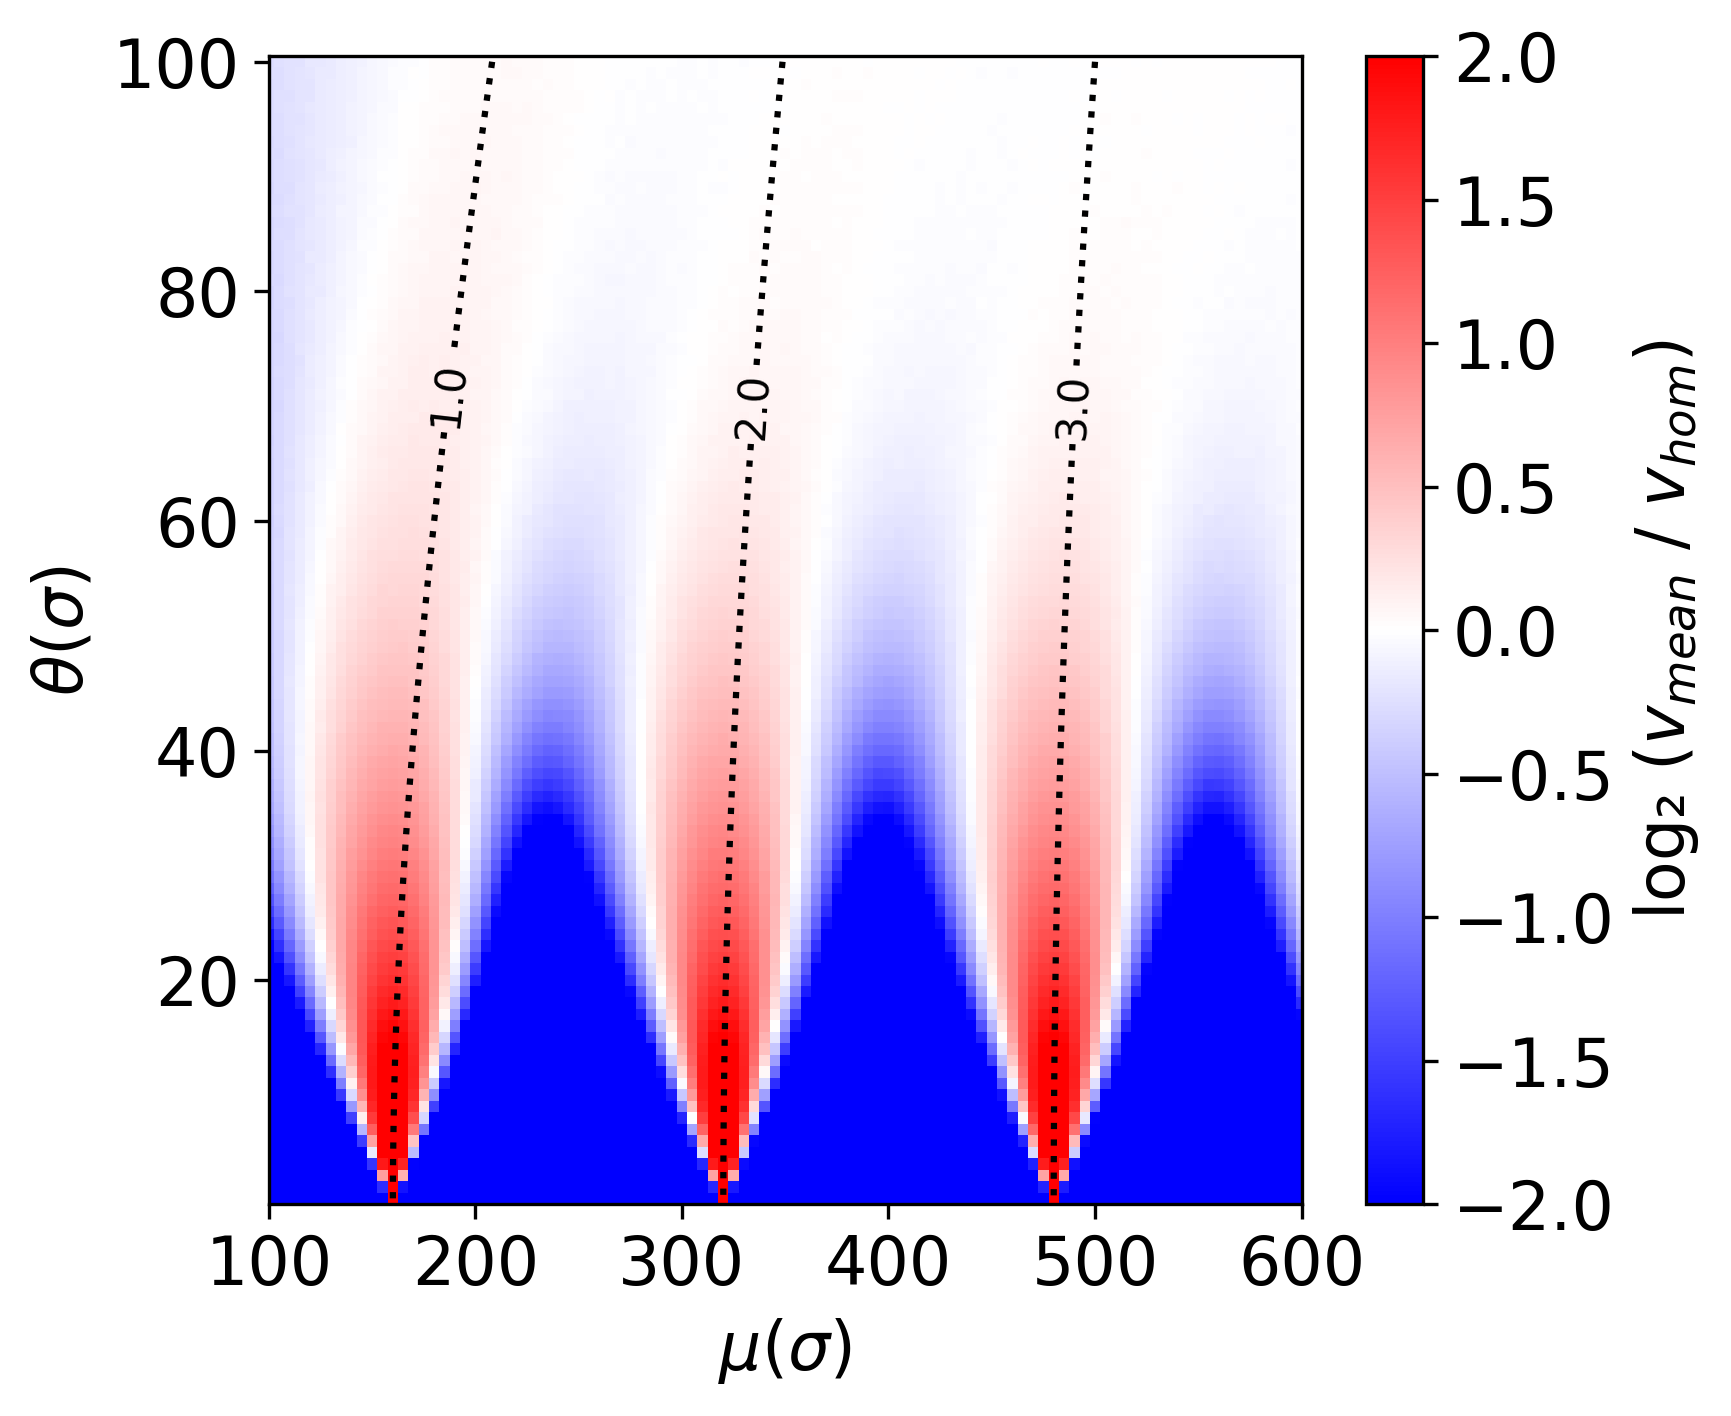

<Figure size 640x480 with 0 Axes>

In [9]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from nucleo.io.plots_2D import plot_one_heatmap_from_df

plt.rcParams["font.size"] = 16

# ── Data ───────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15")
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/MAIN_PARQUET")

heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")
# points = [(160, 20), (160, 60), (240, 20), (240, 60)]

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")
# color_positions = np.linspace(0.1, 0.9, len(points))
# color_list = [cmap(pos) for pos in color_positions]

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=1,        # équivalent du `key` de l'ancien dict (premier idx = 0) # MAX 19 (homogen)
    speed_col="v_mean",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=True,
    dashed_line=True,
    title=False,
)

# for i, (mu_pt, theta_pt) in enumerate(points):
#     ax.scatter(
#         mu_pt,
#         theta_pt,
#         color=color_list[i],
#         s=100,              # taille du point
#         edgecolor="black",  # contour du point
#         zorder=10           # pour être au-dessus de la heatmap
#     )

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

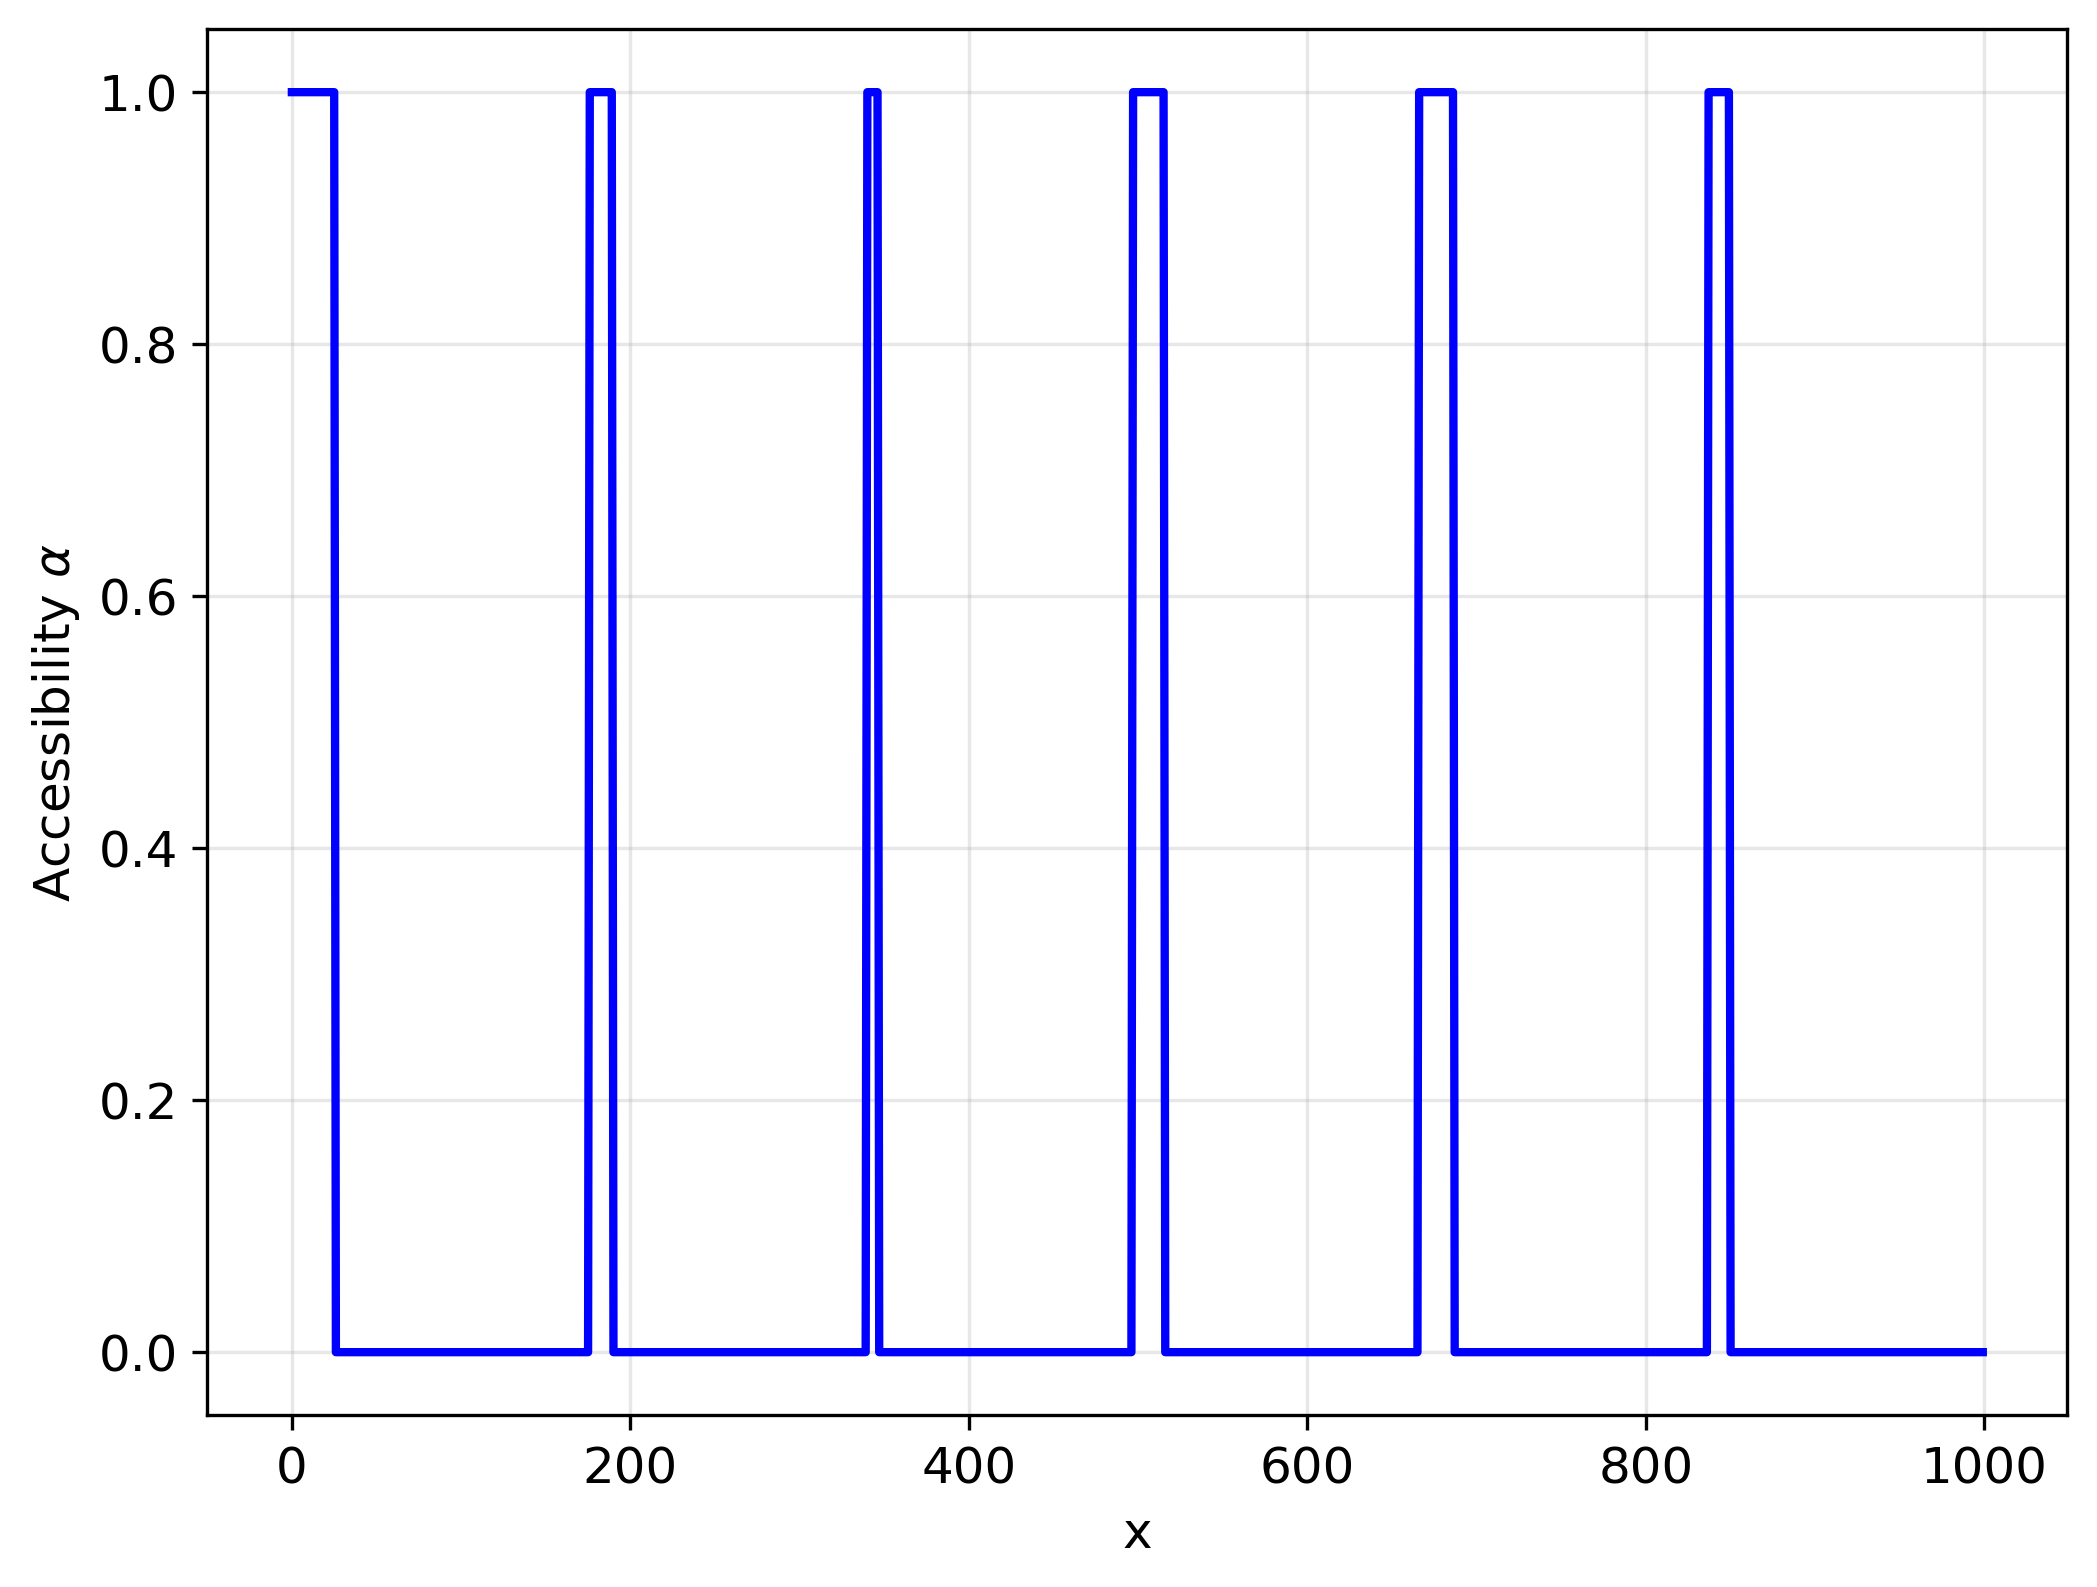

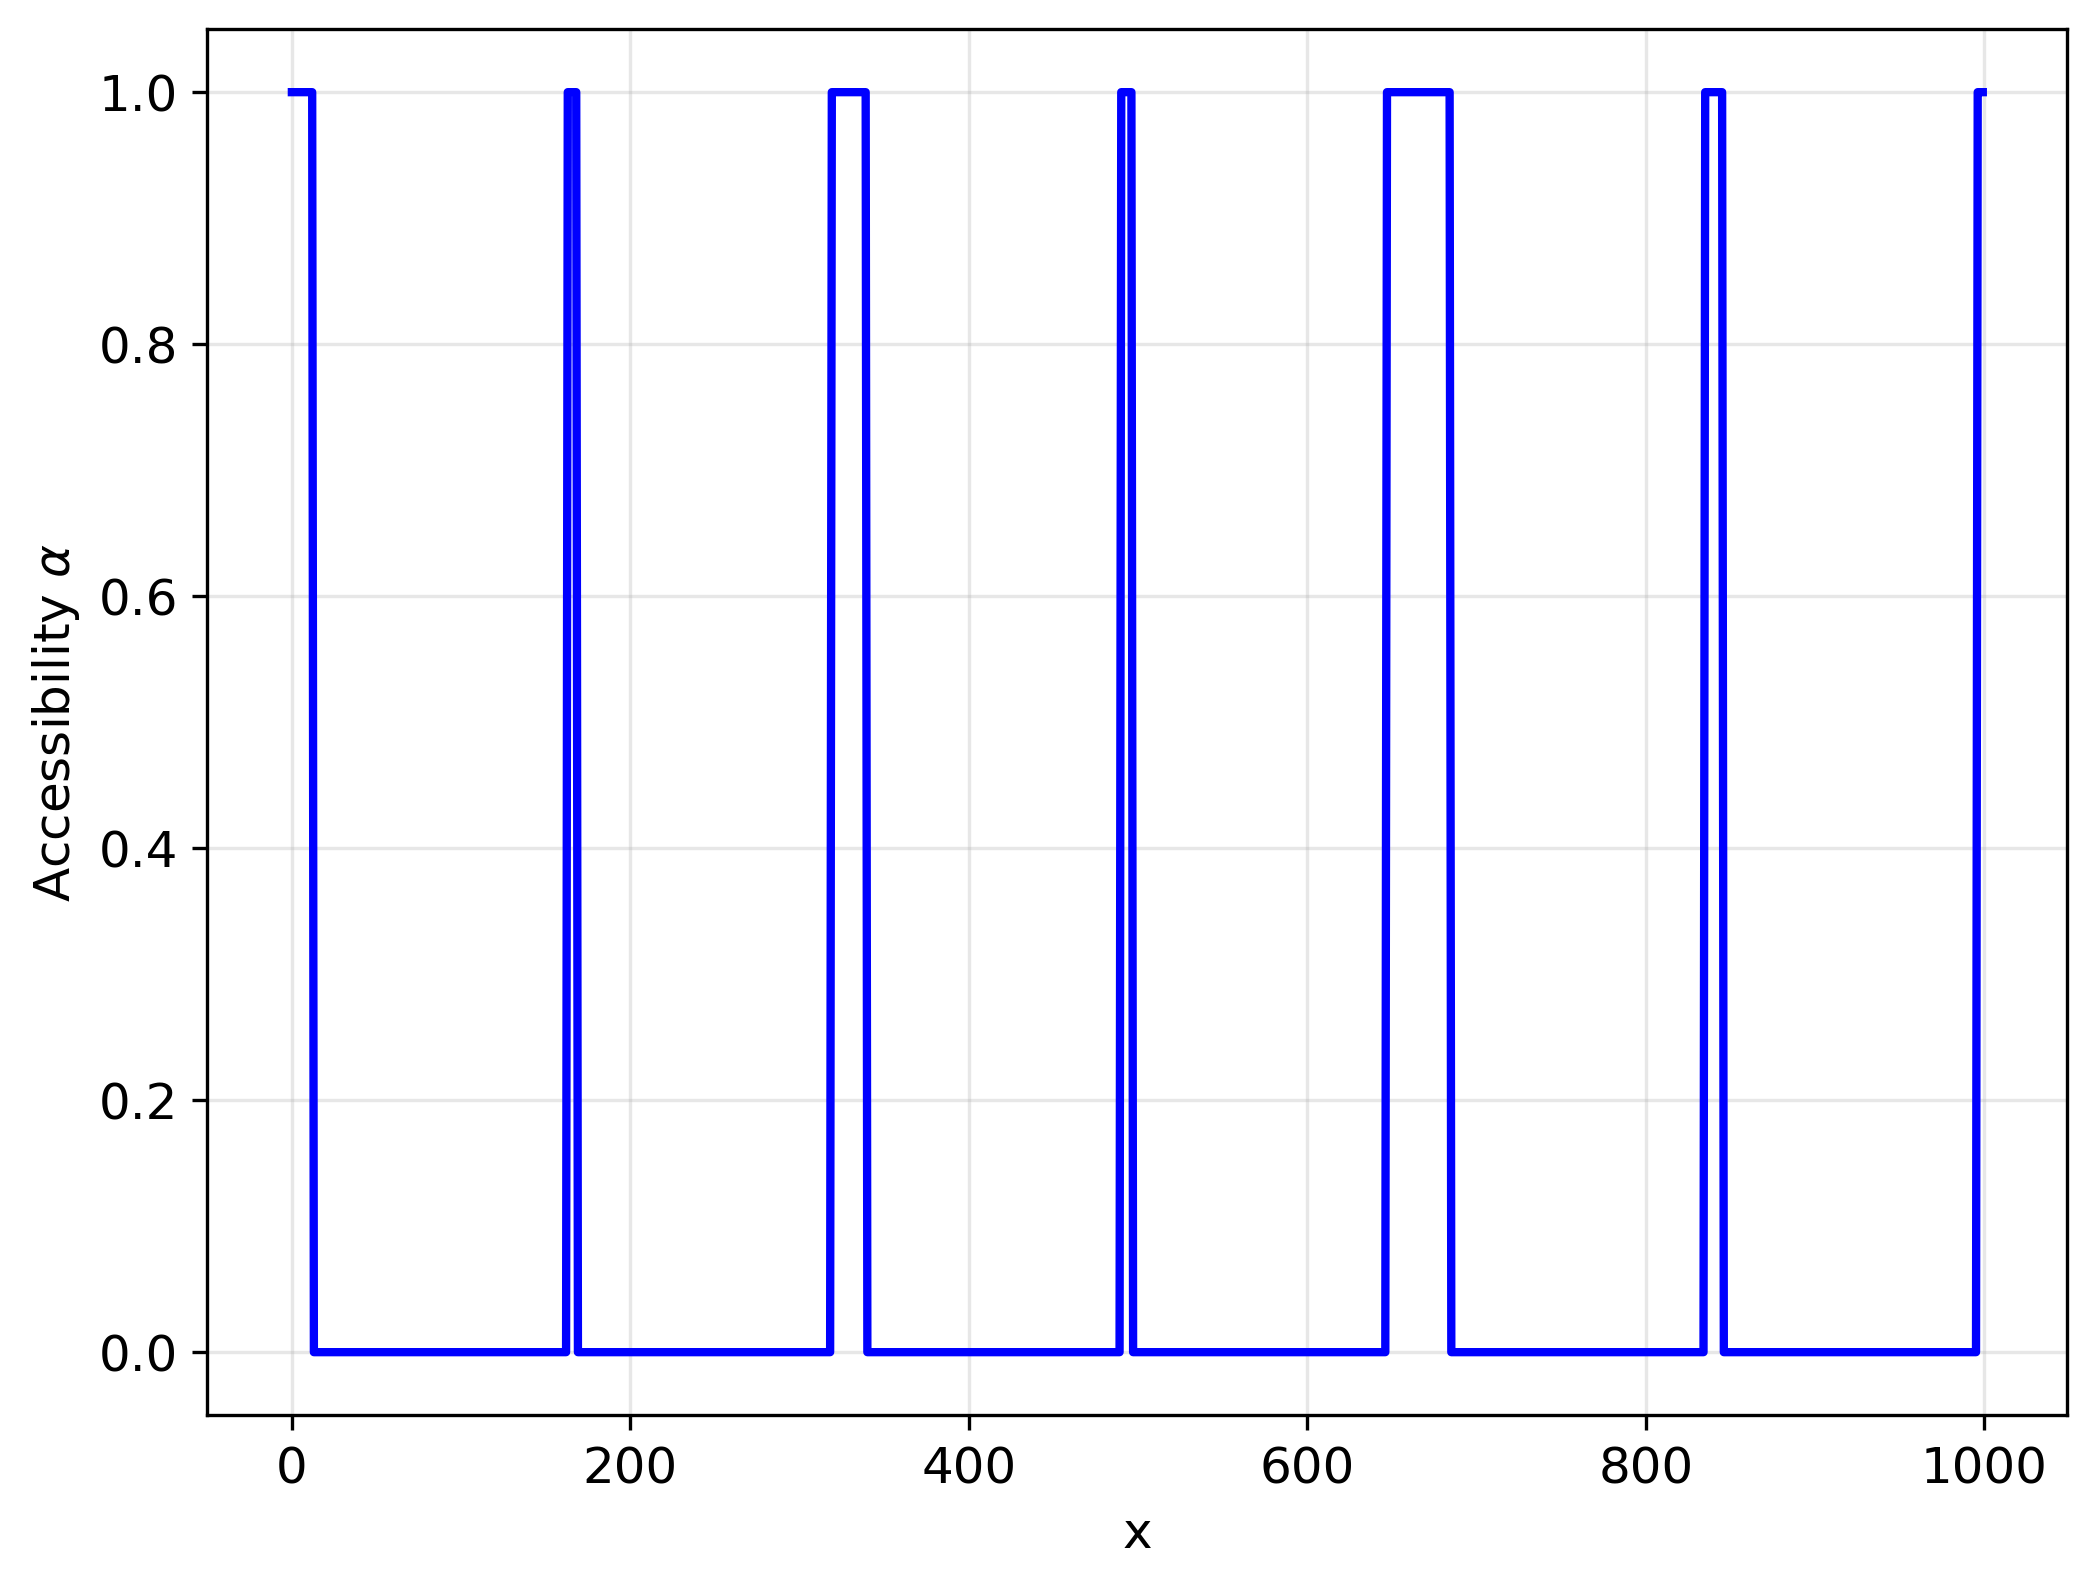

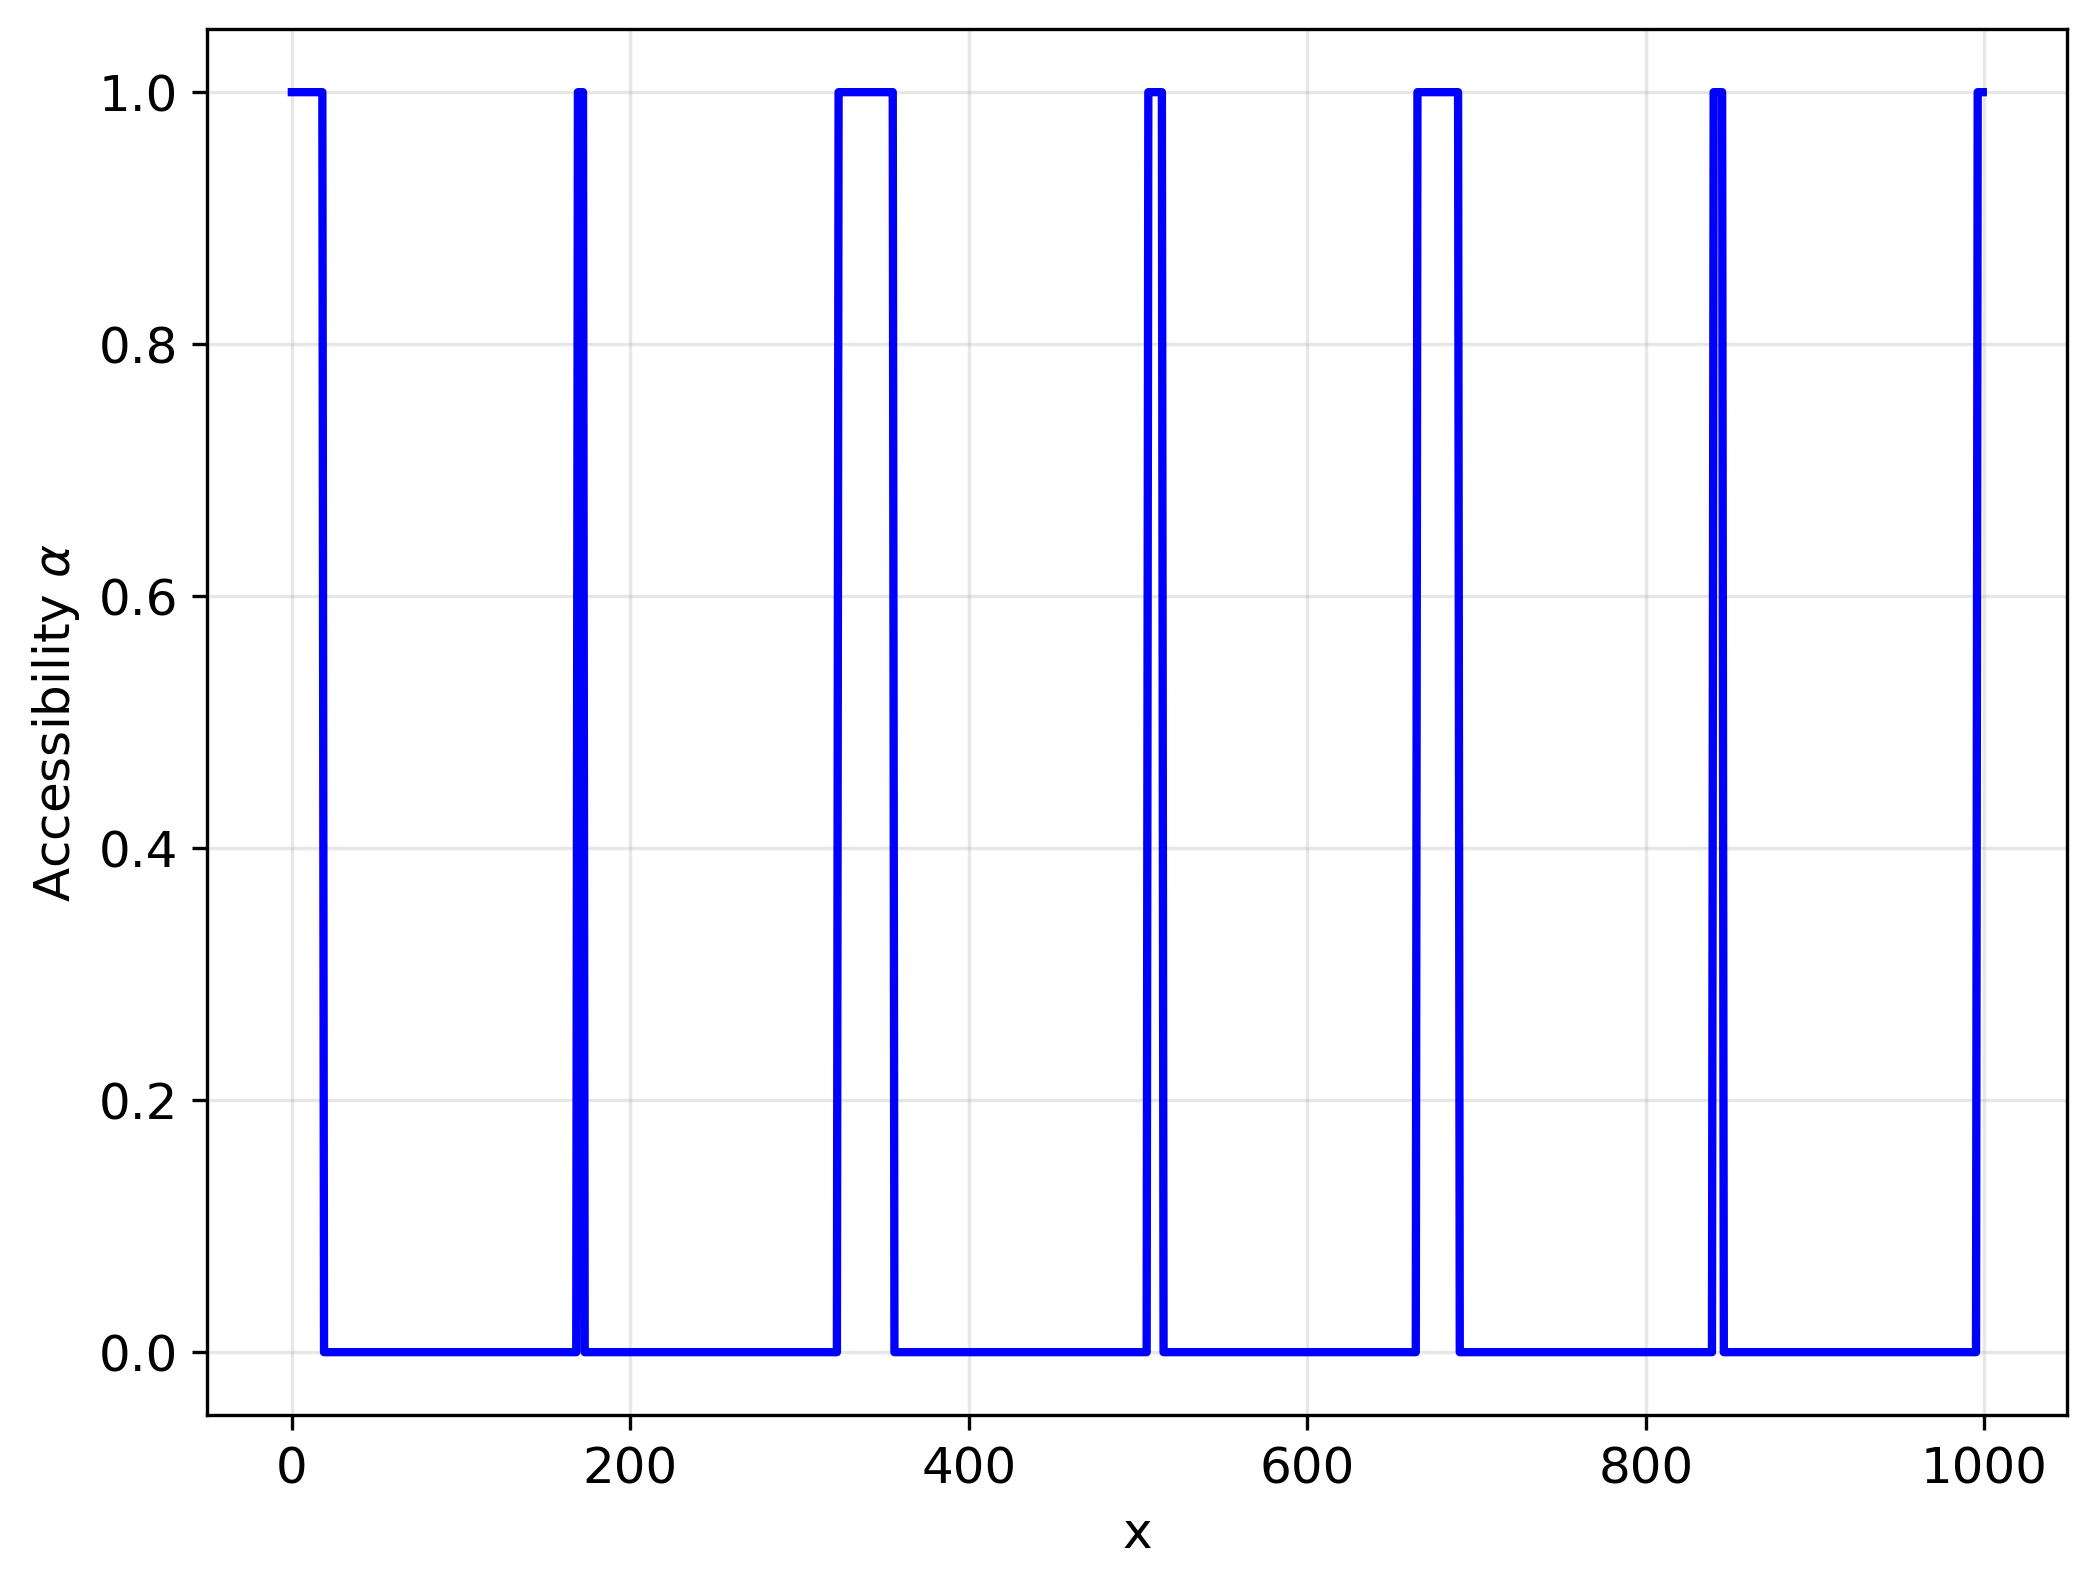

In [10]:
from nucleo.simulation.chromatin import alpha_random
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

for i in range (0,3):
    picture = alpha_random(params["s"], params["l"], 1, 0, 0, 1000, bps=1)
    plt.figure(figsize=(8, 6), dpi=300)
    plt.plot(picture, color="blue", linewidth=2.0)
    plt.xlabel("x")
    plt.ylabel(rf"Accessibility $\alpha$")
    plt.grid(True, alpha=0.30)
    plt.show()

In [11]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)

results = df["results"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
plt.figure(figsize=(8, 6), dpi=300)
for i in range(10):
    plt.step(
        df["times"][0].to_numpy(),
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )
plt.plot(results_mean, color="red", linewidth=2.0, label="Mean trajectory")
plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
plt.ylabel("Position x", fontsize=16)
plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 180,
    "theta": 20,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)
results = df["results"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
plt.figure(figsize=(8, 6), dpi=300)
for i in range(10):
    plt.step(
        df["times"][0].to_numpy(),
        results[i],
        where="post",
        color="red",
        alpha=0.25,
        linewidth=1.2,
        label="Trajectories" if i == 0 else None,
    )
plt.plot(results_mean, color="red", linewidth=2.0, label="Mean trajectory")
plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
plt.ylabel("Position x", fontsize=16)
plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

/tmp/ipykernel_9183/438064377.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma")


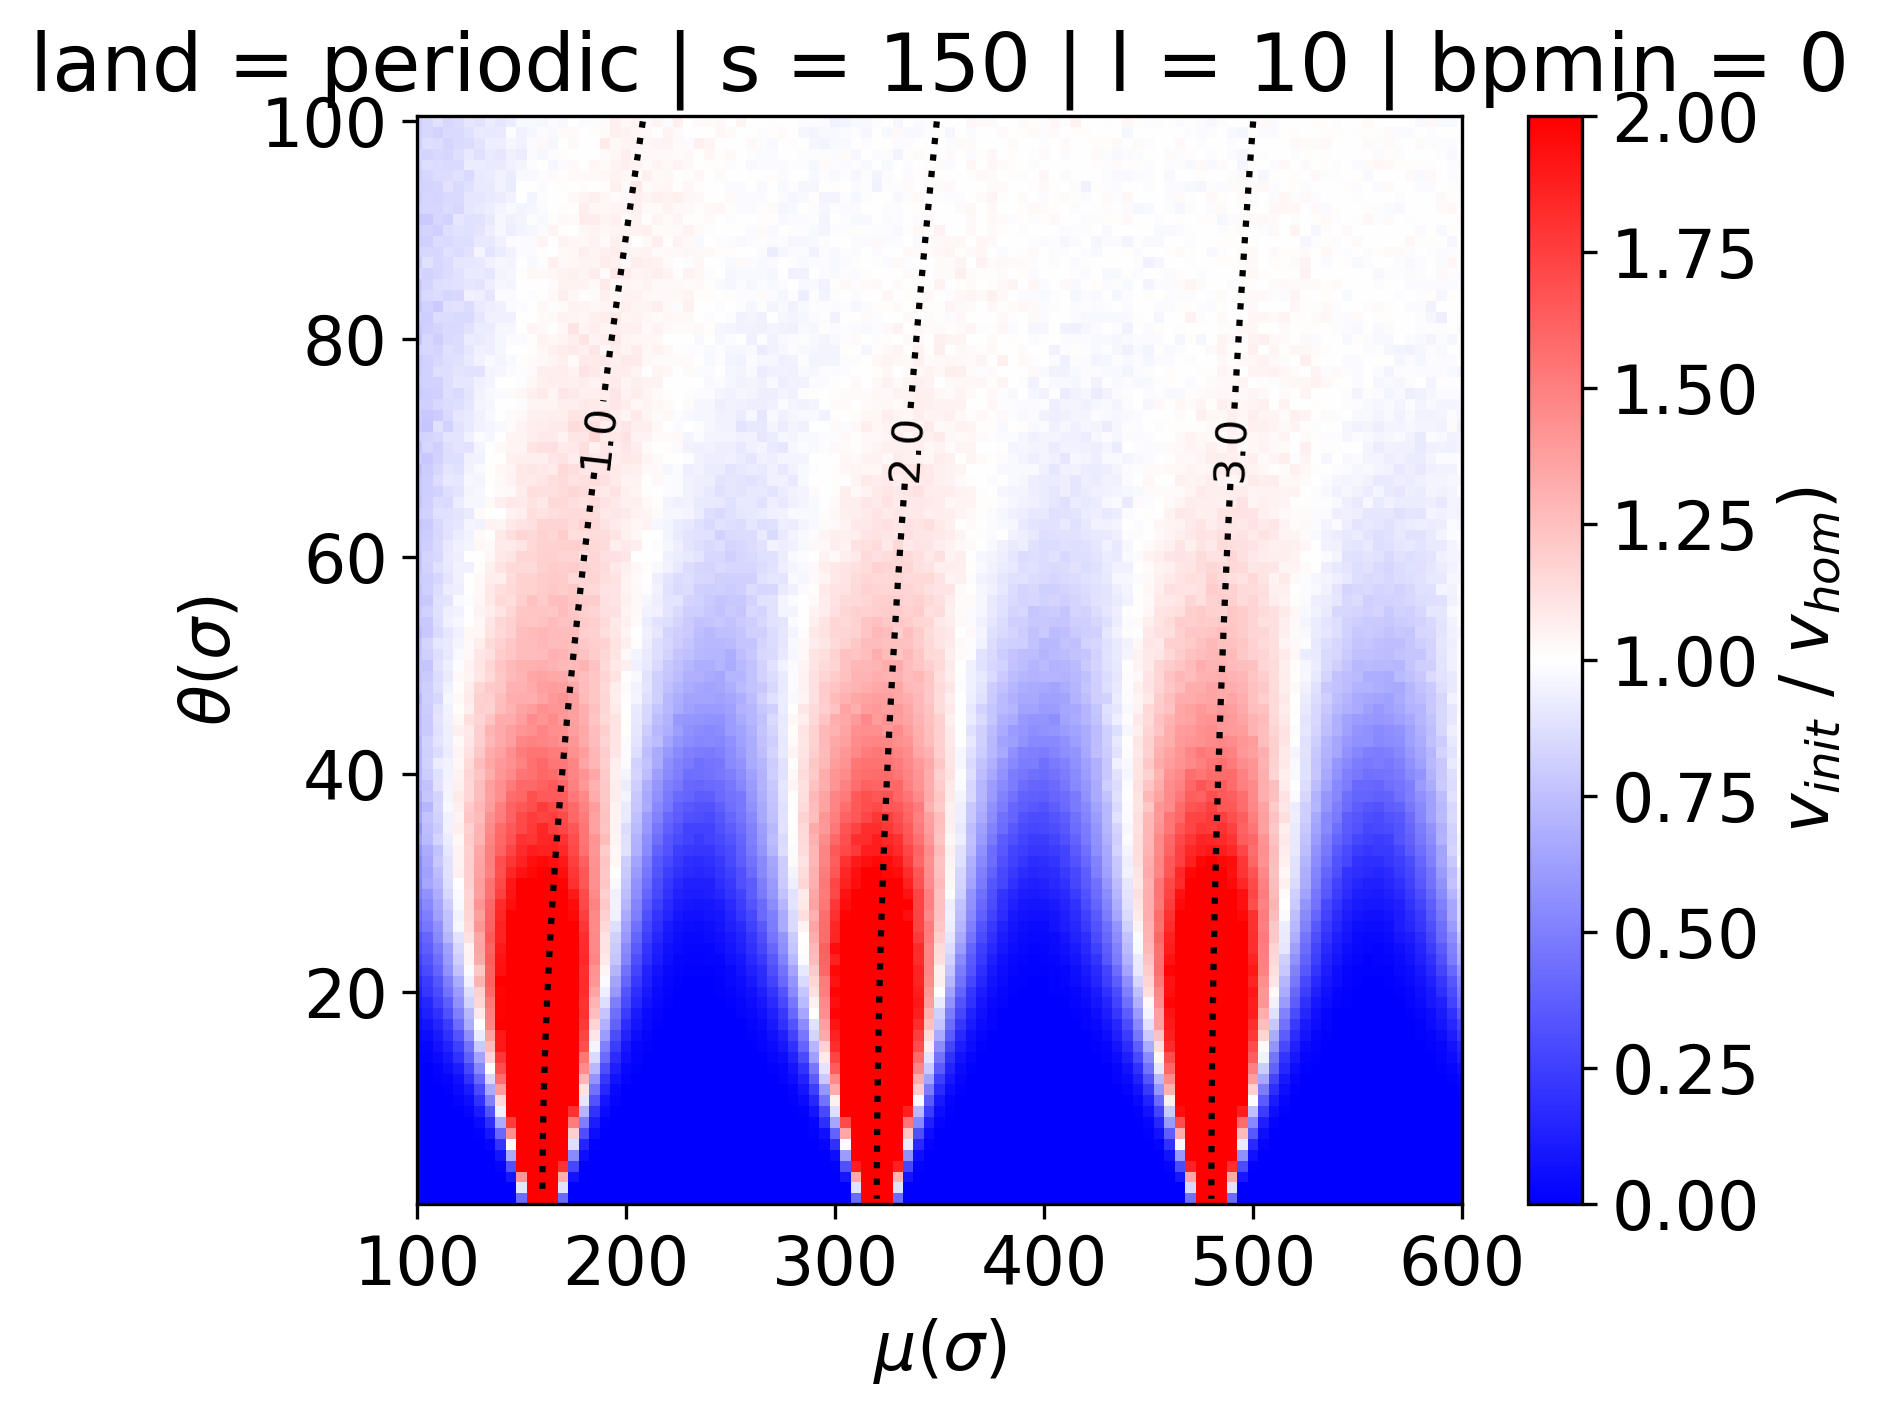

In [12]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nucleo.io.plots_2D import plot_one_heatmap_from_df
plt.rcParams["font.size"] = 16

# ── Data ───────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15"
)
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/MAIN_PARQUET"
)

heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plot_one_heatmap_from_df(
    heatmaps_df,
    config_idx=1,        # équivalent du `key` de l'ancien dict (premier idx = 0) # MAX 19 (homogen)
    speed_col="vf",
    ax=ax,
    type_of_data="norm_th",
    plot_log2=False,
    dashed_line=True,
    title=True,
)

plt.tight_layout()
plt.show()

In [13]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)

alpha_mean_a = df["alpha_mean_a"][0].to_numpy()

plt.figure(figsize=(14, 6), dpi=300)
plt.plot(
    alpha_mean_a,
    color="blue",
    alpha=1,
    linewidth=0.50,
    label="Mean accessibility"
)

plt.axvline(x=10000, color='red', linestyle='--', linewidth=1.5, label='First point of the simulation')

plt.xlabel(r"Position $x$")
plt.ylabel(r"$\alpha_{\text{mean}}$")
plt.tick_params(labelsize=14)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

In [9]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 12

params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 10,
    "nt": 10_000,
}

df = find_parquet_and_load(**params)
l_view = df["l_view"][0].to_numpy()
x = np.arange(len(l_view))

plt.figure(figsize=(14, 6), dpi=300)
plt.plot(
    x, l_view, lw=2.5, color="lightblue", alpha = 0.80
)
plt.xlabel(r"Position $x$")
plt.ylabel(r"$l_{\text{view}}$")
plt.grid(True, alpha=0.3)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

In [10]:
import numpy as np
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 12
plt.figure(figsize=(14, 6), dpi=300)

l_values = [10, 20, 50, 100, 150]
colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(l_values)))

for l_val, color in zip(l_values, colors):
    params = {
        "algo": "1S",
        "fact": "False",
        "mode": "none",
        "dstr": "False",
        "land": "random",
        "s": 150,
        "l": l_val,
        "bpmin": 0,
        "mu": 150,
        "theta": 10,
        "nt": 10_000,
    }

    df = find_parquet_and_load(**params)
    l_view = df["l_view"][0].to_numpy()
    l = df["l"][0]
    bpmin = df["bpmin"][0]
    x = np.arange(len(l_view))

    plt.plot(
        x, l_view, lw=2.5, color=color, alpha=0.85,
        label=rf"$l={l}$"
    )

plt.xlabel(r"Position $x$")
plt.ylabel(r"$l_{\text{view}}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

<Figure size 4200x1800 with 0 Axes>

In [11]:
import numpy as np
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 12
plt.figure(figsize=(14, 6), dpi=300)

bpmin_values = [0, 5, 10, 15]
colors = plt.cm.Blues(np.linspace(0.4, 1.0, len(bpmin_values)))

for bpmin_val, color in zip(bpmin_values, colors):
    params = {
        "algo": "1S",
        "fact": "False",
        "mode": "none",
        "dstr": "False",
        "land": "random",
        "s": 150,
        "l": 10,
        "bpmin": bpmin_val,
        "mu": 150,
        "theta": 10,
        "nt": 10_000,
    }

    df = find_parquet_and_load(**params)
    l_view = df["l_view"][0].to_numpy()
    l = df["l"][0]
    bpmin = df["bpmin"][0]
    x = np.arange(len(l_view))

    plt.plot(
        x, l_view, lw=2.5, color=color, alpha=0.85,
        label=rf"$l={l},\ bp_{{\min}}={bpmin}$"
    )

plt.xlabel(r"Position $x$")
plt.ylabel(r"$l_{\text{view}}$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

<Figure size 4200x1800 with 0 Axes>

In [12]:
35*4.3/(4.3-2)

65.43478260869566

In [13]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from nucleo.io.plots_2D import plot_one_heatmap_from_df
plt.rcParams["font.size"] = 12

# ── Data ───────────────────────────────
root = Path(
    "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15"
)
heatmaps_df = pl.read_parquet(root / "ncl_heatmaps.parquet")

# ── Couleurs (une couleur par point sélectionné) ─────────────────────────────
cmap = cm.get_cmap("plasma")

# ── Grille de plots pour les configs 1 à 9 ────────────────────────────────────
config_indices = list(range(16,19))  # 1 à 9 inclus
n_configs = len(config_indices)

nrows, ncols = 1, 3  # 9 cases pour 9 configs
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows), dpi=300)
axes = axes.flatten()

for ax, config_idx in zip(axes, config_indices):
    plot_one_heatmap_from_df(
        heatmaps_df,
        config_idx=config_idx,
        speed_col="vf",
        ax=ax,
        type_of_data="norm_th",
        plot_log2=True,
        dashed_line=True,
        title=True,
    )

# Cacher les axes en trop s'il y en a (pas le cas ici avec 9/9)
for ax in axes[n_configs:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

FileNotFoundError: No such file or directory (os error 2): ...nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/ncl_heatmaps.parquet (set POLARS_VERBOSE=1 to see full path)

In [14]:
import numpy as np

Nk = 1e8 / 300
print(f"Number of Kuhn lengths: {Nk:.2e}")

rg = np.sqrt(Nk * (100e-9)**2 / 6)
print(f"Radius of gyration: {rg:.2e} m")

Number of Kuhn lengths: 3.33e+05
Radius of gyration: 2.36e-05 m


In [15]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------------------------
# Paramètres
# -------------------------------------------------------------------

mus = [160, 240]
thetas = [20, 50, 100]

base_params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "periodic",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "nt": 10_000,
}

# -------------------------------------------------------------------
# Tracé des 6 combinaisons
# -------------------------------------------------------------------

for mu in mus:
    for theta in thetas:

        params = {
            **base_params,
            "mu": mu,
            "theta": theta,
        }

        df = find_parquet_and_load(**params)

        results = df["results"][0].to_numpy()
        results_mean = df["results_mean"][0].to_numpy()
        times = df["times"][0].to_numpy()
        v_mean_th = df["v_mean_th"][0]
        land = df["land"][0]
        print(land)

        # --- Figure ---
        plt.figure(figsize=(8, 6), dpi=300)

        # Trajectoires
        for i in range(10):
            plt.step(
                times,
                results[i],
                where="post",
                alpha=0.25,
                linewidth=1.2,
                label="Trajectories" if i == 0 else None,
                color="red"
            )

        # Trajectoire moyenne
        plt.plot(
            times,
            results_mean,
            linewidth=2.0,
            label="Mean Trajectory",
            color="red",
            linestyle="-"
        )

        # Théorie
        if land in ["homogen"]:
            plt.plot(
                times,
                times * v_mean_th,
                linewidth=2.0,
                label="Theory",
                color="black",
                ls=":"
            )



        plt.xlabel(r"Time $t$ $(1/k_0)$", fontsize=16)
        plt.ylabel(r"Position $x(t)$", fontsize=16)

        if land == "random":
            plt.ylim(-100, 2100)
        else :
            plt.ylim(-100, 4100)

        plt.tick_params(labelsize=14)
        plt.grid(True, alpha=0.3)
        

        # plt.title(
        #     rf"$\mu = {mu}$, $\theta = {theta}$",
        #     fontsize=16,
        # )
        print(rf"$\mu = {mu}$, $\theta = {theta}$")

        plt.legend(fontsize=12, loc="upper left")
        plt.tight_layout()
        plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

In [16]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

plt.rcParams["font.size"] = 12

# -------------------------------------------------------------------
# Paramètres
# -------------------------------------------------------------------
mus = [160, 240]
thetas = [20, 60]
cmap_C = cm.get_cmap("plasma")
color_positions_C = np.linspace(0.1, 0.4, len(mus))
color_list_C = [cmap_C(pos) for pos in color_positions_C]
color_list_C.reverse()

shift_factor_mu240 = 0.2 

base_params = {
    "algo": "1S",
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "random",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "nt": 10_000,
}

# -------------------------------------------------------------------
# Une figure par valeur de theta
# -------------------------------------------------------------------
for mu in mus:
    print(f"mu = {mu}")
    plt.figure(figsize=(8, 6), dpi=300)

    vi_points_for_slope = None  # servira à tracer la droite ∝v^-2 si mu == 240

    for i, theta in enumerate(thetas):
        params = {
            **base_params,
            "mu": mu,
            "theta": theta,
        }
        df = find_parquet_and_load(**params)
        vi_points = df["vi_points"][0].to_numpy()
        vi_distrib = df["vi_distrib"][0].to_numpy()
        land = df["land"][0]

        if vi_points_for_slope is None:
            vi_points_for_slope = vi_points  # on garde le premier theta rencontré

        plt.plot(
            vi_points,
            vi_distrib,
            linewidth=2,
            alpha=0.70,
            color=color_list_C[i],
            label=rf"$\theta = {theta}$",
        )

        # v_mean (ligne verticale, sans label)
        MU = df["mu"].to_numpy()[0]
        print(MU)
        l = df["l"].to_numpy()[0]
        s = df["s"].to_numpy()[0]
        alpha = l / (l + s)

    # ----------------------------------------------------------------
    # Droite ∝ v^-2
    # ----------------------------------------------------------------
    alpha_th = 1
    init_points = vi_points_for_slope[int(len(vi_points_for_slope) / 5000):]
    v_init = alpha_th * init_points ** (-2)

    if mu == 240:
        init_points = init_points * shift_factor_mu240 
        text_x_pos = 0.75
    else:
        text_x_pos = 0.98

    if land in ["homogen", "periodic"]:
        plt.axvline(
            x=alpha * MU / 2,
            color="black",
            ls=":",
            lw=2,
            alpha=1,
            label=r"$v_{\text{mean}}/2$"
        )

    plt.plot(
        init_points, v_init * 30,
        color="black", ls="dashdot", lw=2.5,
        label=r"$\propto v_{i}^{-2}$"
    )
    plt.gca().text(
        text_x_pos, 0.05, r"$\propto v^{-2}$",
        transform=plt.gca().transAxes, fontsize=14, color="black",
        ha="right", va="bottom", rotation=-52
    )

    # ----------------------------------------------------------------
    # Mise en forme
    # ----------------------------------------------------------------
    plt.xlabel(r"Velocity $v$ ($\sigma k_0$)")
    plt.ylabel("Distribution",)
    # plt.title(f"$\\mu = {mu}$")
    plt.xlim([5e-1, 1e3])
    plt.ylim([1e-4, 1e0])
    plt.tick_params()
    plt.grid(True, alpha=0.3, which="both", linestyle="-")
    plt.legend()
    plt.loglog()
    plt.tight_layout()
    plt.show()

mu = 160


/tmp/ipykernel_1887471/3931613700.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = cm.get_cmap("plasma")


FileNotFoundError: [Errno 2] No such file or directory: '/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15'

<Figure size 2400x1800 with 0 Axes>

/tmp/ipykernel_1887471/3301995687.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_C = cm.get_cmap("plasma")


mu=160, theta=20, v_mean=[31.30719398]
land=periodic
mu=160, theta=60, v_mean=[11.71059442]
land=periodic


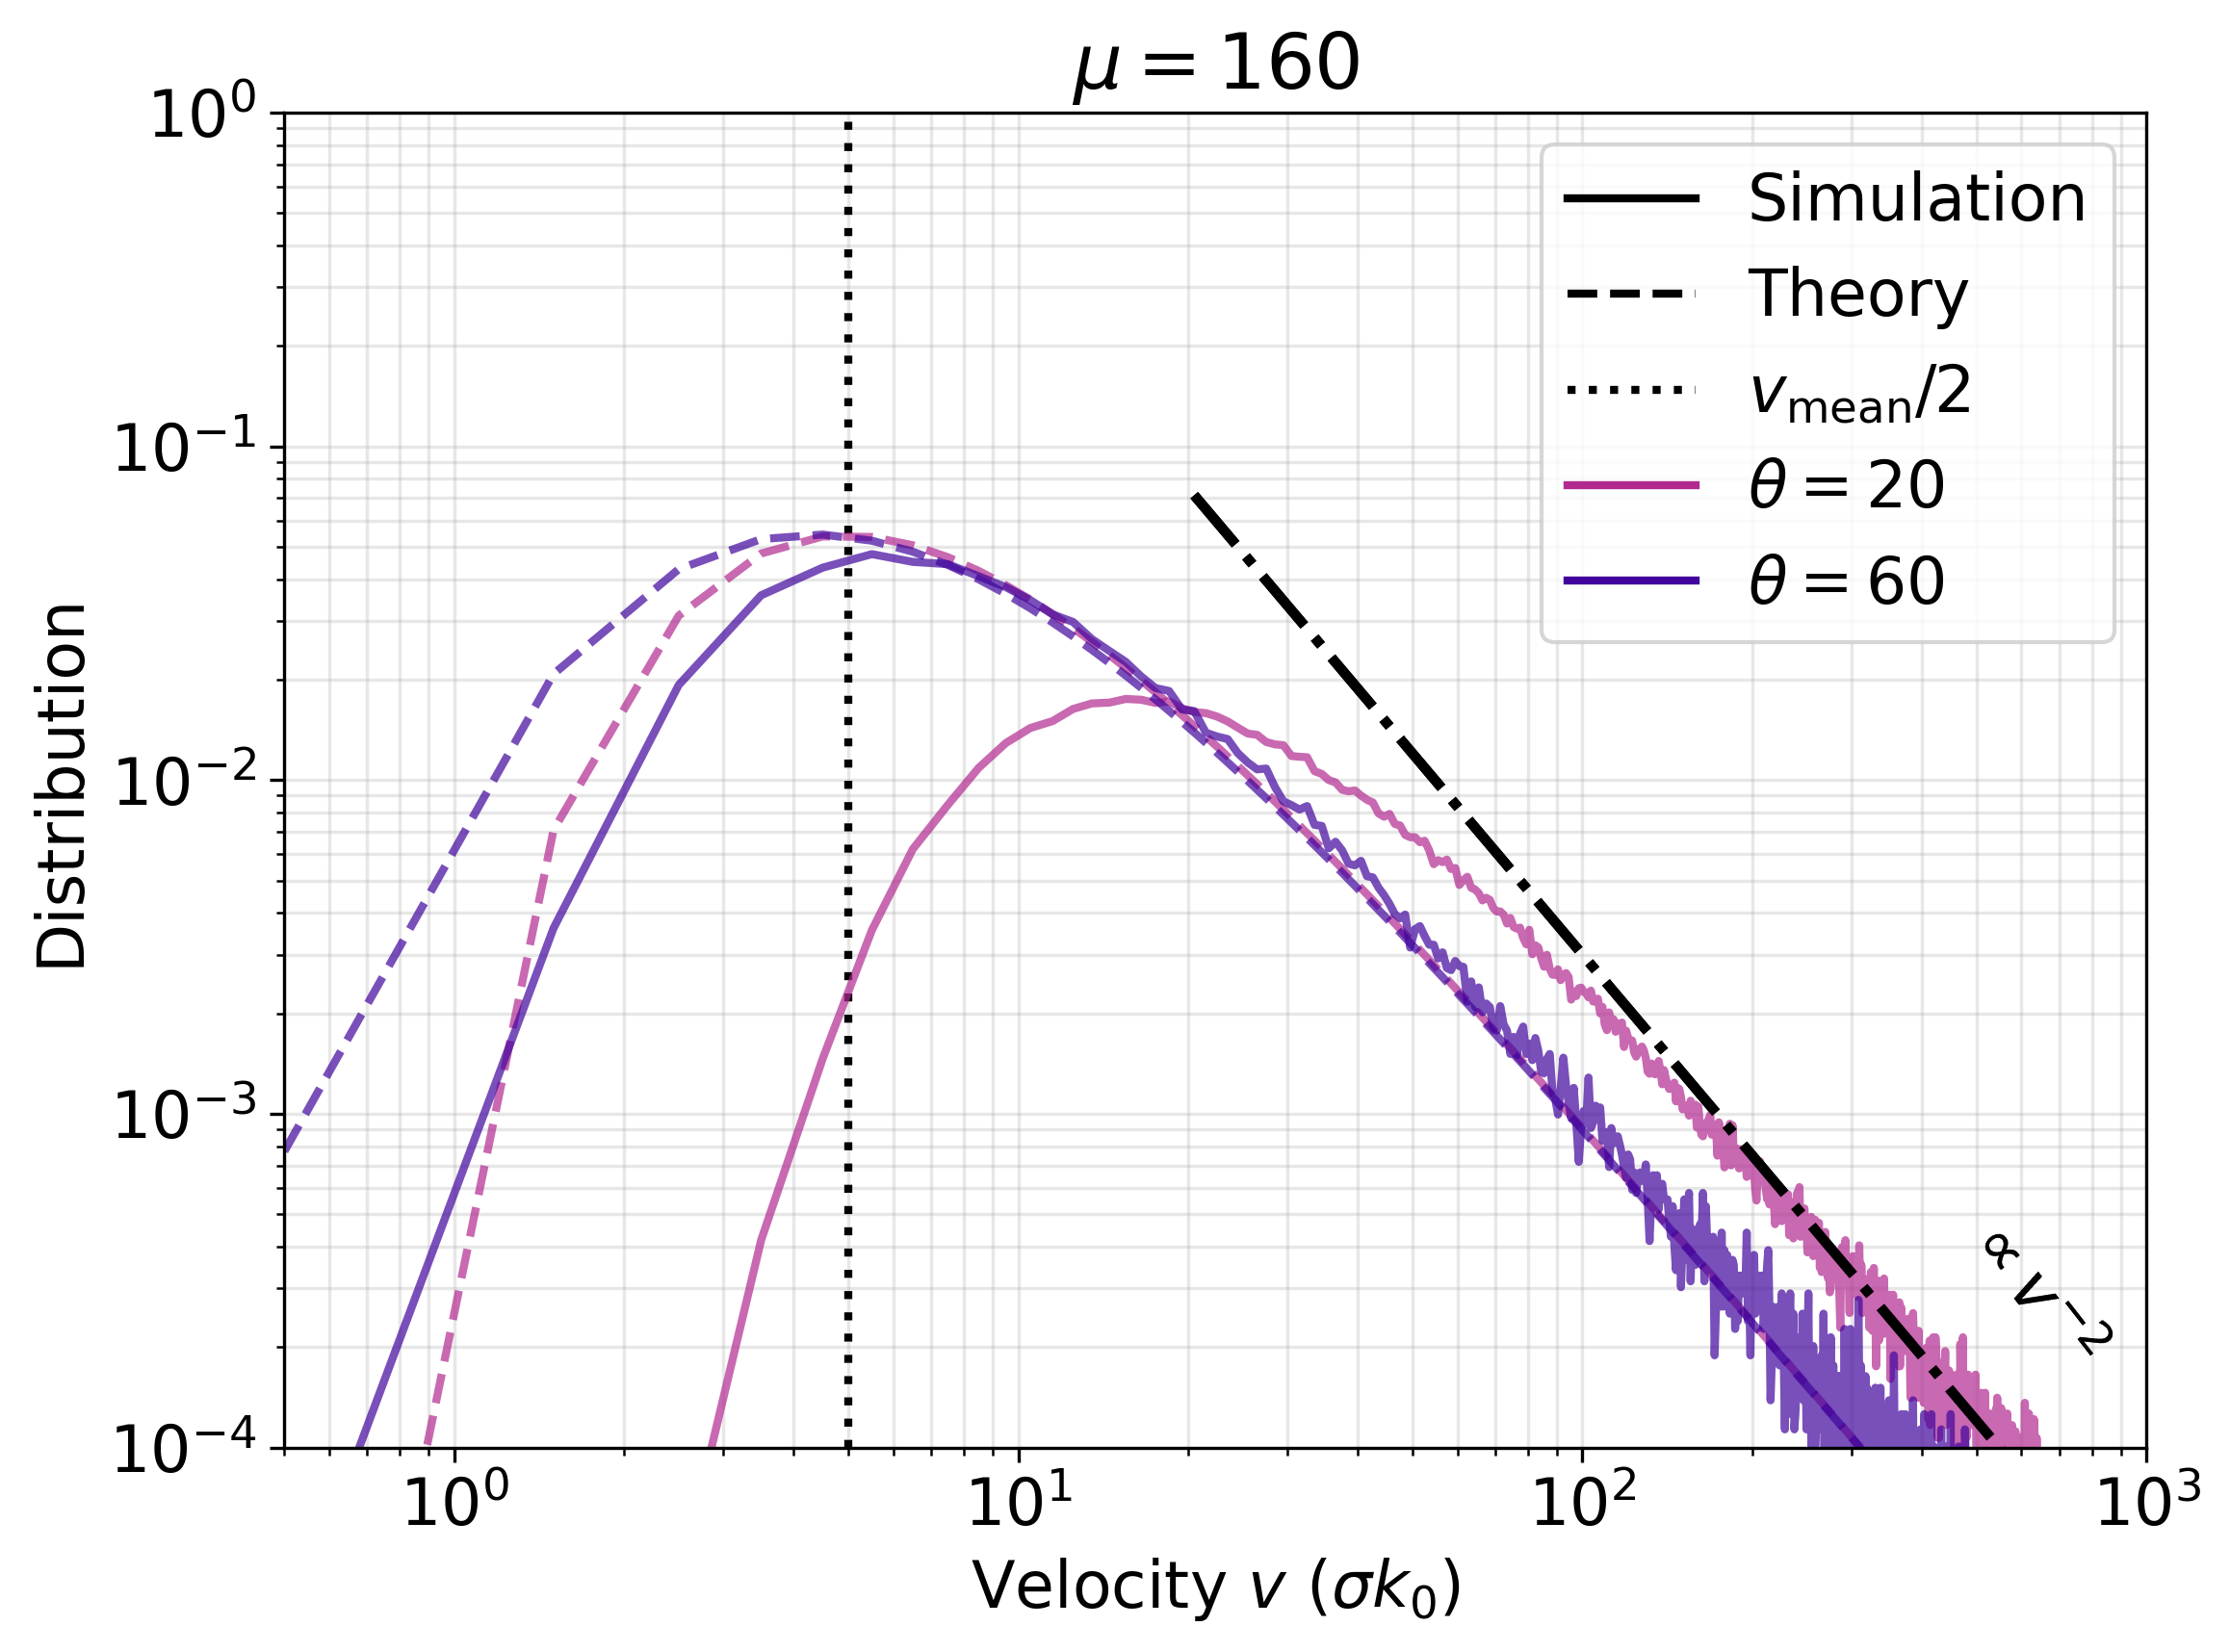

mu=240, theta=20, v_mean=[0.07724101]
land=periodic
mu=240, theta=60, v_mean=[12.81066978]
land=periodic


/tmp/ipykernel_1887471/3301995687.py:36: RuntimeWarning: overflow encountered in power
  return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)
/tmp/ipykernel_1887471/3301995687.py:36: RuntimeWarning: overflow encountered in multiply
  return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)
/tmp/ipykernel_1887471/3301995687.py:36: RuntimeWarning: invalid value encountered in divide
  return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)


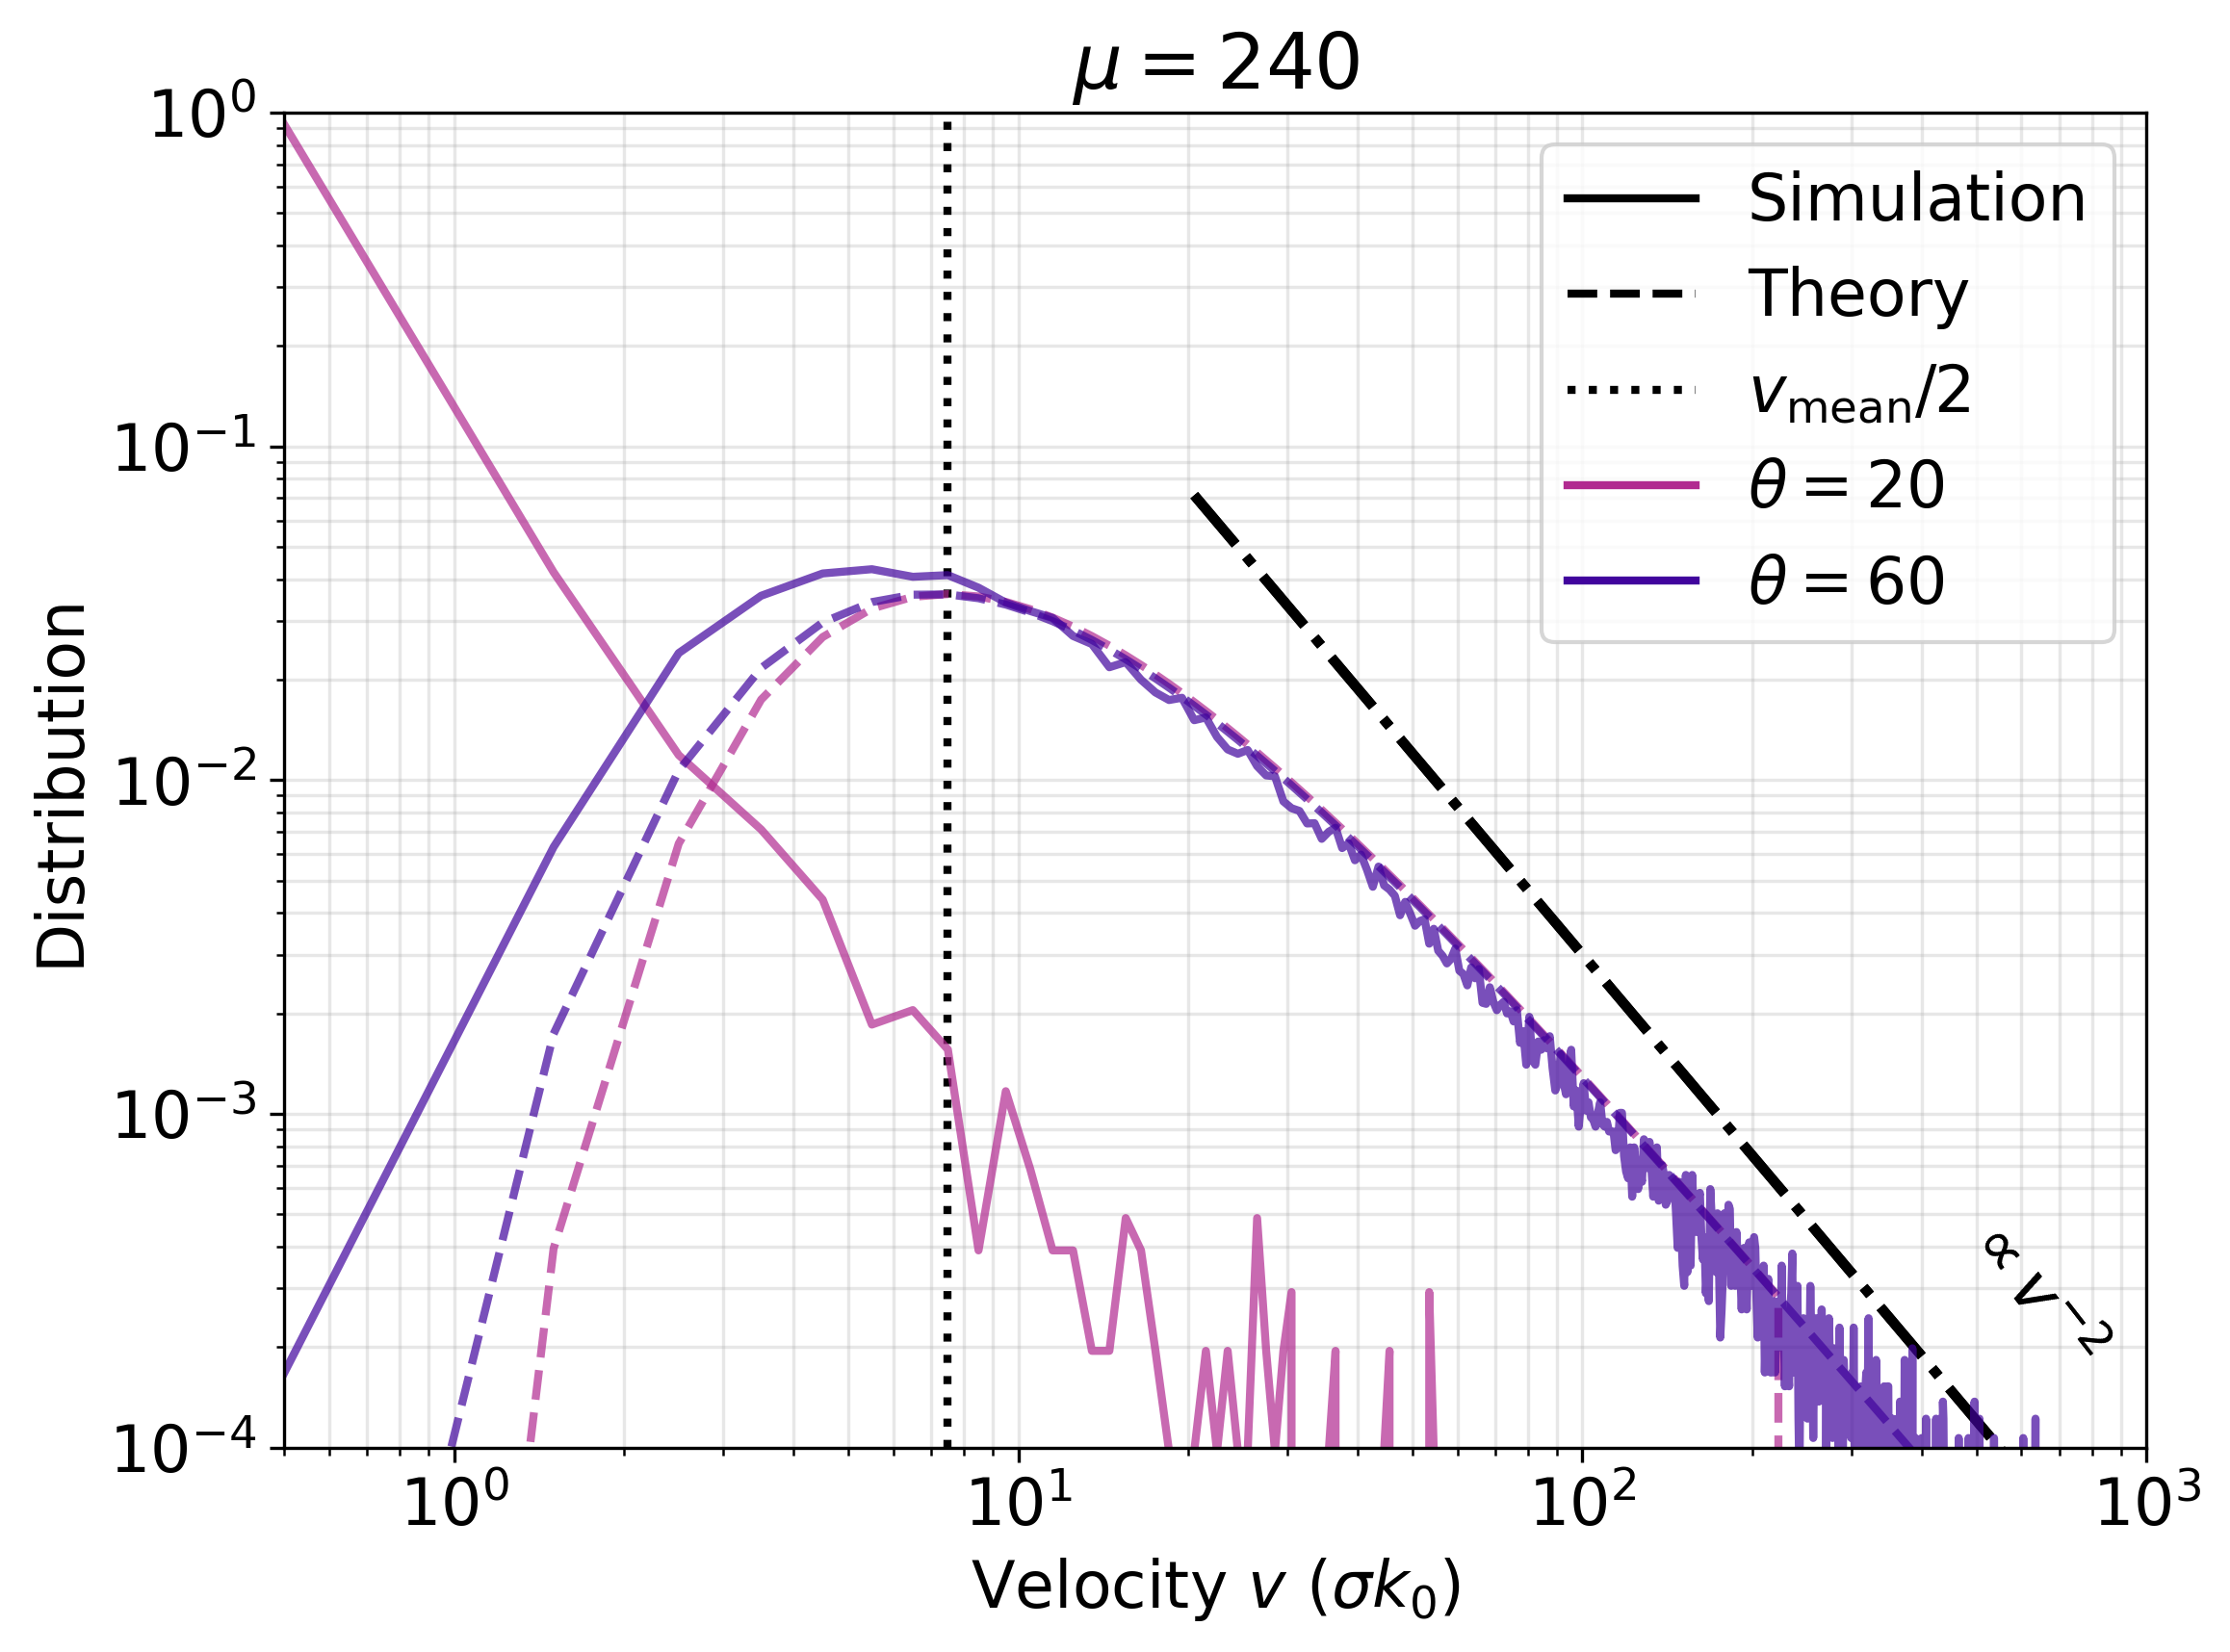

In [17]:
# ── Imports ──────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D

plt.rcParams["font.size"] = 16

# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURES__PC__2026-06-18/nucleo__fig2__0")
paths = sorted(str(p) for p in root.glob("*/**/*.parquet")) or sorted(str(p) for p in root.glob("*/*.parquet"))

land_val = "periodic"
mus = [160, 240]

df_all = (
    pl.scan_parquet(paths)
    .collect()
    .sort(by=[
        "algo", "fact", "mode",
        "land", "s", "l", "alphac", "alphar"
    ])
    .filter(pl.col("mu").is_in(mus))
    .filter(pl.col("land") == land_val)
)

# ── Theta values étudiés ─────────────────────────────────────────────────────
thetas = np.array([20, 60])

# ── Théorie : distribution instantanée des vitesses ─────────────────────────
def th_instantaneous_speeds(mu, theta, v, alpha0=10/160, k0=1):
    a = (mu / theta) ** 2
    b = mu / (theta ** 2)
    return (alpha0 * k0) * (a*b) * (v*b)**(a-1) / (alpha0*k0 + b*v)**(a+1)

# ── Couleurs (une couleur par theta) ─────────────────────────────────────────
cmap_C = cm.get_cmap("plasma")
color_positions_C = np.linspace(0.1, 0.4, len(thetas))
color_list_C = [cmap_C(pos) for pos in color_positions_C]
color_list_C.reverse()

# ── Figure ───────────────────────────────────────────────────────────────────
for mu_val in mus:

    df_mu = df_all.filter(pl.col("mu") == mu_val)

    plt.figure(figsize=(8, 6), dpi=300)

    # v_mean (ligne verticale, sans label)
    MU = df_mu["mu"].to_numpy()[0]
    l = df_mu["l"].to_numpy()[0]
    s = df_mu["s"].to_numpy()[0]
    alpha = l / (l + s)

    plt.axvline(
        x=alpha * MU / 2,
        color="black",
        ls=":",
        lw=2,
        alpha=1,
        label="_nolegend_"
    )

    for idx, theta_val in enumerate(thetas[0:3]):

        land = df_mu["land"][0]
        df_theta = df_mu.filter(pl.col("theta") == theta_val)
        mu = df_theta["mu"][0]
        vi_points = df_theta["vi_points"][0].to_numpy()
        vi_distrib = df_theta["vi_distrib"][0].to_numpy()
        v_mean = df_theta["v_mean"].to_numpy()

        print(f"mu={mu}, theta={theta_val}, v_mean={v_mean}")
        print(f"land={land}")

        # =========================
        #  Ligne théorie v_init ~ alpha * (sigma k0)^-2
        # =========================
        alpha_th = 1  # ajuste si nécessaire pour que la courbe tombe au bon niveau
        init_points = vi_points[int(len(vi_points)/5000):]
        v_init = alpha_th * init_points**(-2)

        plt.plot(
            init_points,
            v_init * 30,
            color="black",
            ls="dashdot",
            lw=2.5,
            label=r"$\propto v_{i}^{-2}$"
        )

        ax = plt.gca()
        ax.text(
            0.98, 0.05,                         # (x,y) en coordonnées d'axe
            r"$\propto v^{-2}$",
            transform=ax.transAxes,
            fontsize=16,
            color="black",
            ha="right",
            va="bottom",
            rotation=-52
        )

        # Simulation (avec label couleur)
        plt.plot(
            vi_points,
            vi_distrib,
            color=color_list_C[idx],
            ls="-",
            lw=2,
            alpha=0.70,
            label=f"(μ,θ)=({mu},{theta_val})"
        )

        # Théorie (sans label)
        plt.plot(
            vi_points,
            th_instantaneous_speeds(mu, theta_val, vi_points),
            color=color_list_C[idx],
            ls="--",
            lw=2,
            alpha=0.70,
            label="_nolegend_"
        )

    # ── Légendes ─────────────────────────────────────────────────────────────────
    ax = plt.gca()

    style_legend = [
        Line2D([0], [0], color="black", lw=2, ls="-", label="Simulation"),
        Line2D([0], [0], color="black", lw=2, ls="--", label="Theory"),
        Line2D([0], [0], color="black", lw=2, ls=":", label=r"$v_{\text{mean}}/2$")
    ]

    theta_labels = [r"$\theta={}$".format(t) for t in thetas]
    color_legend = [Line2D([0], [0], color=color_list_C[i], lw=2, label=theta_labels[i])
                    for i in range(len(thetas))]

    all_legend = style_legend + color_legend
    ax.legend(handles=all_legend, loc="upper right", frameon=True)  # pas de ncol = vertical

    plt.xlabel(r'Velocity $v$ ($\sigma k_0$)')
    plt.ylabel("Distribution")
    plt.xlim([5e-1, 1e3])
    plt.ylim([1e-4, 1e0])
    plt.xscale("log")
    plt.yscale("log")
    plt.grid(True, alpha=0.3, which="both")
    plt.title(fr"$\mu={MU}$")
    plt.tight_layout()
    plt.show()

v_mean


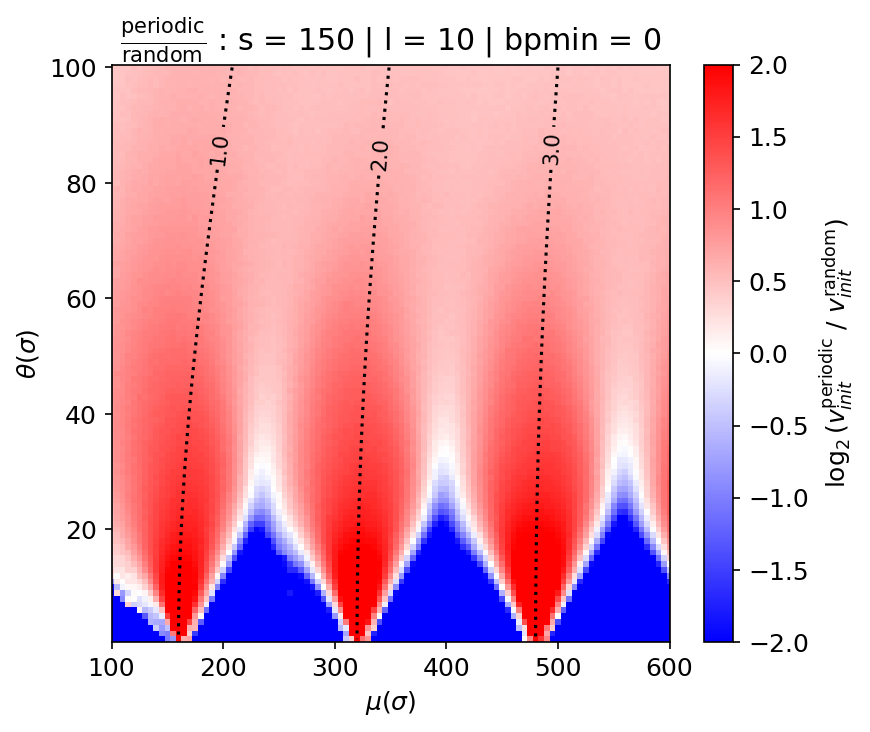

In [ ]:
from pathlib import Path
import polars as pl
import numpy as np

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/NUCLEO__PSMN__2026-08-15/"
root = "/home/nicolas/Documents/Workspace/nucleo/outputs/MAIN_PARQUET/"
df_scenarios = pl.read_json(root + "scenarios.json")

ls = np.unique(df_scenarios["l"].to_numpy())

import matplotlib.pyplot as plt
from nucleo.io.plots_2D import find_config_idx, plot_one_heatmap_ratio_from_df


df = pl.read_parquet(root + "ncl_heatmaps.parquet")
s = 150
l = 10
bpmin = 0

idx_num = find_config_idx(df, s=s, l=l, bpmin=bpmin, land="periodic")
idx_den = find_config_idx(df, s=s, l=l, bpmin=bpmin, land="random")

ax, c = plot_one_heatmap_ratio_from_df(
    df,
    config_idx_num=idx_num,
    config_idx_den=idx_den,
    speed_col="vf",
    plot_log2=True,
    dashed_line=True,
    title=False
)

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/MAIN_PARQUET/ncl_output.parquet"
df_work = pl.read_parquet(root)
print(df_work)


mus     = np.array([160, 240])
thetas  = np.array([20, 60])







shape: (308_000, 61)
┌──────┬───────┬──────┬───────┬───┬───────┬───────────┬───────────┬───────┐
│ algo ┆ fact  ┆ mode ┆ dstr  ┆ … ┆ dx_mp ┆ dt_mean   ┆ dt_med    ┆ dt_mp │
│ ---  ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---   ┆ ---       ┆ ---       ┆ ---   │
│ str  ┆ bool  ┆ str  ┆ bool  ┆   ┆ f64   ┆ f64       ┆ f64       ┆ f64   │
╞══════╪═══════╪══════╪═══════╪═══╪═══════╪═══════════╪═══════════╪═══════╡
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 1.5   ┆ 24.847608 ┆ 3.138241  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 1.5   ┆ inf       ┆ 4.691028  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 1.5   ┆ inf       ┆ 4.135669  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 1.5   ┆ inf       ┆ 3.771945  ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 1.5   ┆ inf       ┆ 3.56355   ┆ 0.5   │
│ …    ┆ …     ┆ …    ┆ …     ┆ … ┆ …     ┆ …         ┆ …         ┆ …     │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 440.5 ┆ 15.912684 ┆ 11.101916 ┆ 0.5   │
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ 439.5 ┆ 16.03172  ┆ 11.09795  ┆

# PART 3

Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04/nucleo__test1S__0/algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=0__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__


Loading subfiles:  50%|█████     | 1/2 [00:00<00:00,  4.87subfiles/s]


File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=homogen__s=0__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04/nucleo__test2S__0/algo=2S__fact=False__mode=none__dstr=False__land=homogen__s=0__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__


Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]

File loaded successfully: algo=2S__fact=False__mode=none__dstr=False__land=homogen__s=0__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


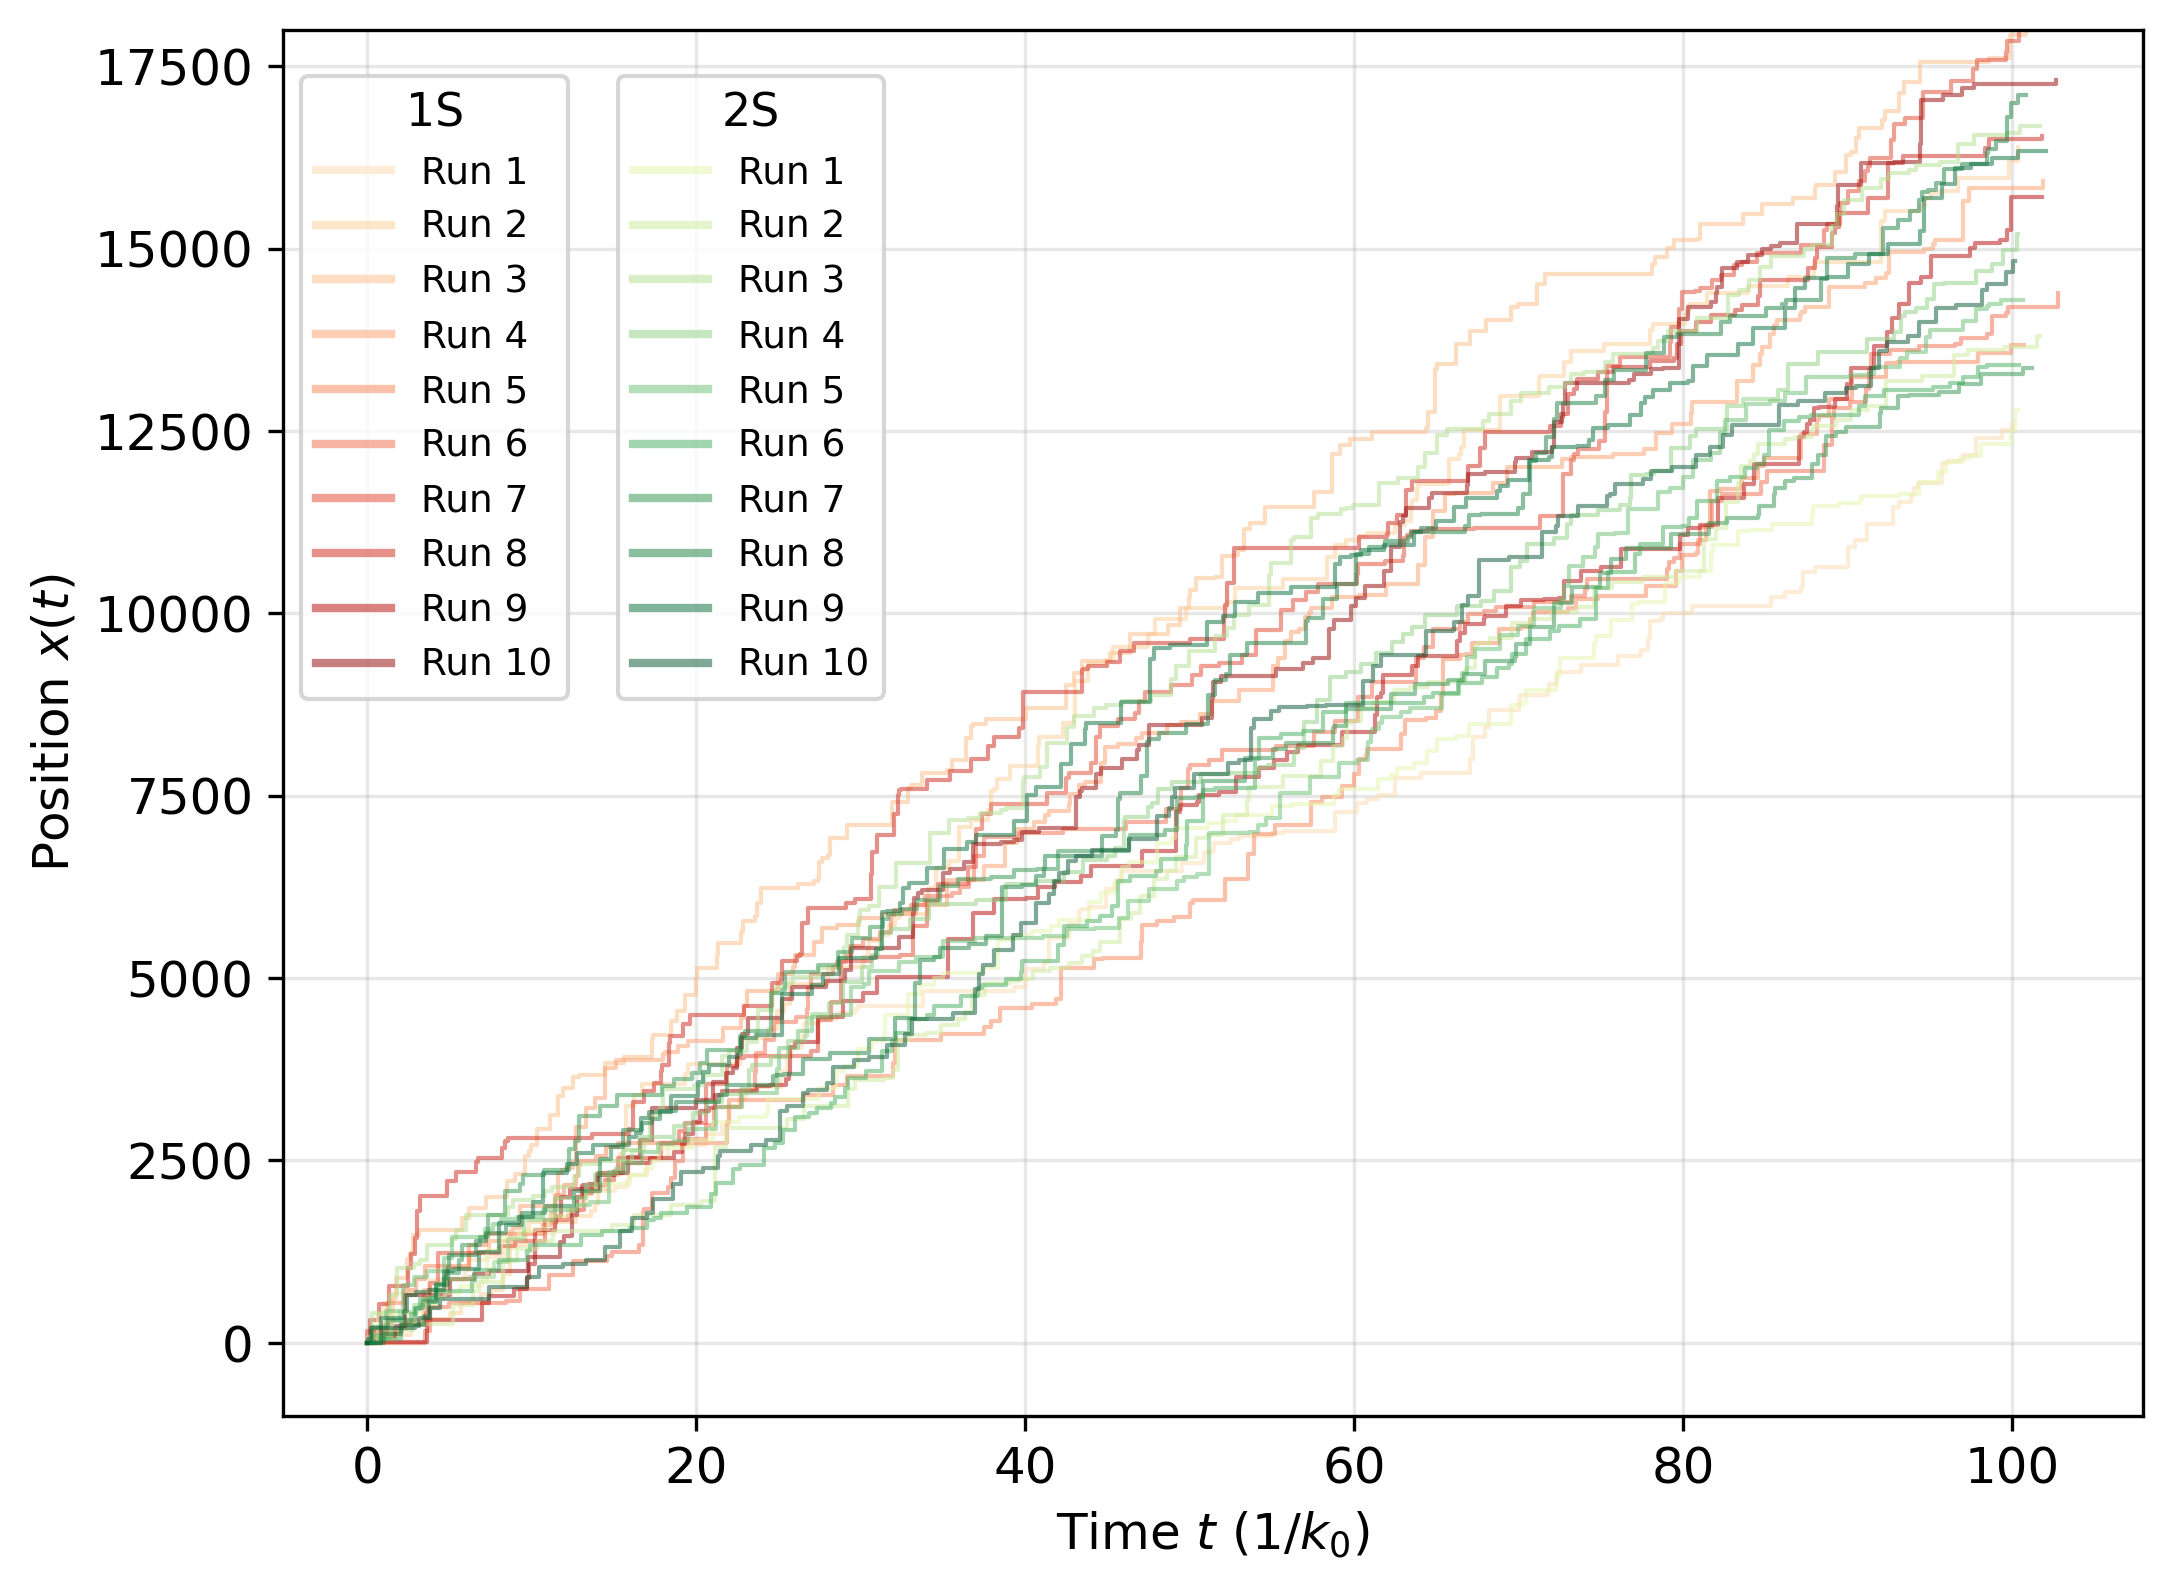

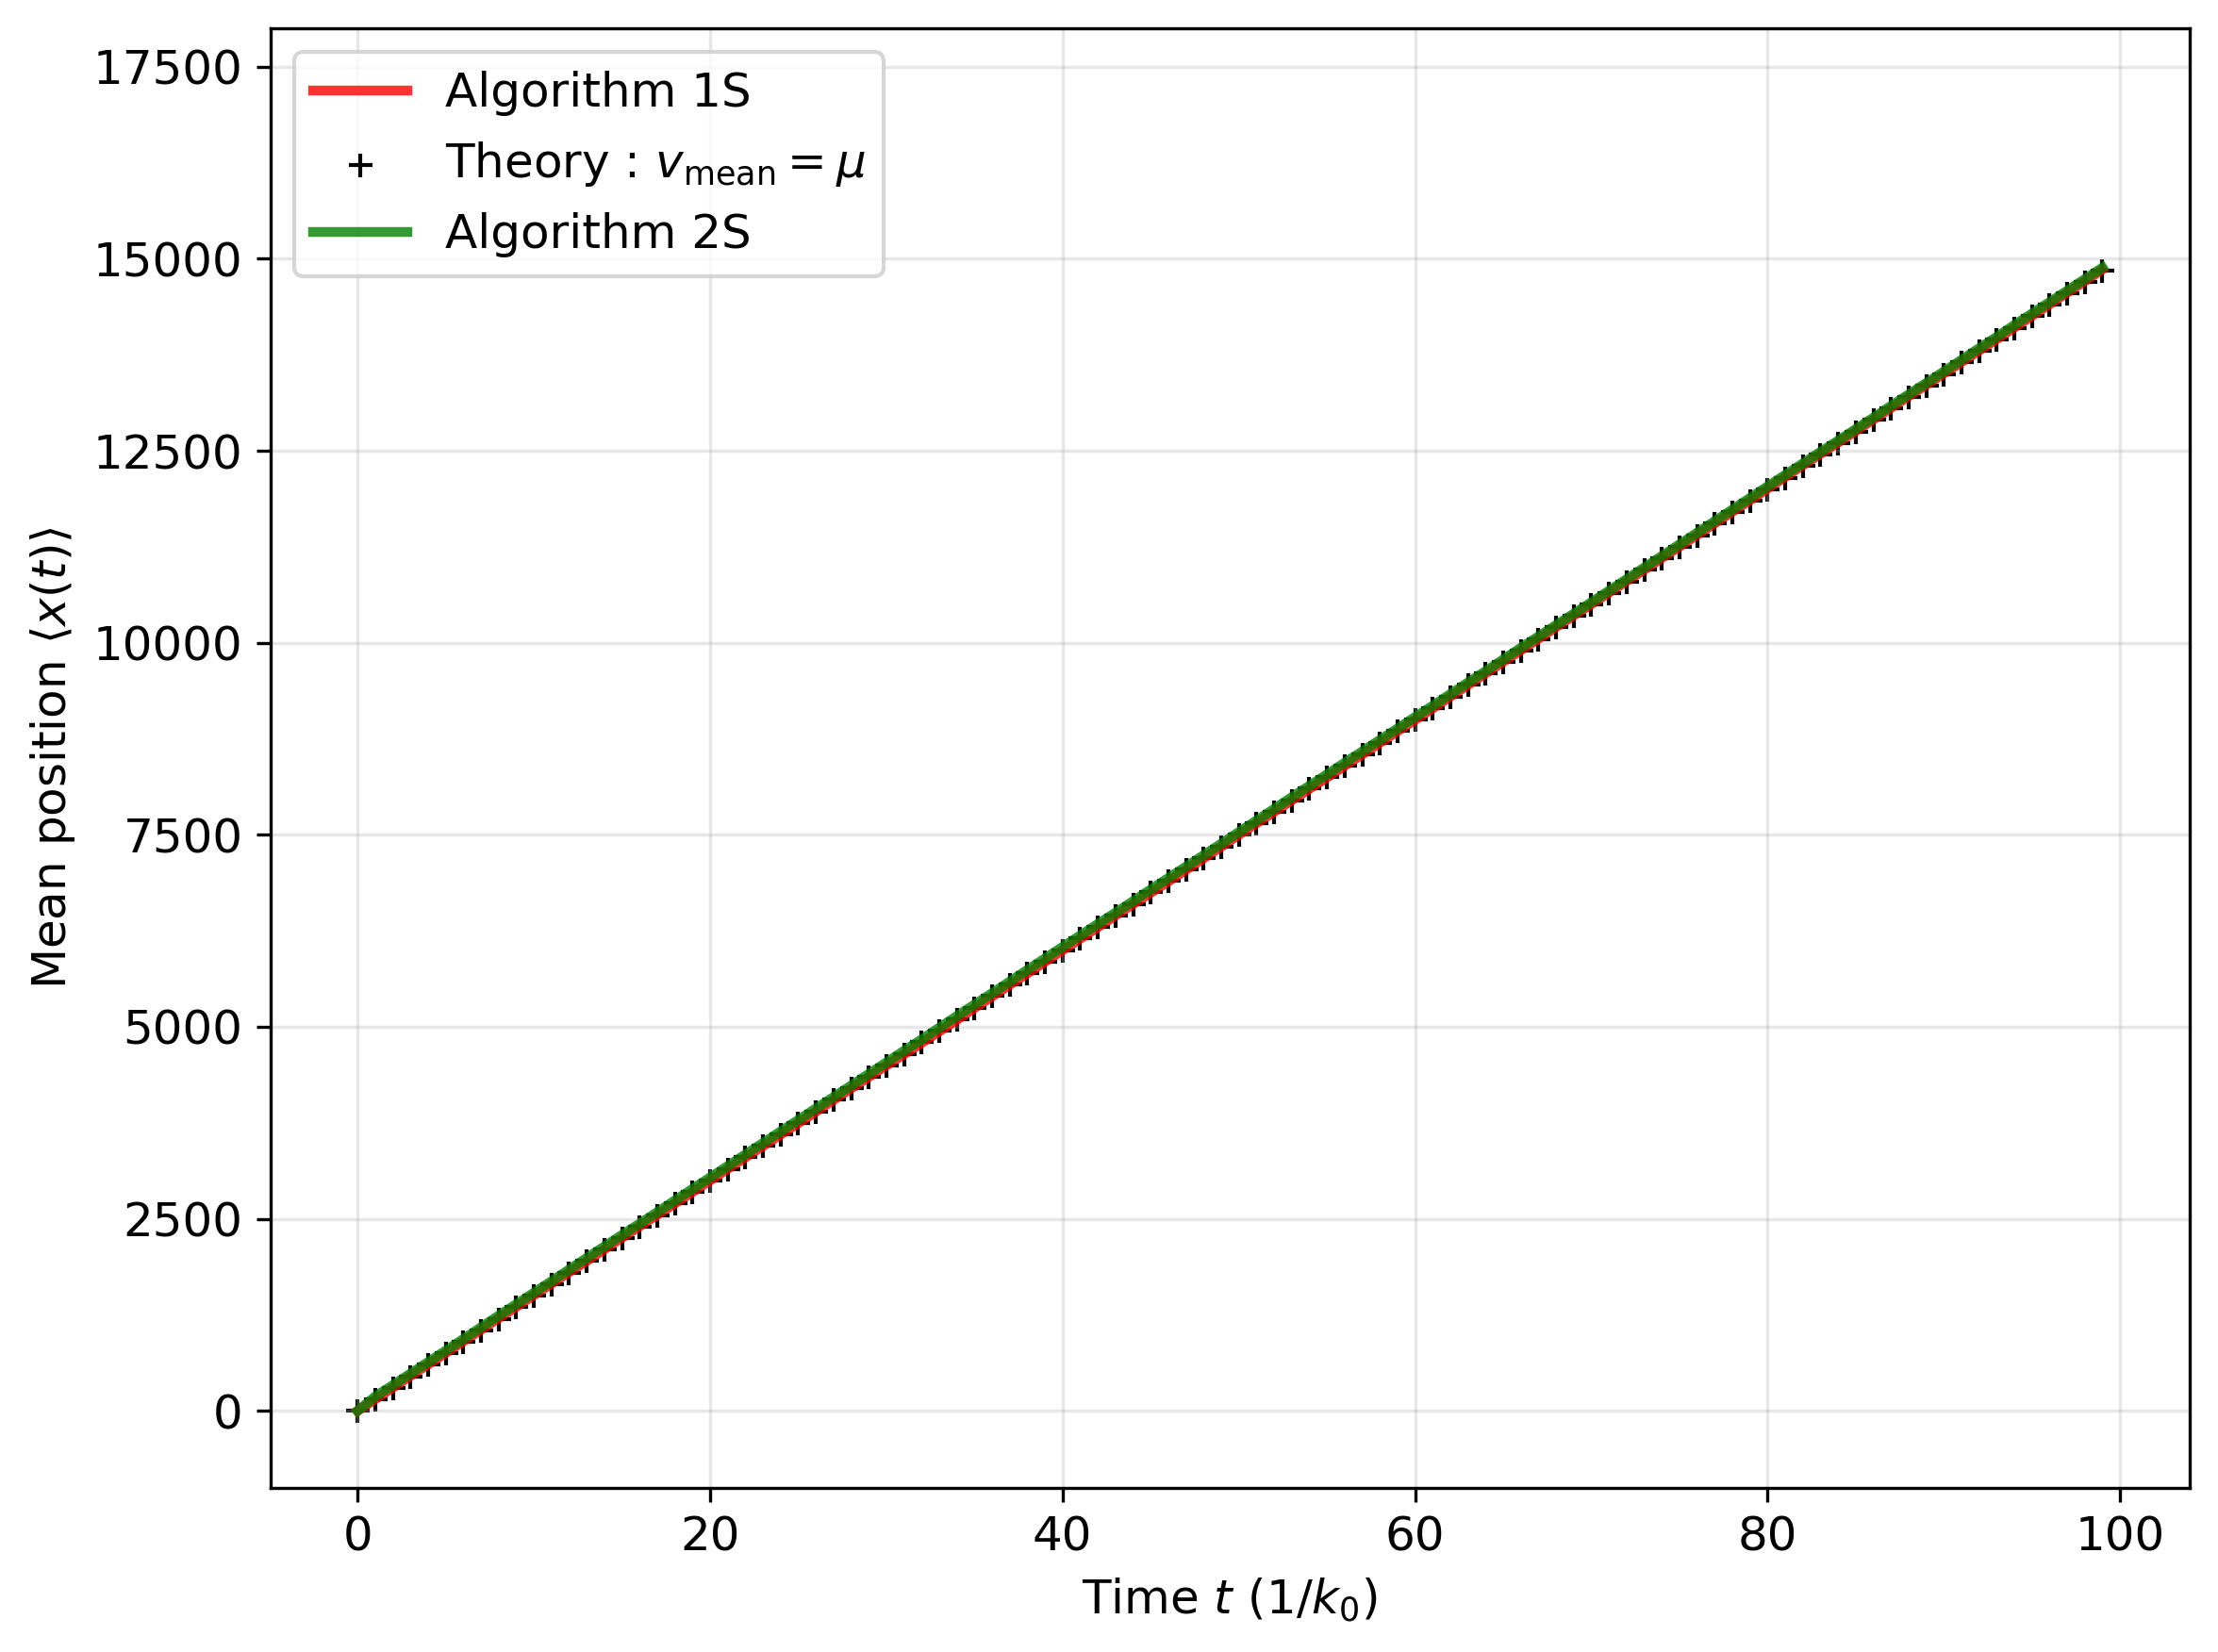

In [20]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = 12

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04"

params = {
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "homogen",
    "s": 0,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 100,
    "nt": 10_000,
}

algos = ["1S", "2S"]
colors_1S = plt.cm.OrRd(np.linspace(0.20, 0.95, 10))
colors_2S = plt.cm.YlGn(np.linspace(0.20, 0.95, 10))
ylims = [-1000, 18000]

# Stockage des trajectoires moyennes
mean_trajectories = {}
plt.figure(figsize=(8, 6), dpi=300)


for algo in algos:

    params_algo = params.copy()
    params_algo["algo"] = algo

    df = find_parquet_and_load(base_folder=root, **params_algo)

    times = df["times"][0].to_numpy()
    t_matrix = df["t_matrix"][0].to_numpy()
    x_matrix = df["x_matrix"][0].to_numpy()
    results_mean = df["results_mean"][0].to_numpy()

    mean_trajectories[algo] = (times, results_mean)

    # --------------------------------------------------
    # Trajectoires individuelles
    # --------------------------------------------------

    for i in range(10):

        plt.step(
            t_matrix[i],
            x_matrix[i],
            where="post",
            color=colors_1S[i] if algo == "1S" else colors_2S[i],
            alpha=0.5,
            linewidth=1,
            label=f"1S — Run {i+1}" if algo == "1S"
                  else f"2S — Run {i+1}"
        )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.ylim(ylims)
plt.grid(True, alpha=0.30)

# Handles pour les runs
handles_1S = [
    Line2D(
        [0], [0],
        color=colors_1S[i],
        lw=2,
        alpha=0.5,
        label=f"Run {i+1}"
    )
    for i in range(10)
]

handles_2S = [
    Line2D(
        [0], [0],
        color=colors_2S[i],
        lw=2,
        alpha=0.5,
        label=f"Run {i+1}"
    )
    for i in range(10)
]

ax = plt.gca()

# Légende 1S
legend_1S = ax.legend(
    handles=handles_1S,
    title="1S",
    loc="upper left",
    bbox_to_anchor=(0.00, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=11
)

# Légende 2S
legend_2S = ax.legend(
    handles=handles_2S,
    title="2S",
    loc="upper left",
    bbox_to_anchor=(0.17, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=11
)

ax.add_artist(legend_1S)

plt.show()


# ======================================================
# Troisième figure : comparaison des trajectoires moyennes
# ======================================================

plt.figure(figsize=(8, 6), dpi=300)

for algo in algos:

    times, results_mean = mean_trajectories[algo]

    if algo == "2S":
        plt.scatter(
            times,
            df["v_mean_th"].to_numpy() * times,
            linewidth=1,
            color="black",
            label=rf"Theory : $v_{{\text{{mean}}}} = \mu$",
            marker="+"
        )

    plt.plot(
        times,
        results_mean,
        lw=2.5,
        color="red" if algo == "1S" else "green",
        label=f"Algorithm {algo}",
        alpha=0.80,
    )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Mean position $\langle x(t) \rangle$")
plt.ylim(ylims)
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

Loading subfiles:  50%|█████     | 1/2 [00:00<00:00,  7.20subfiles/s]



Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04/nucleo__test1S__0/algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__
File loaded successfully: algo=1S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04/nucleo__test2S__0/algo=2S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__


Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]

File loaded successfully: algo=2S__fact=False__mode=none__dstr=False__land=periodic__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


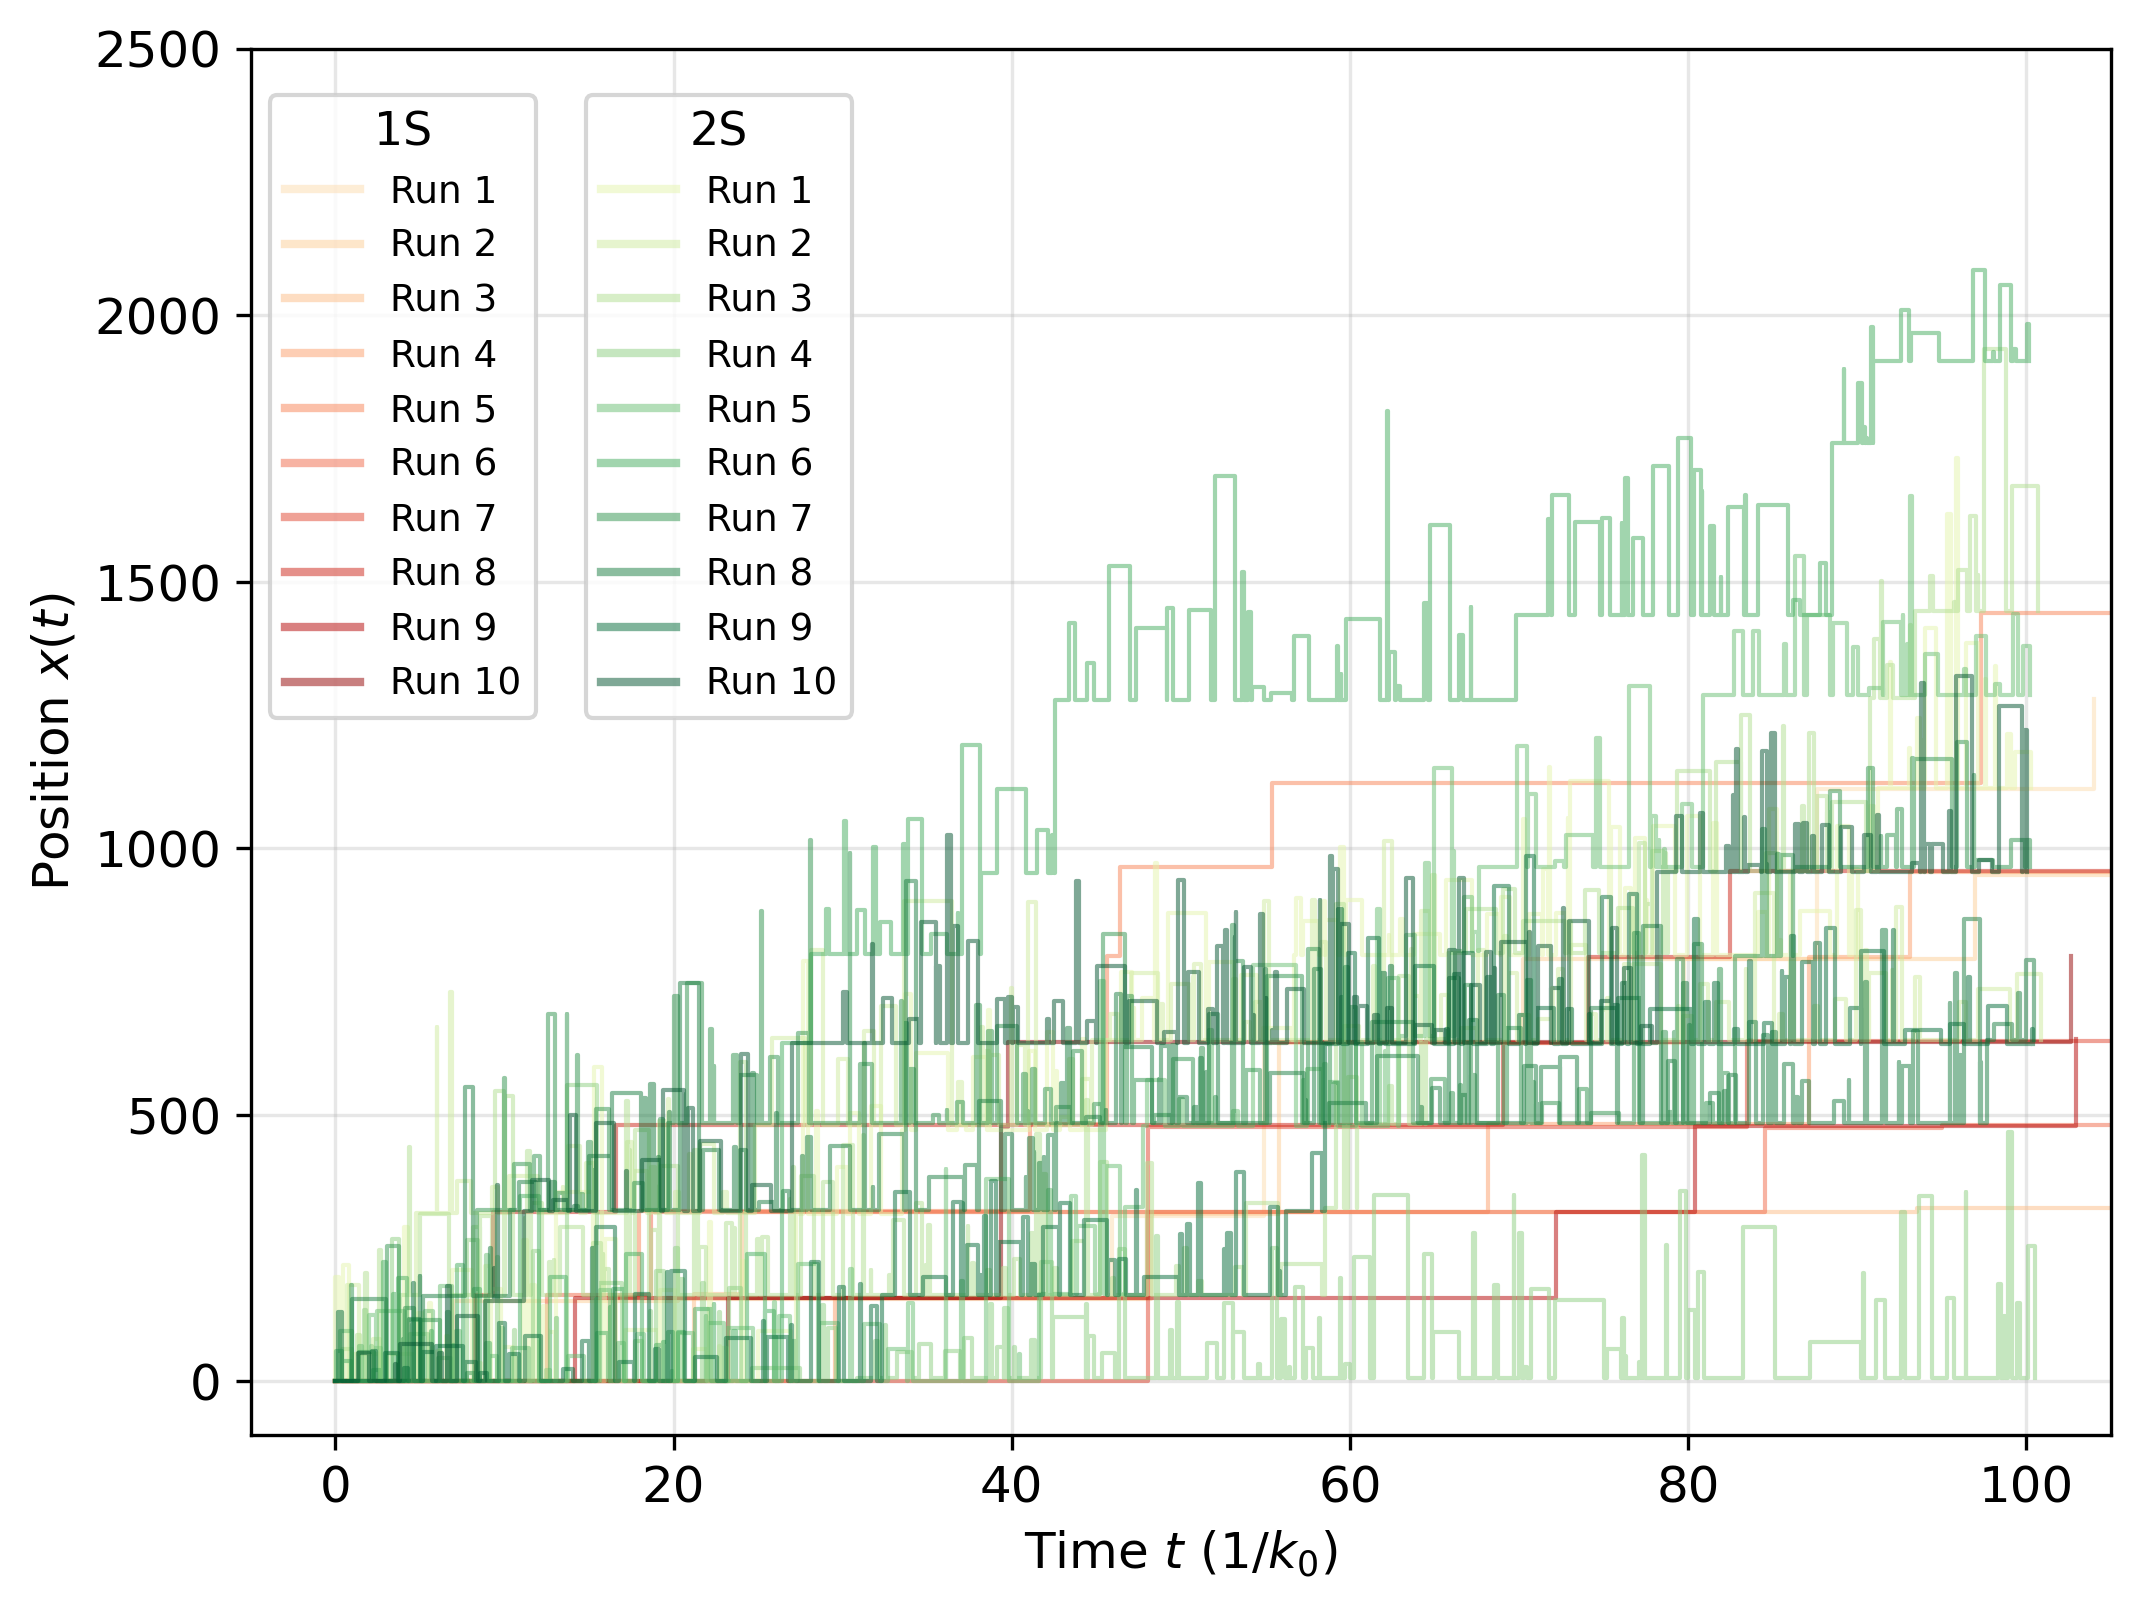

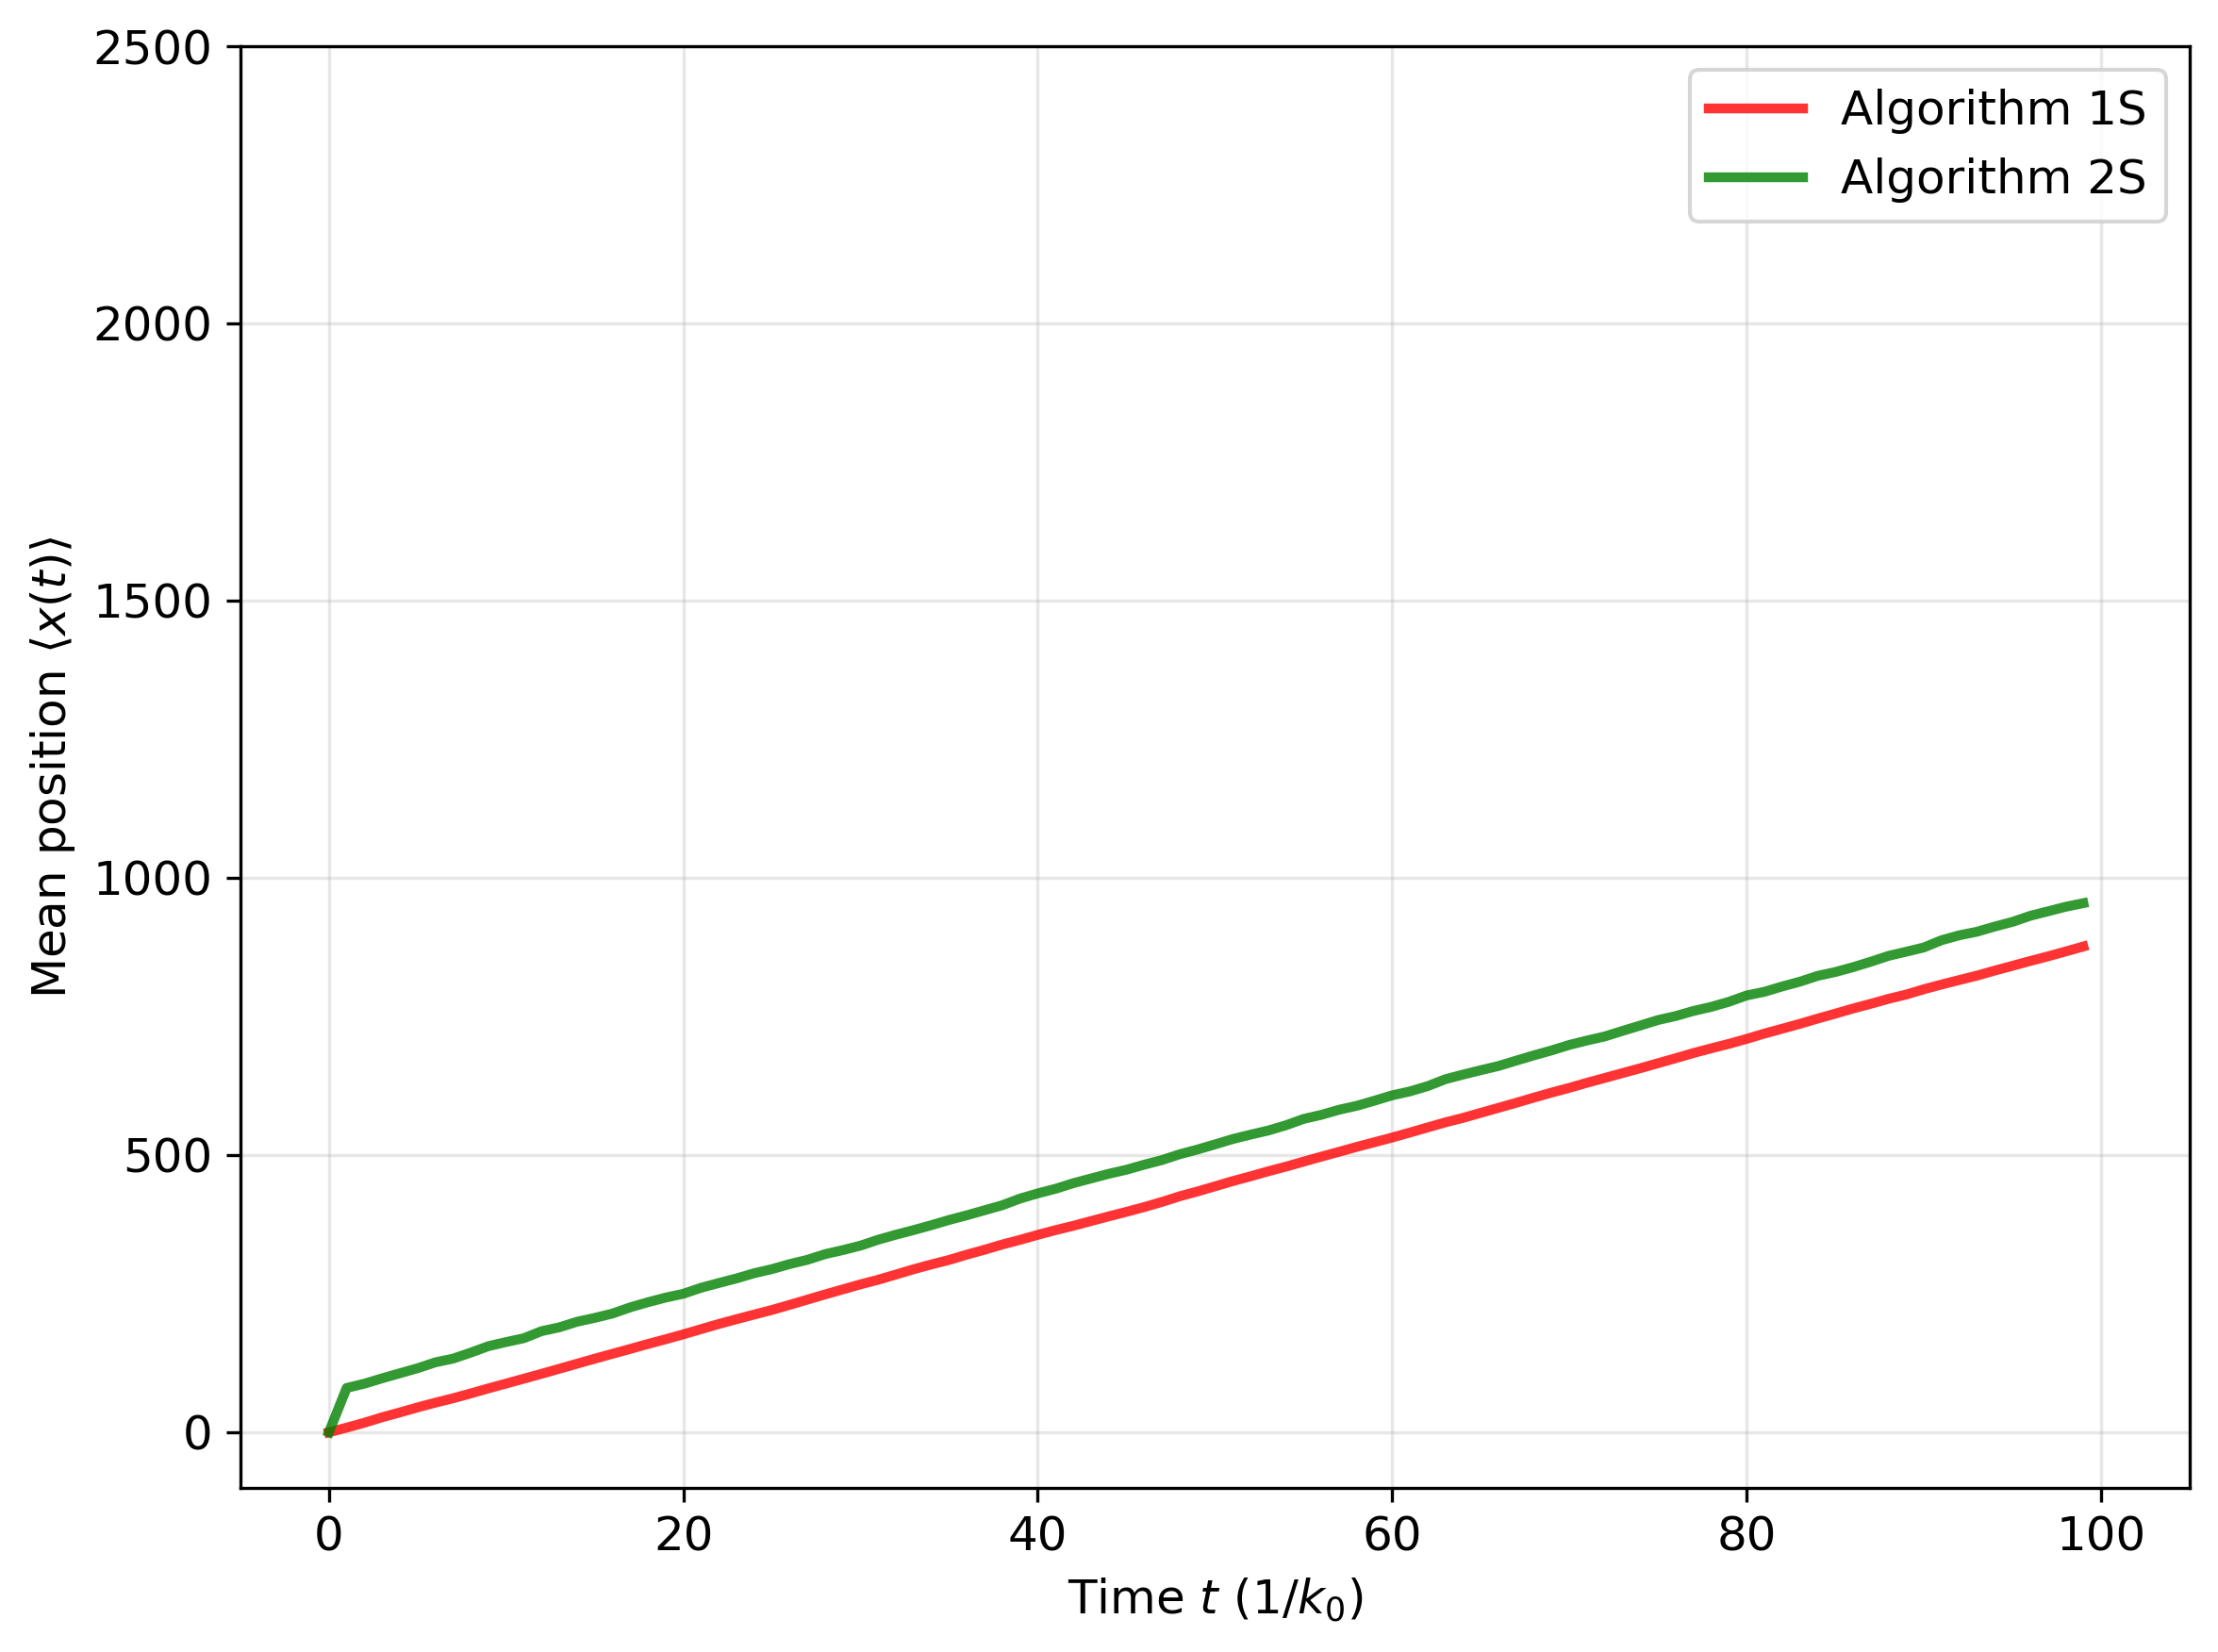

In [22]:
from nucleo.io.reading import find_parquet_and_load
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
plt.rcParams["font.size"] = 12

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04"

params = {
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "periodic",
    "s": 150,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 100,
    "nt": 10_000,
    "alphac": 1,
}

algos = ["1S", "2S"]
colors_1S = plt.cm.OrRd(np.linspace(0.20, 0.95, 10))
colors_2S = plt.cm.YlGn(np.linspace(0.20, 0.95, 10))
xlims = [-5, 105]
ylims = [-100, 2500]

# Stockage des trajectoires moyennes
mean_trajectories = {}
plt.figure(figsize=(8, 6), dpi=300)


for algo in algos:

    params_algo = params.copy()
    params_algo["algo"] = algo

    df = find_parquet_and_load(base_folder=root, **params_algo)

    times = df["times"][0].to_numpy()
    t_matrix = df["t_matrix"][0].to_numpy()
    x_matrix = df["x_matrix"][0].to_numpy()
    results_mean = df["results_mean"][0].to_numpy()

    mean_trajectories[algo] = (times, results_mean)

    # --------------------------------------------------
    # Trajectoires individuelles
    # --------------------------------------------------

    for i in range(10):

        plt.step(
            t_matrix[i],
            x_matrix[i],
            where="post",
            color=colors_1S[i] if algo == "1S" else colors_2S[i],
            alpha=0.5,
            linewidth=1,
            label=f"1S — Run {i+1}" if algo == "1S"
                  else f"2S — Run {i+1}"
        )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Position $x(t)$")
plt.xlim(xlims)
plt.ylim(ylims)
plt.grid(True, alpha=0.30)

# Handles pour les runs
handles_1S = [
    Line2D(
        [0], [0],
        color=colors_1S[i],
        lw=2,
        alpha=0.5,
        label=f"Run {i+1}"
    )
    for i in range(10)
]

handles_2S = [
    Line2D(
        [0], [0],
        color=colors_2S[i],
        lw=2,
        alpha=0.5,
        label=f"Run {i+1}"
    )
    for i in range(10)
]

ax = plt.gca()

# Légende 1S
legend_1S = ax.legend(
    handles=handles_1S,
    title="1S",
    loc="upper left",
    bbox_to_anchor=(0.00, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=11
)

# Légende 2S
legend_2S = ax.legend(
    handles=handles_2S,
    title="2S",
    loc="upper left",
    bbox_to_anchor=(0.17, 0.98),
    frameon=True,
    fontsize=9,
    title_fontsize=11
)

ax.add_artist(legend_1S)

plt.show()


# ======================================================
# Troisième figure : comparaison des trajectoires moyennes
# ======================================================

plt.figure(figsize=(8, 6), dpi=300)

for algo in algos:

    times, results_mean = mean_trajectories[algo]

    # if algo == "2S":
    #     plt.scatter(
    #         times,
    #         df["v_mean_th"].to_numpy() * times,
    #         linewidth=1,
    #         color="black",
    #         label=rf"Theory : $v_{{\text{{mean}}}} = \mu$",
    #         marker="+"
    #     )

    plt.plot(
        times,
        results_mean,
        lw=2.5,
        color="red" if algo == "1S" else "green",
        label=f"Algorithm {algo}",
        alpha=0.80,
    )

plt.xlabel(r"Time $t~(1/k_0)$")
plt.ylabel(r"Mean position $\langle x(t) \rangle$")
plt.xlim(xlims)
plt.ylim(ylims)
plt.grid(True, alpha=0.30)
plt.legend()
plt.tight_layout()
plt.show()

Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]


Corresponding subfile found:
/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04/nucleo__test2S__0/algo=2S__fact=False__mode=none__dstr=False__land=homogen__s=0__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=6.0e-01__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__


Loading subfiles:   0%|          | 0/2 [00:00<?, ?subfiles/s]

File loaded successfully: algo=2S__fact=False__mode=none__dstr=False__land=homogen__s=0__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=6.0e-01__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__.parquet
Shape: (1, 91)


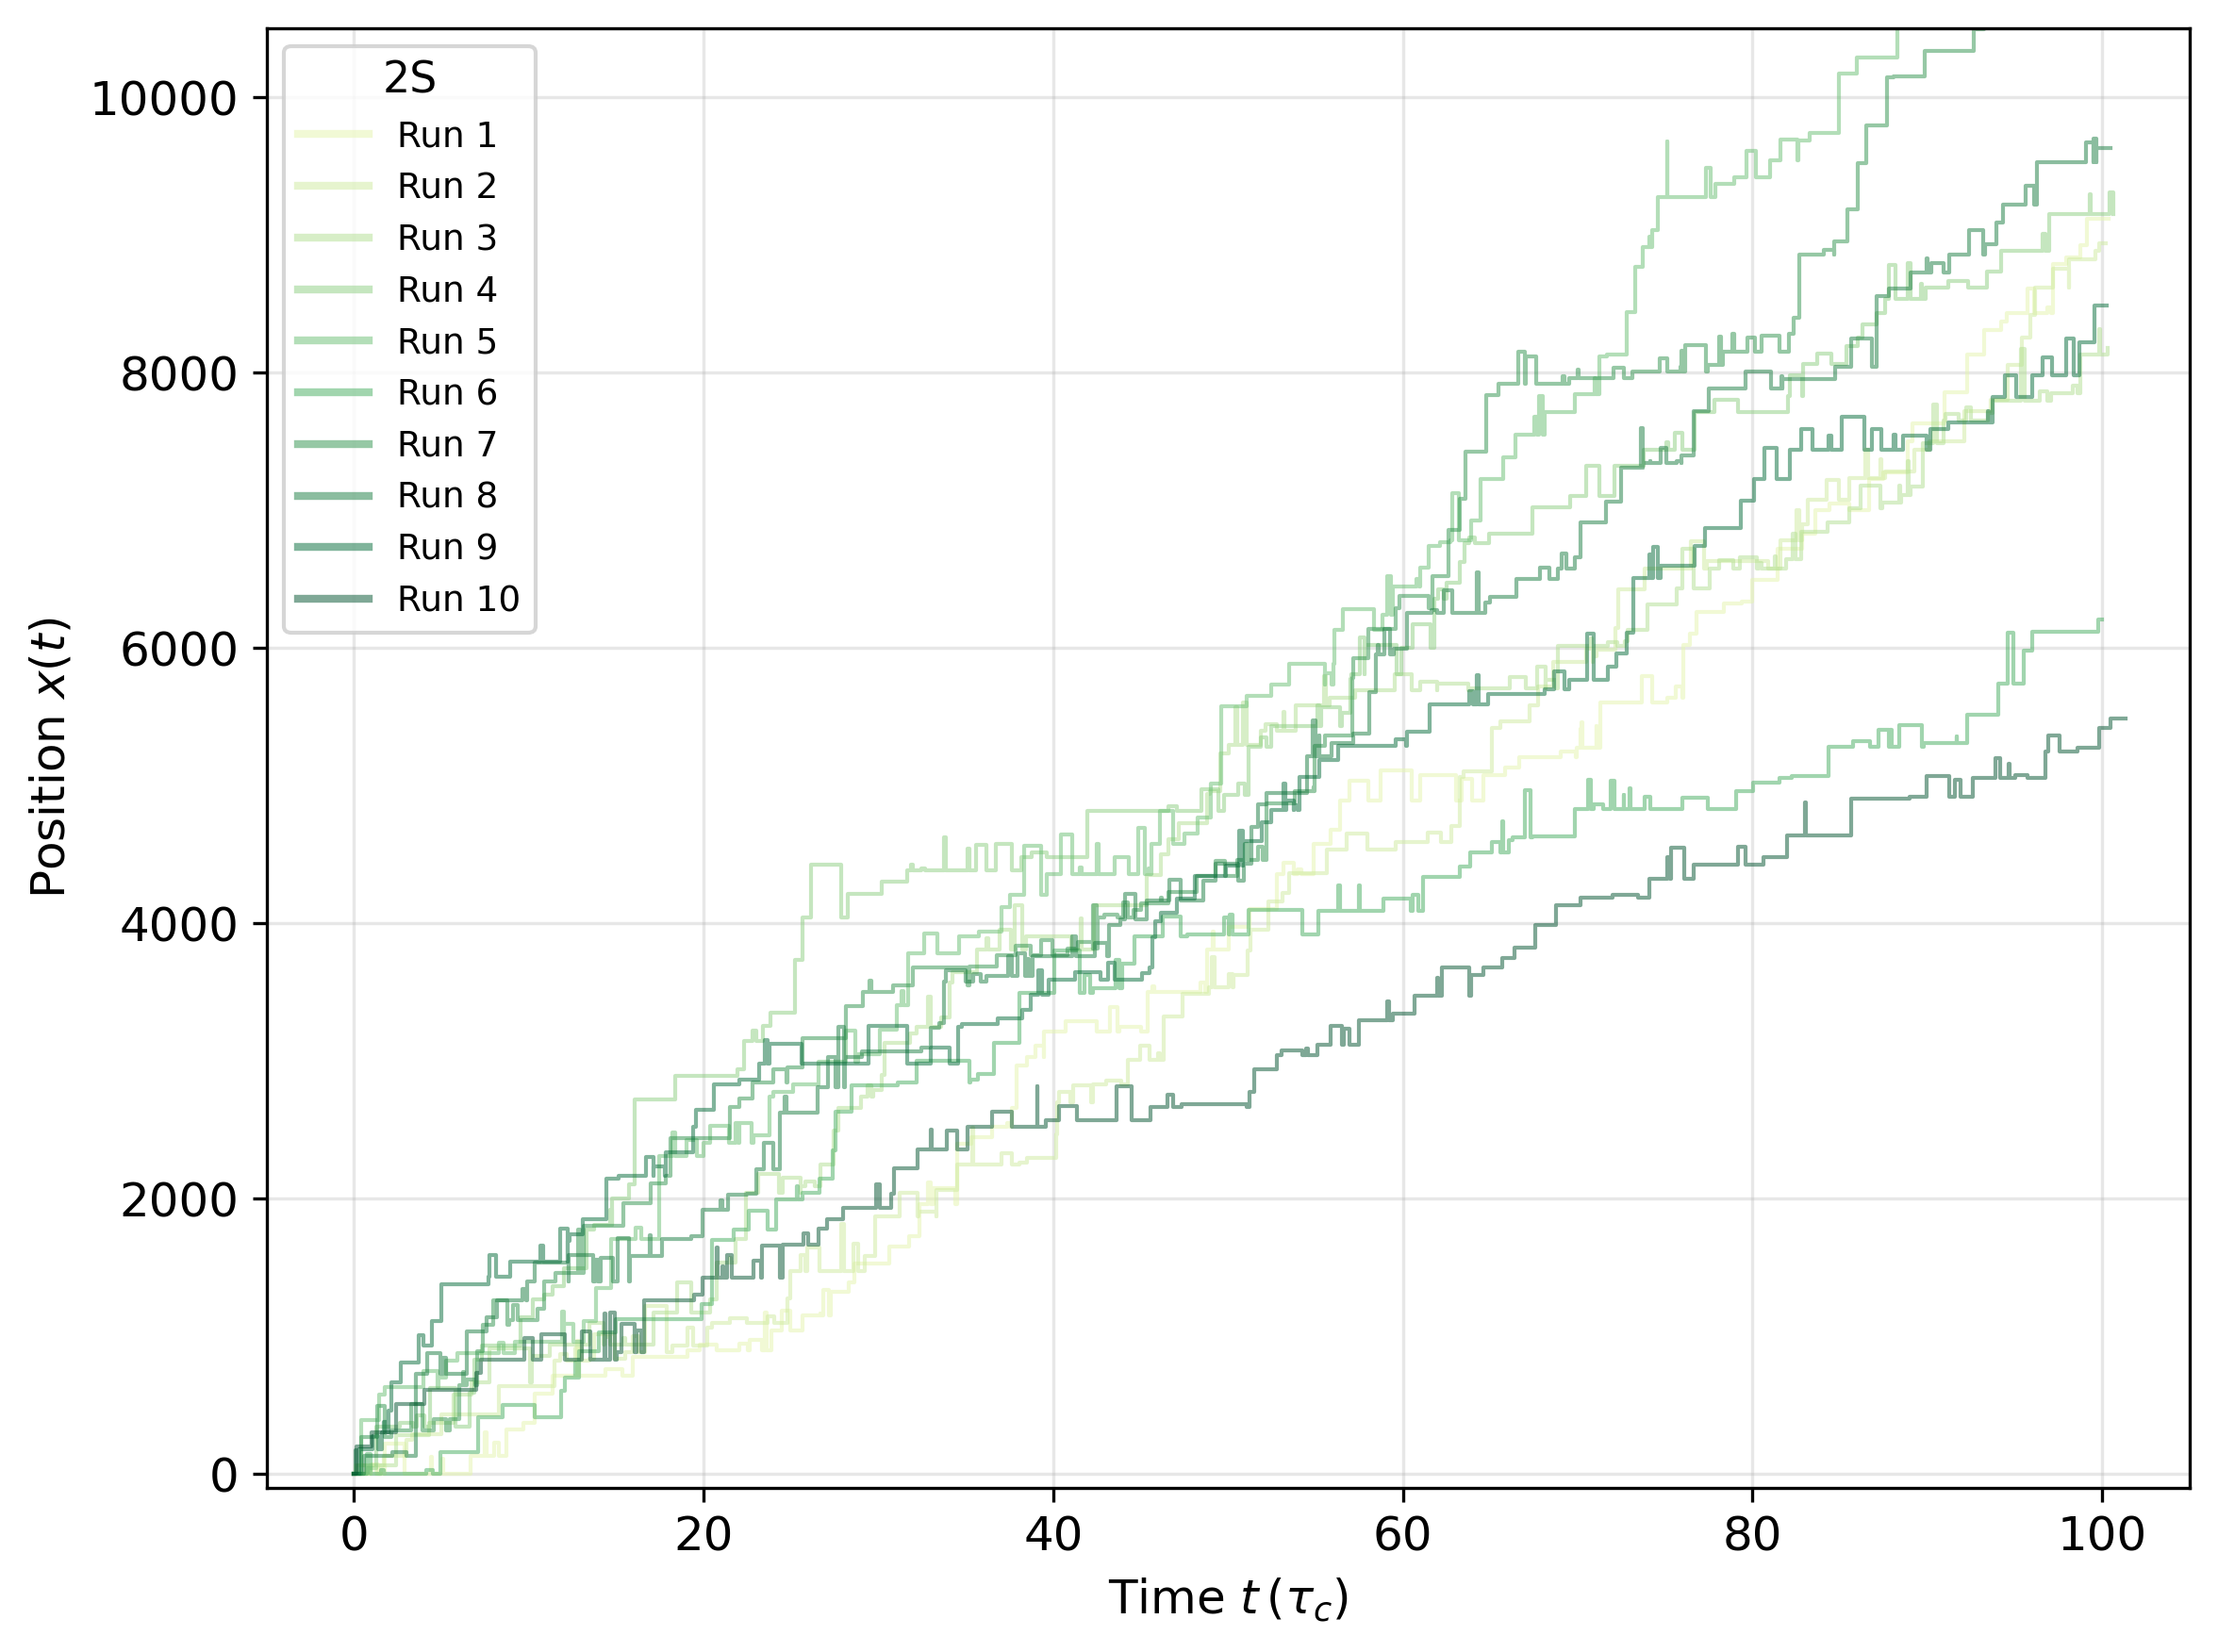

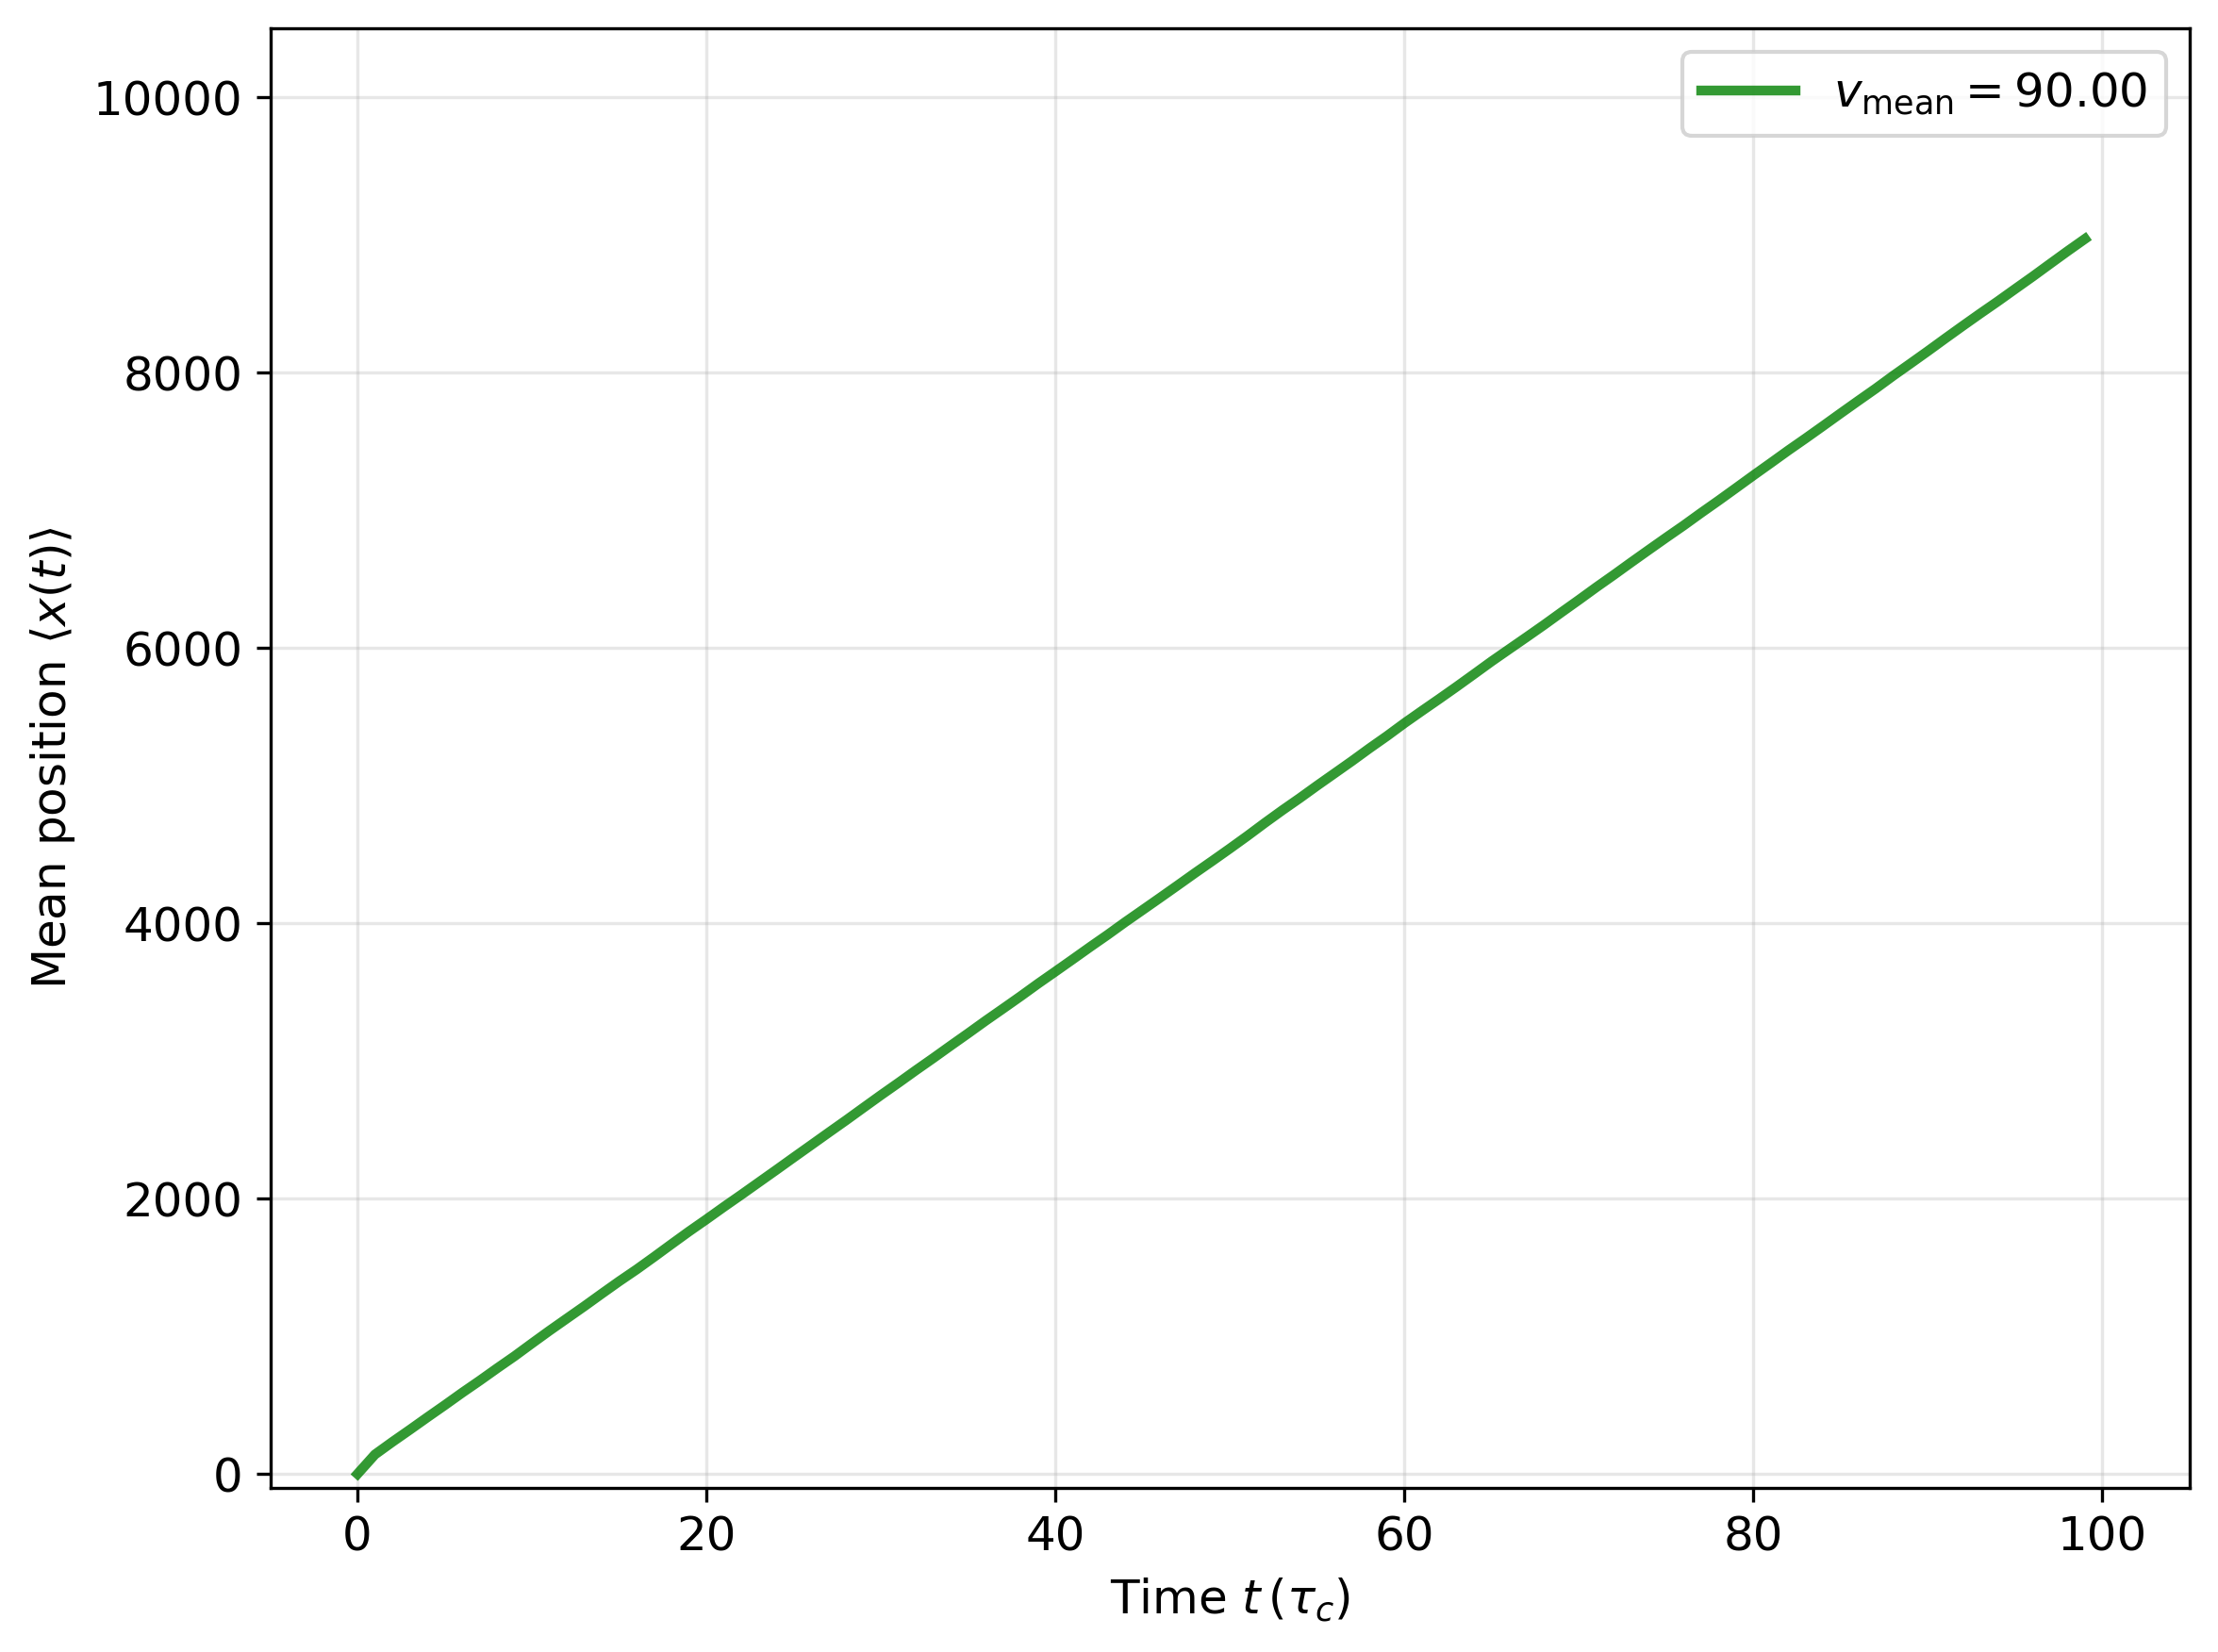

In [19]:
from nucleo.io.reading import find_parquet_and_load

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

plt.rcParams["font.size"] = 12

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/TESTS__PC__2026-09-04"

params = {
    "fact": "False",
    "mode": "none",
    "dstr": "False",
    "land": "homogen",
    "s": 0,
    "l": 10,
    "bpmin": 0,
    "mu": 150,
    "theta": 100,
    "nt": 10_000,
    "alphac": 0.60,
    "algo": "2S",
}

color = plt.cm.YlGn(np.linspace(0.20, 0.95, 10))

xlims = [-5, 105]
ylims = [-100, 10_500]

# ======================================================
# Chargement des données
# ======================================================

df = find_parquet_and_load(
    base_folder=root,
    **params
)

times = df["times"][0].to_numpy()
t_matrix = df["t_matrix"][0].to_numpy()
x_matrix = df["x_matrix"][0].to_numpy()
results_mean = df["results_mean"][0].to_numpy()
v_mean = df["v_mean_th"].to_numpy()[0]

# ======================================================
# Figure 1 : trajectoires individuelles
# ======================================================

plt.figure(figsize=(8, 6), dpi=300)

for i in range(10):
    plt.step(
        t_matrix[i],
        x_matrix[i],
        where="post",
        color=color[i],
        alpha=0.5,
        linewidth=1,
    )

plt.xlabel(r"Time $t\,(\tau_c)$")
plt.ylabel(r"Position $x(t)$")

plt.xlim(xlims)
plt.ylim(ylims)

plt.grid(True, alpha=0.30)

# Légende des runs
handles = [
    Line2D(
        [0], [0],
        color=color[i],
        lw=2,
        alpha=0.5,
        label=f"Run {i+1}"
    )
    for i in range(10)
]

plt.legend(
    handles=handles,
    title="2S",
    loc="upper left",
    frameon=True,
    fontsize=9,
    title_fontsize=11
)

plt.tight_layout()
plt.show()


# ======================================================
# Figure 2 : trajectoire moyenne
# ======================================================

plt.figure(figsize=(8, 6), dpi=300)

plt.plot(
    times,
    results_mean,
    lw=2.5,
    color="green",
    label=rf"$v_{{\text{{mean}}}} = {v_mean:.2f}$",
    alpha=0.80,
)

plt.xlabel(r"Time $t\,(\tau_c)$")
plt.ylabel(r"Mean position $\langle x(t) \rangle$")

plt.xlim(xlims)
plt.ylim(ylims)

plt.grid(True, alpha=0.30)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from nucleo.io.plots_1D import plot_fitting_summary

root = "/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURE_4__PC__2026-09-18/nucleo__fig4__0/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__"
df_single = pl.read_parquet(root)
print(df_single)






shape: (1, 92)
┌──────┬───────┬──────┬───────┬───┬──────────────┬───────────────────────┬───────────┬─────────────┐
│ algo ┆ fact  ┆ mode ┆ dstr  ┆ … ┆ vi_points    ┆ vi_distrib            ┆ xt_over_t ┆ G           │
│ ---  ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---          ┆ ---                   ┆ ---       ┆ ---         │
│ str  ┆ bool  ┆ str  ┆ bool  ┆   ┆ list[f64]    ┆ list[f64]             ┆ list[f64] ┆ list[f64]   │
╞══════╪═══════╪══════╪═══════╪═══╪══════════════╪═══════════════════════╪═══════════╪═════════════╡
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ [0.5, 1.5, … ┆ [0.08915, 0.070106, … ┆ [7.9154,  ┆ [0.981805,  │
│      ┆       ┆      ┆       ┆   ┆ 99999.5]     ┆ 0.0]                  ┆ 7.8162, … ┆ 1.140311, … │
│      ┆       ┆      ┆       ┆   ┆              ┆                       ┆ 6.18516]  ┆ 0.89383…    │
└──────┴───────┴──────┴───────┴───┴──────────────┴───────────────────────┴───────────┴─────────────┘


shape: (1, 92)
┌──────┬───────┬──────┬───────┬───┬──────────────┬───────────────────────┬───────────┬─────────────┐
│ algo ┆ fact  ┆ mode ┆ dstr  ┆ … ┆ vi_points    ┆ vi_distrib            ┆ xt_over_t ┆ G           │
│ ---  ┆ ---   ┆ ---  ┆ ---   ┆   ┆ ---          ┆ ---                   ┆ ---       ┆ ---         │
│ str  ┆ bool  ┆ str  ┆ bool  ┆   ┆ list[f64]    ┆ list[f64]             ┆ list[f64] ┆ list[f64]   │
╞══════╪═══════╪══════╪═══════╪═══╪══════════════╪═══════════════════════╪═══════════╪═════════════╡
│ 1S   ┆ false ┆ none ┆ false ┆ … ┆ [0.5, 1.5, … ┆ [0.08915, 0.070106, … ┆ [7.9154,  ┆ [0.981805,  │
│      ┆       ┆      ┆       ┆   ┆ 99999.5]     ┆ 0.0]                  ┆ 7.8162, … ┆ 1.140311, … │
│      ┆       ┆      ┆       ┆   ┆              ┆                       ┆ 6.18516]  ┆ 0.89383…    │
└──────┴───────┴──────┴───────┴───┴──────────────┴───────────────────────┴───────────┴─────────────┘
['algo', 'fact', 'mode', 'dstr', 'land', 's', 'l', 'bpmin', 'mu', 'theta', '

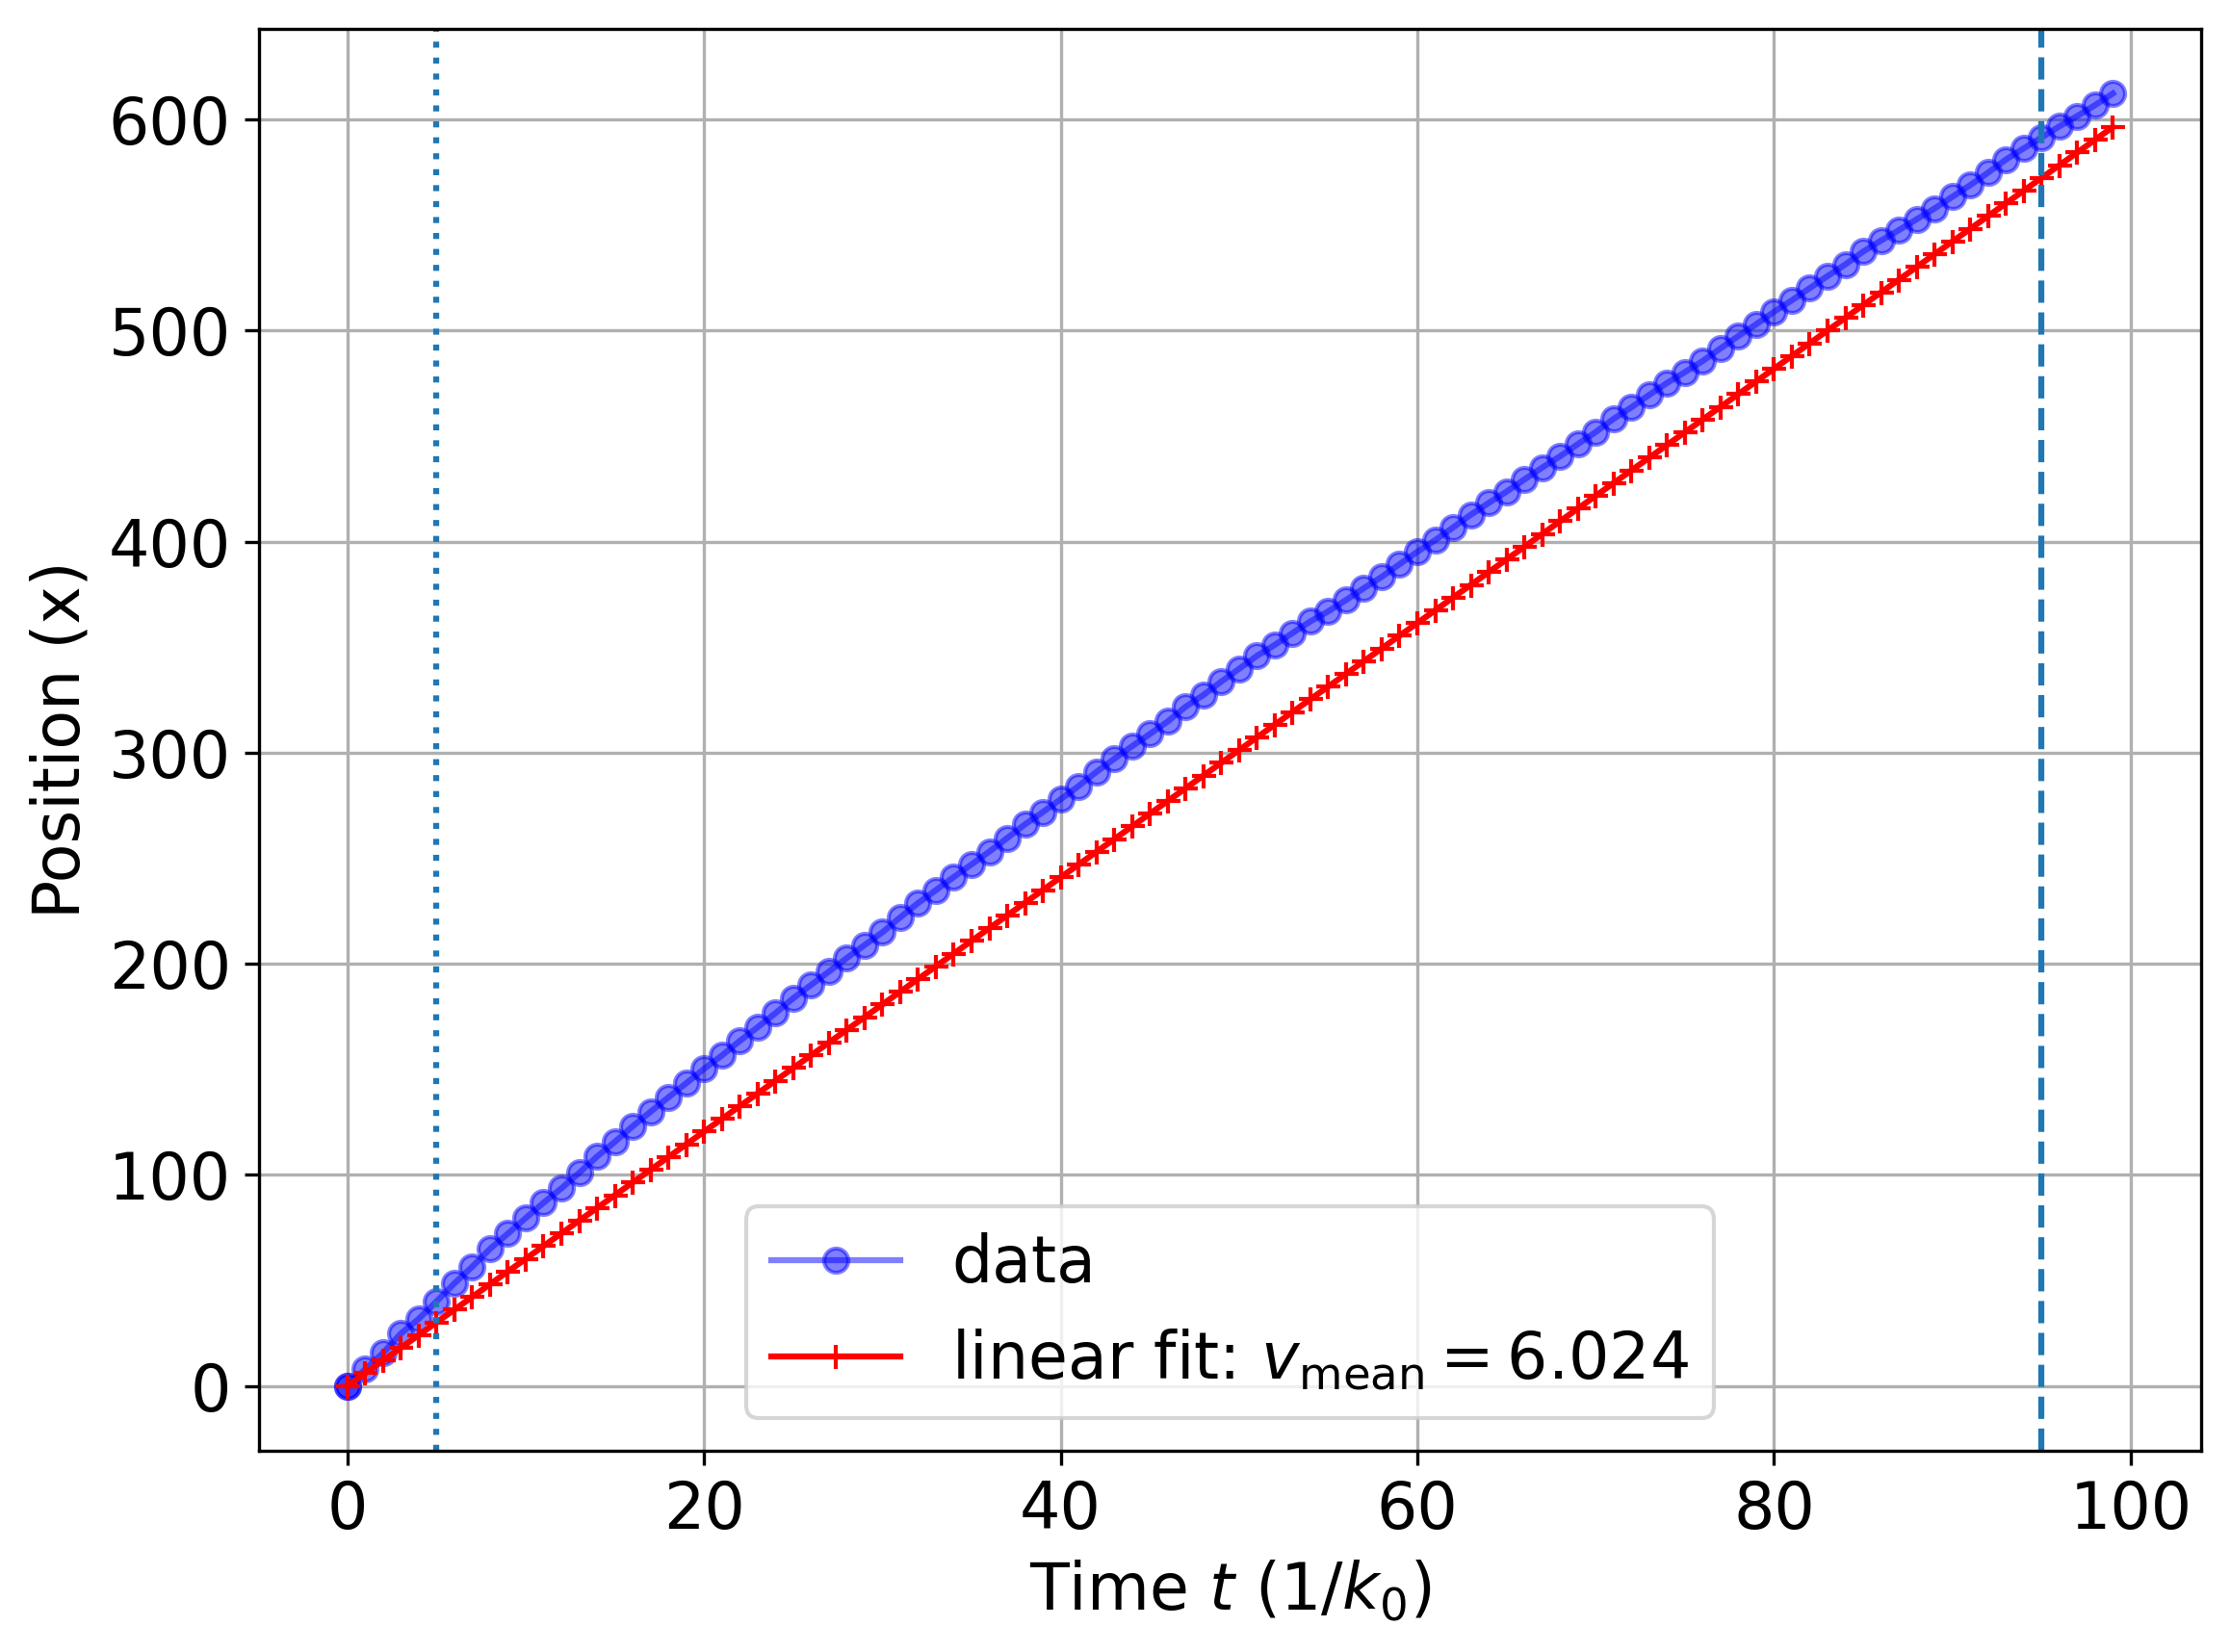

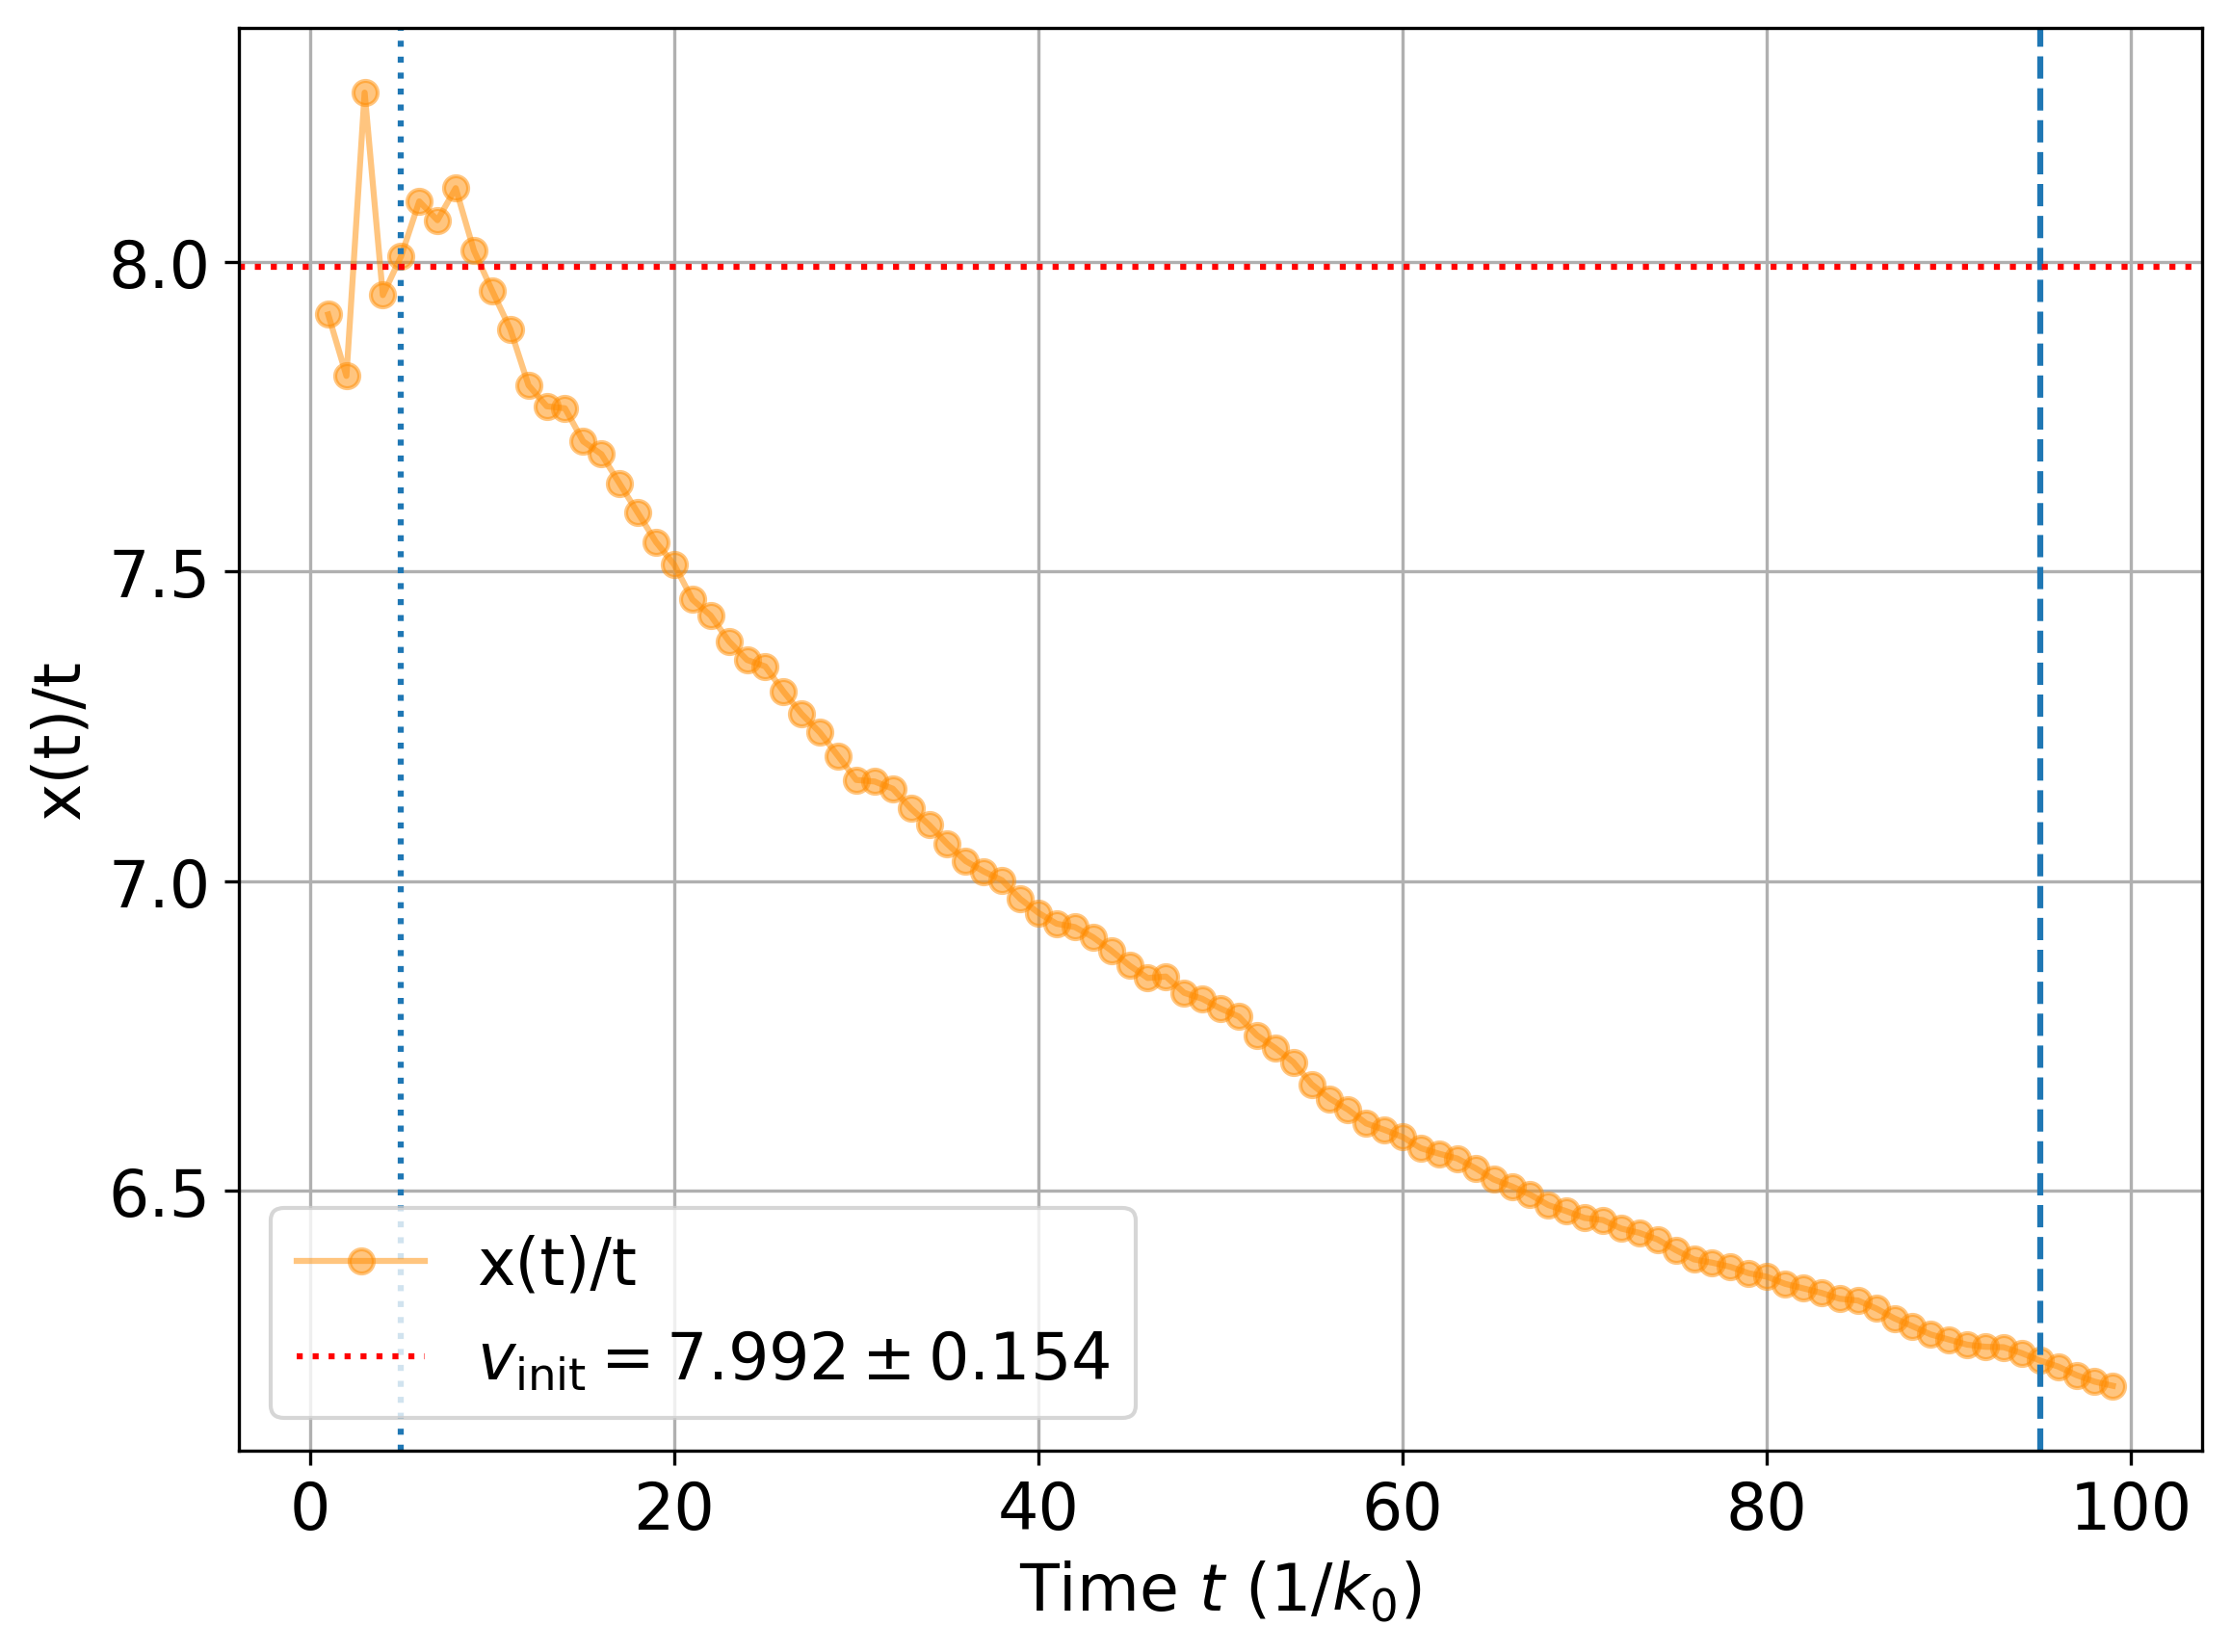

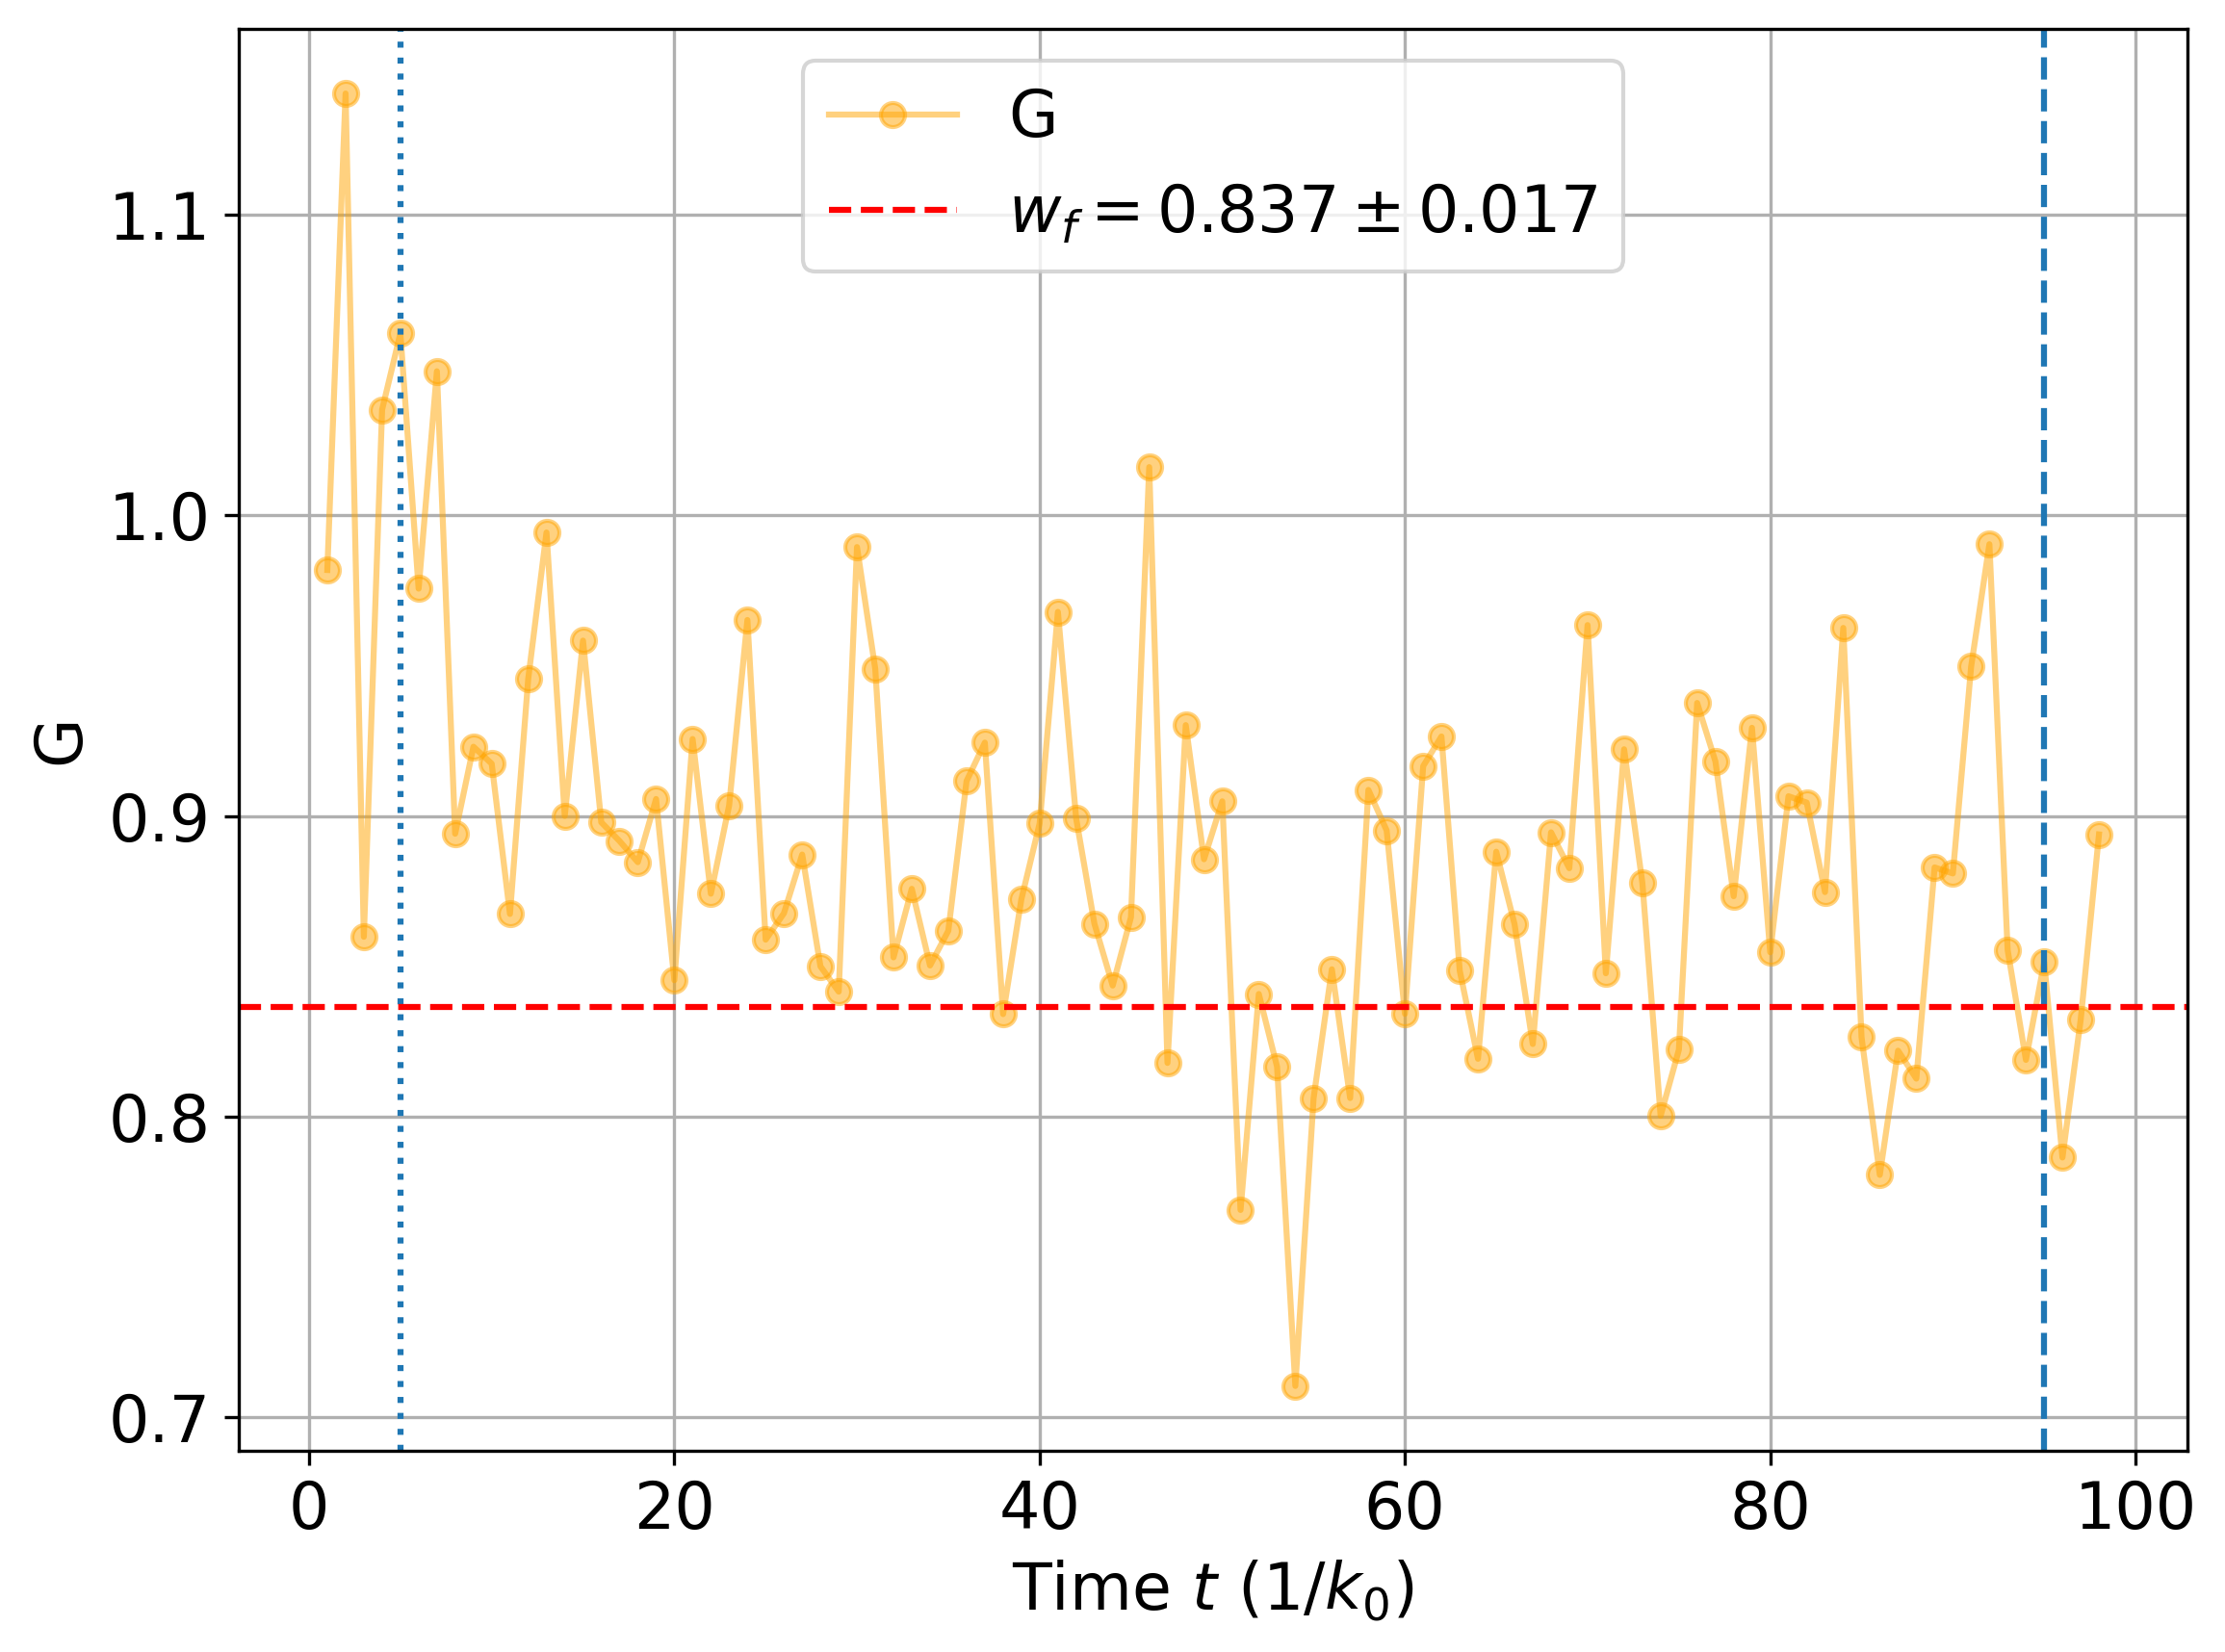

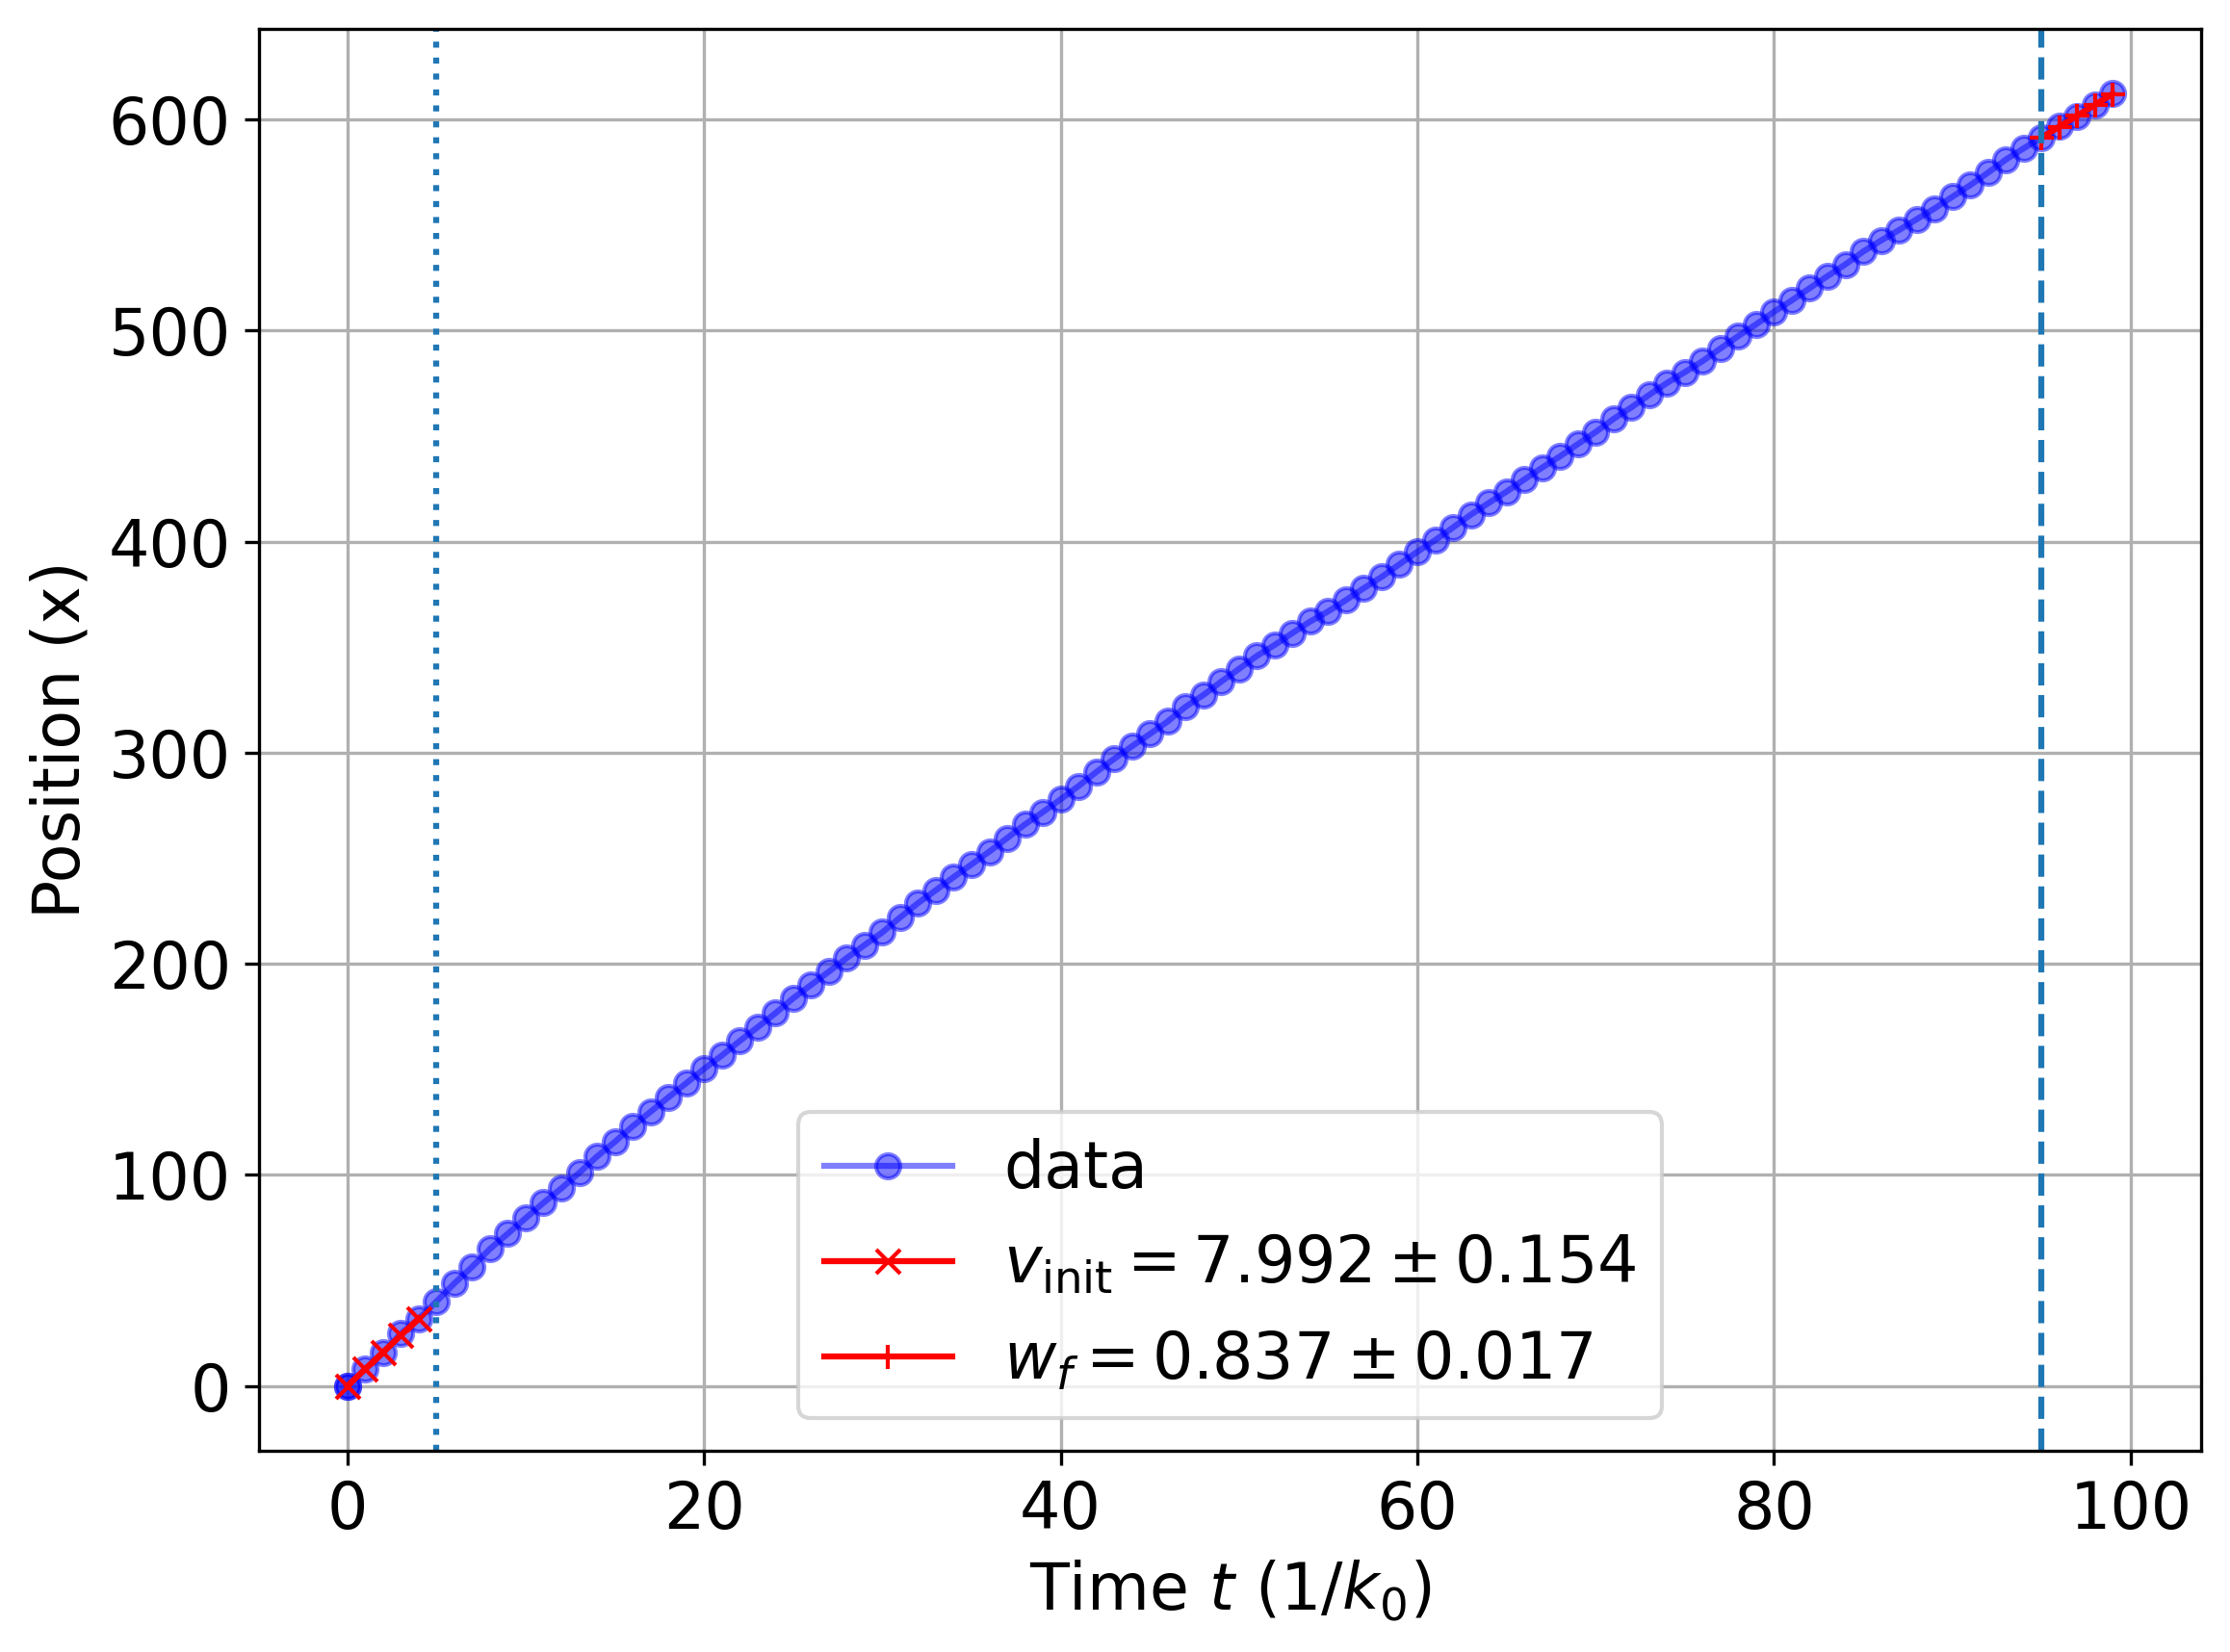

In [8]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
from nucleo.io.plots_1D import plot_fitting_summary


root = "/home/nicolas/Documents/Workspace/nucleo/outputs/FIGURE_4__PC__2026-09-18/nucleo__fig4__0/algo=1S__fact=False__mode=none__dstr=False__land=random__s=150__l=10__bpmin=0__mu=150__theta=100__rcapt=2.0e+00__rrest=2.0e+00__alphac=1.0e+00__alphad=0.0e+00__alphar=0.0e+00__krel=0.0e+00__Kp=0.0e+00__Kz=0.0e+00__nt=1.0e+04__"
df_single = pl.read_parquet(root)

print(df_single)
print(df_single.columns)


# Trajectories
# Trajectories / fitting data
times      = np.asarray(df_single["times"][0])
positions  = np.asarray(df_single["results_mean"][0])
v_mean     = df_single["v_mean"][0]
vf         = df_single["vf"][0]
Cf         = df_single["Cf"][0]
wf         = df_single["wf"][0]
vf_std     = df_single["vf_std"][0]
Cf_std     = df_single["Cf_std"][0]
wf_std     = df_single["wf_std"][0]
xt_over_t  = np.asarray(df_single["xt_over_t"][0])
G          = np.asarray(df_single["G"][0])


def plot_fitting_summary_first_row(
    times,
    positions,
    v_mean,
    xt_over_t,
    G,
    vf,
    vf_std,
    Cf,
    Cf_std,
    wf,
    wf_std,
    bound_low=5,
    bound_high=95,
    rf=3,
    text_size=16,
):
    """
    Plot uniquement la première ligne de plot_fitting_summary.
    Chaque plot est généré dans une figure indépendante à 300 dpi.
    """

    plt.rcParams["font.size"] = text_size

    times_to_plot = np.insert(times, 0, 0)
    pos_to_plot = np.insert(positions, 0, 0)

    # ─────────────────────────────────────────────
    # 1. x(t) - Cartesian
    # ─────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    ax.plot(
        times_to_plot,
        pos_to_plot,
        marker='o',
        alpha=0.5,
        label='data',
        c='b'
    )

    ax.plot(
        times_to_plot,
        v_mean * times_to_plot,
        marker='+',
        label=rf'linear fit: $v_{{\mathrm{{mean}}}} = {np.round(v_mean, rf)}$',
        c='r'
    )

    ax.axvline(x=bound_low, ls=':')
    ax.axvline(x=bound_high, ls='--')

    # ax.set_title("x(t) - Cartesian")
    ax.set_xlabel(r"Time $t~(1/k_0)$")
    ax.set_ylabel("Position (x)")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()


    # ─────────────────────────────────────────────
    # 2. x(t)/t - Cartesian
    # ─────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    ax.plot(
        times[1:],
        xt_over_t,
        marker='o',
        alpha=0.5,
        label='x(t)/t',
        c='darkorange'
    )

    ax.axvline(x=bound_low, ls=':')
    ax.axvline(x=bound_high, ls='--')

    ax.axhline(
        y=vf,
        c='r',
        ls=':',
        label=rf"$v_{{\mathrm{{init}}}} = {np.round(vf, rf)} \pm {np.round(vf_std, rf)}$"
    )

    # ax.set_title("x(t)/t - Cartesian")
    ax.set_xlabel(r"Time $t~(1/k_0)$")
    ax.set_ylabel("x(t)/t")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()


    # ─────────────────────────────────────────────
    # 3. G - Cartesian
    # ─────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    ax.plot(
        times[1:-1],
        G,
        marker='o',
        alpha=0.5,
        label='G',
        c='orange'
    )

    ax.axvline(x=bound_low, ls=':')
    ax.axvline(x=bound_high, ls='--')

    ax.axhline(
        y=wf,
        c='r',
        ls='--',
        label=rf"$w_f = {np.round(wf, rf)} \pm {np.round(wf_std, rf)}$"
    )

    # ax.set_title("Log Derivative (G) - Cartesian")
    ax.set_xlabel(r"Time $t~(1/k_0)$")
    ax.set_ylabel("G")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()


    # ─────────────────────────────────────────────
    # 4. Final result - Cartesian
    # ─────────────────────────────────────────────

    fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

    ax.plot(
        times_to_plot,
        pos_to_plot,
        marker='o',
        alpha=0.5,
        label='data',
        c='b'
    )

    ax.plot(
        times[:bound_low],
        times[:bound_low] * vf,
        label=rf"$v_{{\mathrm{{init}}}} = {np.round(vf, rf)} \pm {np.round(vf_std, rf)}$",
        c='r',
        marker='x'
    )

    ax.plot(
        times[bound_high:],
        Cf * np.power(times[bound_high:], wf),
        label=rf"$w_f = {np.round(wf, rf)} \pm {np.round(wf_std, rf)}$",
        c='r',
        marker='+'
    )

    ax.axvline(x=bound_low, ls=':')
    ax.axvline(x=bound_high, ls='--')

    # ax.set_title("Final Result - Cartesian")
    ax.set_xlabel(r"Time $t~(1/k_0)$")
    ax.set_ylabel("Position (x)")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()


plot_fitting_summary_first_row(
    times,
    positions,
    v_mean,
    xt_over_t,
    G,
    vf,
    vf_std,
    Cf,
    Cf_std,
    wf,
    wf_std
)

# .